# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Luna Marcelo - Cohorte 24 - 2do bimestre 2026


El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.


# CASO: Adult Census Income


El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.


### 1. Preparación del entorno

Importamos las librerías, definimos el estilo de los gráficos y fijamos constantes del trabajo: rutas a los CSV, nombre de la variable objetivo (*income*) y listado de columnas esperadas.



In [174]:
# 1. Preparación — imports y configuración
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Convención: variables propias en español; nombres en inglés solo para columnas/valores del dataset.
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

ARCHIVO_ENTRENAMIENTO = "adult_train.csv"
ARCHIVO_VALIDACION = "adult_val.csv"
COLUMNA_OBJETIVO = "income"

# Opcional: carpeta donde están los CSV (ej. tras montar Drive en Colab).
# Ejemplo: DIRECTORIO_DATOS = Path("/content/drive/MyDrive/.../DVxC---Aprendizaje-Profundo---TP2")
DIRECTORIO_DATOS = None

COLUMNAS_ESPERADAS = [
    "age",
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "skill-profile",
    "native-country",
    COLUMNA_OBJETIVO,
]

print("Setup listo.")


Setup listo.


### 2. Carga de los datos

Cargamos **adult_train.csv** y **adult_val.csv**. El código busca los archivos en el directorio del notebook, en Colab (`/content`) o en Drive. Si no los encuentra y estás en Colab, podés subirlos en orden: primero entrenamiento, luego validación. Opcionalmente podés indicar la carpeta con DIRECTORIO_DATOS en la celda anterior.



In [175]:
# 2. Carga de datos
import os


def _ejecutando_en_colab() -> bool:
    return os.environ.get("COLAB_RELEASE_TAG") is not None


def _directorio_notebook() -> Path | None:
    try:
        ip = get_ipython()
        if ip is None:
            return None
        for clave in ("__vsc_ipynb_file__", "__file__"):
            ruta_notebook = ip.user_ns.get(clave)
            if ruta_notebook:
                return Path(ruta_notebook).resolve().parent
    except Exception:
        pass
    return None


def _raices_busqueda() -> list[Path]:
    raices: list[Path] = []
    vistos: set[Path] = set()

    def agregar(path: Path) -> None:
        try:
            ruta_resuelta = path.resolve()
        except OSError:
            return
        if ruta_resuelta not in vistos:
            vistos.add(ruta_resuelta)
            raices.append(ruta_resuelta)

    if DIRECTORIO_DATOS is not None:
        agregar(Path(DIRECTORIO_DATOS))
    agregar(Path.cwd())
    directorio_nb = _directorio_notebook()
    if directorio_nb is not None:
        agregar(directorio_nb)
    for directorio_extra in (Path("/content"), Path("/content/drive/MyDrive")):
        agregar(directorio_extra)
    directorio_actual = Path.cwd()
    for _ in range(5):
        agregar(directorio_actual)
        if directorio_actual.parent == directorio_actual:
            break
        directorio_actual = directorio_actual.parent
    return raices


def resolver_ruta_csv(nombre_archivo: str) -> Path | None:
    for raiz in _raices_busqueda():
        candidato = raiz / nombre_archivo
        if candidato.is_file():
            return candidato

    for carpeta_base in (Path("/content"), Path.cwd(), _directorio_notebook() or Path.cwd()):
        if not carpeta_base.exists():
            continue
        for coincidencia in carpeta_base.rglob(nombre_archivo):
            if coincidencia.is_file():
                return coincidencia
    return None


def _subir_csv(nombre_esperado: str, paso: int, etiqueta: str) -> Path:
    from google.colab import files

    print(f"Paso {paso}/2 — Suba: {nombre_esperado} ({etiqueta})")
    archivos_subidos = files.upload()
    if not archivos_subidos:
        raise RuntimeError("No se subió ningún archivo. Vuelva a ejecutar la celda.")

    nombre_recibido, contenido = next(iter(archivos_subidos.items()))
    destino = Path.cwd() / nombre_esperado
    if nombre_recibido != nombre_esperado:
        print(f"  Recibido: '{nombre_recibido}' → guardado como '{destino.name}'")
    destino.write_bytes(contenido)
    return destino


def cargar_o_subir(nombre_archivo: str, *, paso: int, etiqueta: str) -> pd.DataFrame:
    ruta_resuelta = resolver_ruta_csv(nombre_archivo)
    if ruta_resuelta is not None:
        print(f"✓ {nombre_archivo} encontrado en: {ruta_resuelta.parent}")
        return pd.read_csv(ruta_resuelta)

    print(f"✗ No se encontró '{nombre_archivo}'. Directorio de trabajo: {Path.cwd().resolve()}")
    print("  Carpetas revisadas:", ", ".join(str(p) for p in _raices_busqueda()[:6]), "...")

    if not _ejecutando_en_colab():
        raise FileNotFoundError(
            f"No se encontró '{nombre_archivo}'.\n"
            "Coloque los CSV junto al notebook, defina DIRECTORIO_DATOS en la celda de setup "
            "o ejecute en Google Colab para subirlos."
        )

    _subir_csv(nombre_archivo, paso=paso, etiqueta=etiqueta)
    ruta_subida = resolver_ruta_csv(nombre_archivo) or (Path.cwd() / nombre_archivo)
    return pd.read_csv(ruta_subida)


df_entrenamiento = cargar_o_subir(ARCHIVO_ENTRENAMIENTO, paso=1, etiqueta="entrenamiento")
df_validacion = cargar_o_subir(ARCHIVO_VALIDACION, paso=2, etiqueta="validación")

print(f"\nFilas — train: {len(df_entrenamiento):,} | val: {len(df_validacion):,}")


✓ adult_train.csv encontrado en: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/TP2/DVxC---Aprendizaje-Profundo---TP2
✓ adult_val.csv encontrado en: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/02. Aprendizaje Profundo/99. Repo/TP2/DVxC---Aprendizaje-Profundo---TP2

Filas — train: 30,162 | val: 15,060


### 3. Verificación inicial del dataset

Revisamos dimensiones, tipos de datos, valores faltantes, filas duplicadas y que train y val tengan las mismas columnas. También se define **columnas_predictoras** (predictores), separados del target.


In [176]:
# 3. Verificación inicial del dataset

MARCADORES_FALTANTES = {"", "?", " ?", "NaN", "nan", "None", "none"}


def reportar_faltantes(df: pd.DataFrame, nombre: str) -> None:
    print(f"\n--- {nombre} ---")
    print(f"Shape: {df.shape}")
    print("\nTipos:")
    print(df.dtypes)

    df_texto = df.astype(str).replace(MARCADORES_FALTANTES, np.nan)
    conteos_na = df_texto.isna().sum()
    conteos_na = conteos_na[conteos_na > 0]
    if conteos_na.empty:
        print("\nValores faltantes (NA o marcadores '?', etc.): ninguno detectado.")
    else:
        print("\nValores faltantes por columna:")
        print(conteos_na)

    duplicados = df.duplicated().sum()
    print(f"\nFilas duplicadas: {duplicados:,}")


def validar_esquema(df: pd.DataFrame, nombre: str) -> None:
    columnas_faltantes = [c for c in COLUMNAS_ESPERADAS if c not in df.columns]
    columnas_sobrantes = [c for c in df.columns if c not in COLUMNAS_ESPERADAS]
    if columnas_faltantes or columnas_sobrantes:
        raise ValueError(
            f"{nombre}: columnas inesperadas.\n"
            f"  Faltan: {columnas_faltantes}\n"
            f"  Sobran: {columnas_sobrantes}"
        )


for marco, etiqueta in ((df_entrenamiento, "train"), (df_validacion, "val")):
    validar_esquema(marco, etiqueta)

if list(df_entrenamiento.columns) != list(df_validacion.columns):
    raise ValueError("train y val no comparten las mismas columnas en el mismo orden.")

reportar_faltantes(df_entrenamiento, "entrenamiento")
reportar_faltantes(df_validacion, "validación")

columnas_predictoras = [c for c in df_entrenamiento.columns if c != COLUMNA_OBJETIVO]

print("\n=== Columnas compartidas (train / val) ===")
print(list(df_entrenamiento.columns))

print(f"\nFeatures ({len(columnas_predictoras)}): {columnas_predictoras}")
print(f"Target: {COLUMNA_OBJETIVO}")
print(f"Clases en target (train): {sorted(df_entrenamiento[COLUMNA_OBJETIVO].unique())}")



--- entrenamiento ---
Shape: (30162, 14)

Tipos:
age               int64
workclass           str
education           str
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
skill-profile       str
native-country      str
income              str
dtype: object

Valores faltantes (NA o marcadores '?', etc.): ninguno detectado.

Filas duplicadas: 479

--- validación ---
Shape: (15060, 14)

Tipos:
age               int64
workclass           str
education           str
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
skill-profile       str
native-country      str
income              str
dtype: object

Valores faltantes (NA o marcadores '?', etc.): ninguno detectado.

Filas duplicadas: 118

=== Columnas compartid

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


### 4. Panorama general del dataset

En esta sección resumimos el dataset en train: estadísticas numéricas, tamaño de train y val, distribución del target, valores extremos, cardinalidad de las categóricas y gráficos de distribución por variable. El análisis más detallado continúa en **5**.


#### 4.0. Estadísticas descriptivas y tamaño de los splits

Resumen de las variables numéricas en train y cantidad de filas en entrenamiento vs validación.


=== 4.0 — Estadísticas descriptivas (train) ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
age,30162.0,38.437902,13.134665,17.0,17.0,20.0,28.0,37.0,47.0,62.0,72.0,90.0
capital-gain,30162.0,1092.007858,7406.346497,0.0,0.0,0.0,0.0,0.0,0.0,5013.0,15024.0,99999.0
capital-loss,30162.0,88.372489,404.298370,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1980.0,4356.0
hours-per-week,30162.0,40.931238,11.979984,1.0,10.0,20.0,40.0,40.0,45.0,60.0,80.0,99.0



=== 4.0 — Filas por split ===


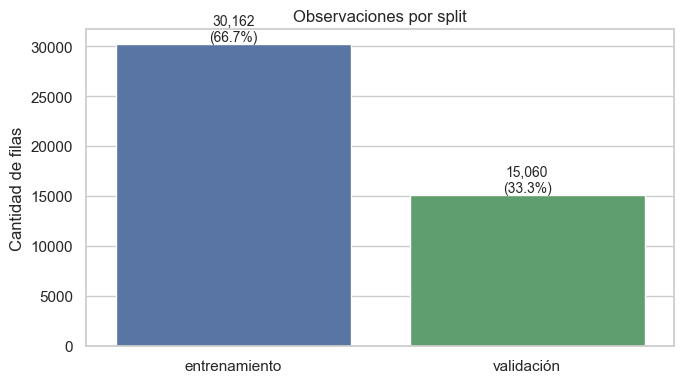

Total de observaciones: 45,222


In [177]:
# 4.0. Estadísticas descriptivas y tamaño de los splits
COLUMNAS_NUMERICAS = ["age", "capital-gain", "capital-loss", "hours-per-week"]

percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

print("=== 4.0 — Estadísticas descriptivas (train) ===")
display(df_entrenamiento[COLUMNAS_NUMERICAS].describe(percentiles=percentiles).T)

n_entrenamiento, n_validacion = len(df_entrenamiento), len(df_validacion)
n_total = n_entrenamiento + n_validacion

df_particiones = pd.DataFrame(
    {
        "particion": ["entrenamiento", "validación"],
        "filas": [n_entrenamiento, n_validacion],
        "proporcion": [n_entrenamiento / n_total, n_validacion / n_total],
    }
)

print("\n=== 4.0 — Filas por split ===")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df_particiones,
    x="particion",
    y="filas",
    order=["entrenamiento", "validación"],
    hue="particion",
    legend=False,
    palette={"entrenamiento": "#4C72B0", "validación": "#55A868"},
    ax=ax,
)
ax.set_title("Observaciones por split")
ax.set_xlabel("")
ax.set_ylabel("Cantidad de filas")

for barra, (_, fila) in zip(ax.patches, df_particiones.iterrows()):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(fila['filas']):,}\n({fila['proporcion'] * 100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

print(f"Total de observaciones: {n_total:,}")


#### 4.1. Variable objetivo (*income*)

Clasificación binaria: *<=50K* vs *>50K*. En el código siguiente vemos conteos y un gráfico de barras en train.

**Observaciones (train):**

- **Desbalance moderado:** ~75% *<=50K* y ~25% *>50K*. Un modelo que siempre predice la mayoría alcanzaría ~75% de accuracy sin aprender de verdad.
- **Métricas recomendadas:** conviene mirar **F1 macro**, **recall** de *>50K* y la **matriz de confusión**, no solo accuracy.
- **Calidad:** dos clases claras, sin valores faltantes.
- **Train vs val:** proporciones muy similares en validación (~24,6% *>50K*).



=== 4.1 — Target income (train) ===


,clase,conteo,porcentaje
0,<=50K,22654,75.107751
1,>50K,7508,24.892249



La clase '>50K' representa el 24.9% del train: hay desbalance de clases (mayoría '<=50K'). Conviene reportar F1 macro y no confiar solo en accuracy.


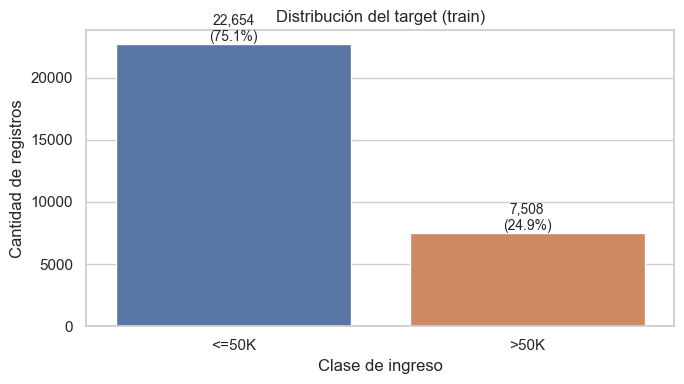

In [178]:
# 4.1. Distribución del target (income)
ORDEN_CLASES_OBJETIVO = ["<=50K", ">50K"]

df_objetivo = (
    df_entrenamiento[COLUMNA_OBJETIVO]
    .value_counts()
    .reindex(ORDEN_CLASES_OBJETIVO)
    .rename_axis("clase")
    .reset_index(name="conteo")
)
df_objetivo["porcentaje"] = 100 * df_objetivo["conteo"] / df_objetivo["conteo"].sum()

print(f"=== 4.1 — Target {COLUMNA_OBJETIVO} (train) ===")
display(df_objetivo)

pct_clase_minoritaria = df_objetivo.loc[df_objetivo["clase"] == ">50K", "porcentaje"].iloc[0]
print(
    f"\nLa clase '>50K' representa el {pct_clase_minoritaria:.1f}% del train: "
    "hay desbalance de clases (mayoría '<=50K'). "
    "Conviene reportar F1 macro y no confiar solo en accuracy."
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=df_objetivo,
    x="clase",
    y="conteo",
    order=ORDEN_CLASES_OBJETIVO,
    hue="clase",
    legend=False,
    palette={"<=50K": "#4C72B0", ">50K": "#DD8452"},
    ax=ax,
)
ax.set_title("Distribución del target (train)")
ax.set_xlabel("Clase de ingreso")
ax.set_ylabel("Cantidad de registros")

for barra, (_, fila) in zip(ax.patches, df_objetivo.iterrows()):
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura,
        f"{int(fila['conteo']):,}\n({fila['porcentaje']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


#### 4.2. Valores extremos en variables numéricas

Complementamos el resumen numérico con la proporción de **ceros** y **boxplots** de cada variable frente a *income* (train).

**Observaciones:**

- ***age*** y *hours-per-week*:** sin ceros; rangos acotados. En los boxplots las dos clases se parecen bastante.
- ***capital-gain***:** ~92% en cero; el resto tiene valores muy altos (cola larga). Quienes ganan >50K suelen tener medianas más altas.
- ***capital-loss***:** ~95% en cero; patrón similar a *capital-gain*.
- **Preprocesado:** en *capital-gain* y *capital-loss* conviene marcar si el valor es cero y, cuando no lo es, aplicar una transformación logarítmica antes de escalar.
- **Relación con el target:** *capital-gain* separa más las clases que *age* u *hours-per-week* (asociación, no causalidad).




=== 4.2 — Percentiles y proporción de ceros (train) ===


,% registros en cero
age,0.000000
capital-gain,91.585439
capital-loss,95.268881
hours-per-week,0.000000


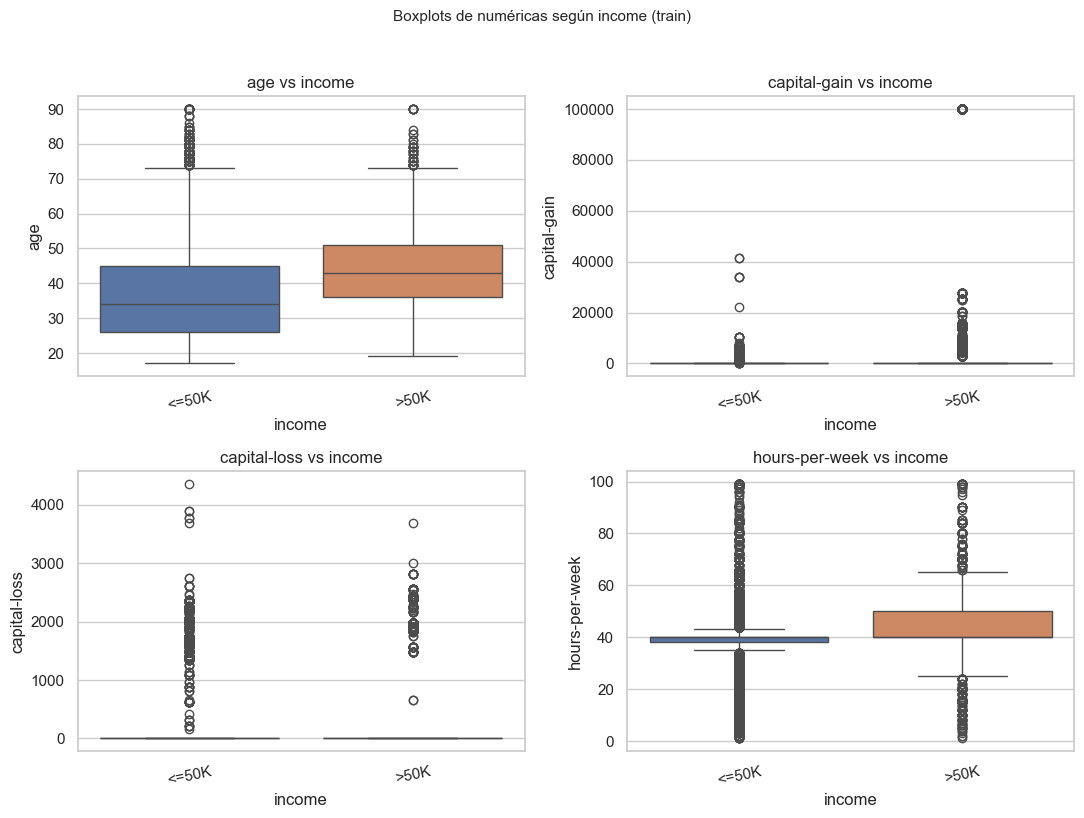

In [179]:
# 4.2. Valores extremos en numéricas
print("=== 4.2 — Percentiles y proporción de ceros (train) ===")

proporcion_ceros = (
    (df_entrenamiento[COLUMNAS_NUMERICAS] == 0)
    .mean()
    .mul(100)
    .rename("% registros en cero")
    .to_frame()
)
display(proporcion_ceros)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, columna in zip(axes, COLUMNAS_NUMERICAS):
    sns.boxplot(
        data=df_entrenamiento,
        x=COLUMNA_OBJETIVO,
        y=columna,
        order=ORDEN_CLASES_OBJETIVO,
        palette={"<=50K": "#4C72B0", ">50K": "#DD8452"},
        ax=ax,
    )
    ax.set_title(f"{columna} vs {COLUMNA_OBJETIVO}")
    ax.tick_params(axis="x", rotation=12)

fig.suptitle("Boxplots de numéricas según income (train)", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


#### 4.3. Cardinalidad por variable

Contamos cuántos valores distintos tiene cada columna en train. Para categóricas usamos el criterio del enunciado: **alta cardinalidad** si hay **10 o más** categorías.

**Alta cardinalidad:** *education*, *occupation*, *native-country*, *skill-profile*.

**Baja cardinalidad:** *workclass*, *marital-status*, *relationship*, *race*, *sex*.

La tabla completa aparece en el código siguiente.



In [180]:
# 4.3. Cardinalidad por variable
UMBRAL_ALTA_CARDINALIDAD = 10

columnas_categoricas = df_entrenamiento[columnas_predictoras].select_dtypes(include=["object", "string"]).columns.tolist()
conjunto_categoricas = set(columnas_categoricas)

filas_cardinalidad = []
for columna in columnas_predictoras:
    n_unicos = df_entrenamiento[columna].nunique()
    es_categorica = columna in conjunto_categoricas
    filas_cardinalidad.append(
        {
            "variable": columna,
            "tipo": "categórica" if es_categorica else "numérica",
            "valores_unicos": n_unicos,
            "alta_cardinalidad": es_categorica and n_unicos >= UMBRAL_ALTA_CARDINALIDAD,
        }
    )

df_cardinalidad = (
    pd.DataFrame(filas_cardinalidad)
    .sort_values(["tipo", "valores_unicos"], ascending=[True, False])
    .reset_index(drop=True)
)

columnas_alta_cardinalidad = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], "variable"
].tolist()

from IPython.display import HTML, display

df_alta_cardinalidad = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], ["variable", "tipo", "valores_unicos"]
].reset_index(drop=True)

print(
    f"=== 4.3 — Cardinalidad por variable "
    f"(alta cardinalidad en categóricas: ≥ {UMBRAL_ALTA_CARDINALIDAD} valores únicos) ==="
)

html_tabla_alta = (
    df_alta_cardinalidad.to_html(index=False, border=0)
    if len(df_alta_cardinalidad)
    else "<p style='margin:0'><em>ninguna</em></p>"
)

display(
    HTML(
        f"""
<div style="display:flex; flex-wrap:wrap; gap:2.5rem; align-items:flex-start;">
  <div>
    <p style="font-weight:600; margin:0 0 0.5rem 0;">Todas las variables</p>
    {df_cardinalidad.to_html(index=False, border=0)}
  </div>
  <div>
    <p style="font-weight:600; margin:0 0 0.5rem 0;">
      Alta cardinalidad ({len(columnas_alta_cardinalidad)})
    </p>
    {html_tabla_alta}
  </div>
</div>
"""
    )
)


=== 4.3 — Cardinalidad por variable (alta cardinalidad en categóricas: ≥ 10 valores únicos) ===


variable,tipo,valores_unicos,alta_cardinalidad
skill-profile,categórica,80,True
native-country,categórica,41,True
education,categórica,16,True
occupation,categórica,14,True
workclass,categórica,7,False
marital-status,categórica,7,False
relationship,categórica,6,False
race,categórica,5,False
sex,categórica,2,False
capital-gain,numérica,118,False


#### 4.4. Distribución — variables de alta cardinalidad

| Variable | Valores únicos | Gráfico | Motivo |
|----------|----------------|---------|--------|
| *education* | 16 | Barras en **orden educativo** | Tiene un orden natural de menor a mayor formación. |
| *occupation* | 14 | Barras por frecuencia | Pocas categorías, distribución relativamente pareja. |
| *native-country* | 41 | **Top-12 + Otros** | Domina *United-States* (~91%); el resto son muchos países minoritarios. |
| *skill-profile* | 80 | **Top-15 + Otros** | Demasiadas categorías para mostrarlas todas en un solo gráfico. |



=== 4.4 — Distribución de variables de alta cardinalidad (train) ===



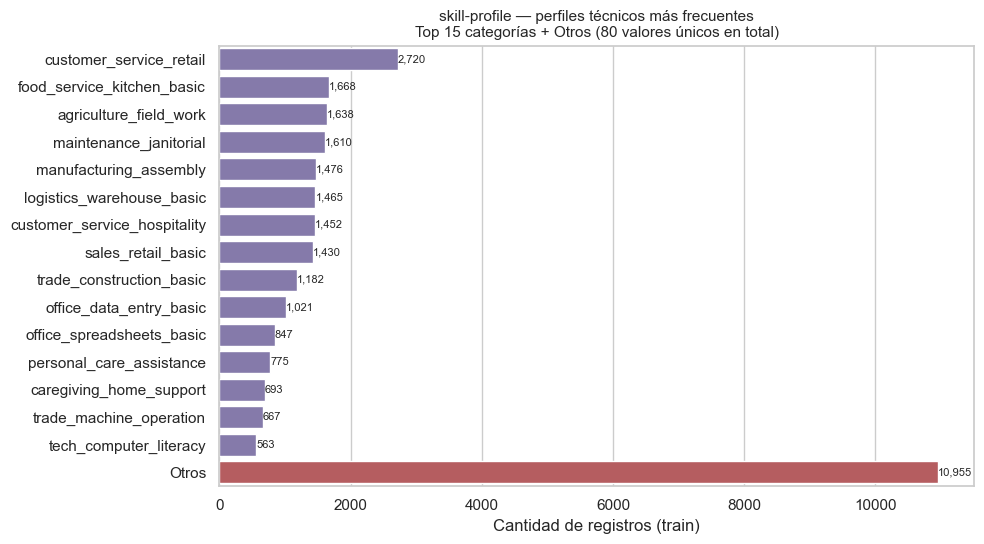

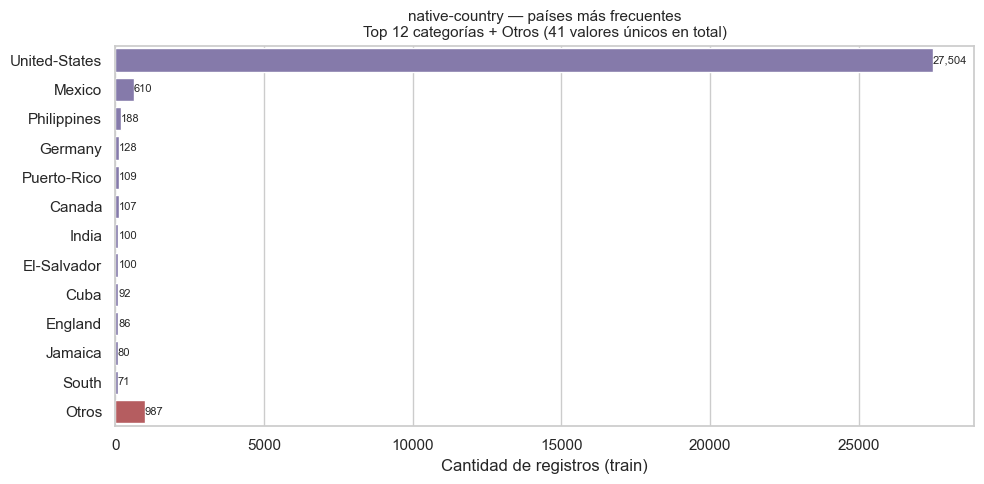

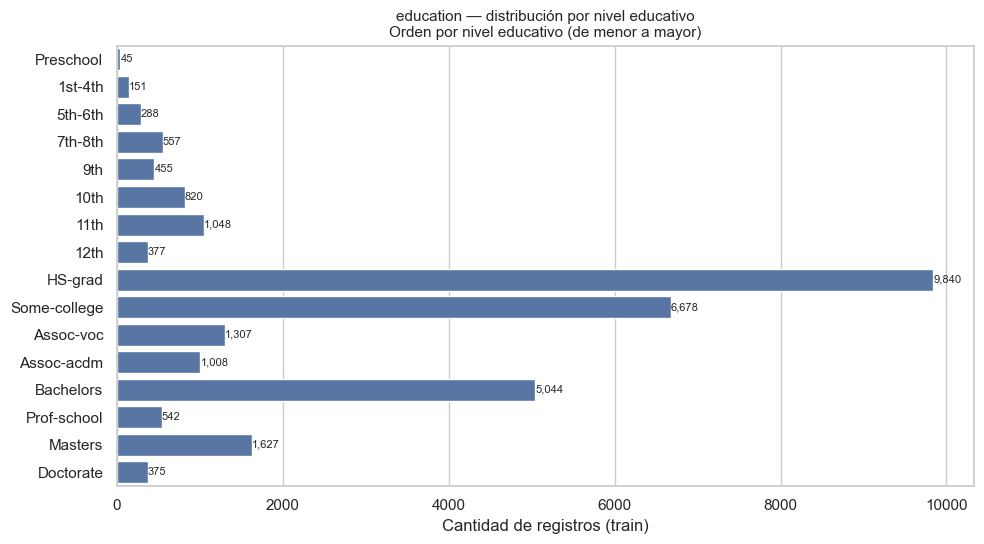

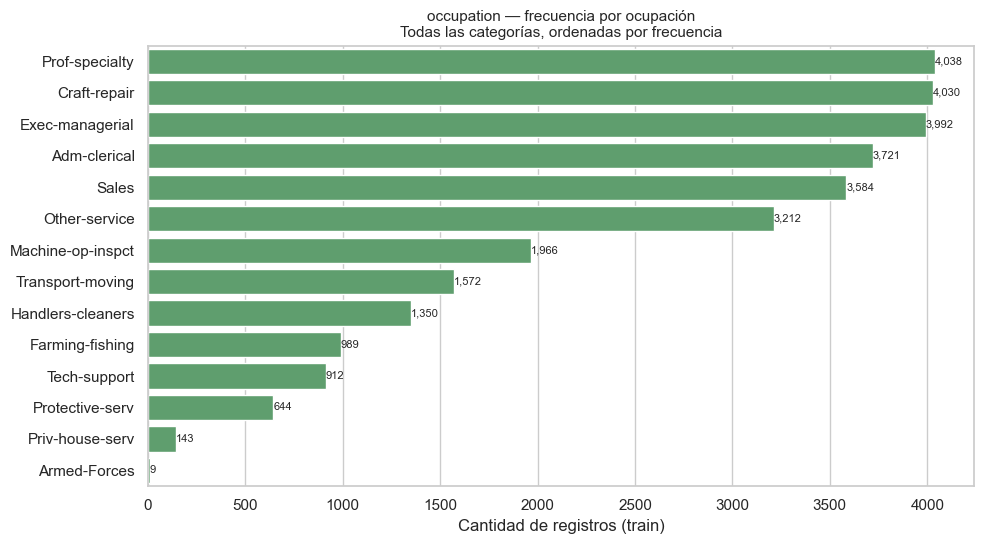

In [181]:
# 4.4. Distribución — alta cardinalidad

ORDEN_EDUCACION = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Prof-school",
    "Masters",
    "Doctorate",
]


def etiquetar_barras(ax, horizontal: bool = True) -> None:
    for parche in ax.patches:
        tamano = parche.get_width() if horizontal else parche.get_height()
        if tamano <= 0:
            continue
        etiqueta = f"{int(tamano):,}"
        if horizontal:
            ax.text(tamano, parche.get_y() + parche.get_height() / 2, etiqueta, va="center", ha="left", fontsize=8)
        else:
            ax.text(parche.get_x() + parche.get_width() / 2, tamano, etiqueta, ha="center", va="bottom", fontsize=8)


def graficar_distribucion_categorica(
    serie: pd.Series,
    *,
    titulo: str,
    estilo: str,
    n_superior: int | None = None,
    orden_categorias: list[str] | None = None,
) -> None:
    conteos = serie.value_counts()

    if estilo == "ordinal":
        orden = [c for c in (orden_categorias or []) if c in conteos.index]
        df_grafico = conteos.reindex(orden).dropna().reset_index()
        df_grafico.columns = ["categoria", "conteo"]
        altura_figura = max(5, 0.35 * len(df_grafico))
        fig, ax = plt.subplots(figsize=(10, altura_figura))
        sns.barplot(data=df_grafico, y="categoria", x="conteo", order=orden, color="#4C72B0", ax=ax)
        subtitulo = "Orden por nivel educativo (de menor a mayor)"

    elif estilo == "frecuencia_total":
        df_grafico = conteos.reset_index()
        df_grafico.columns = ["categoria", "conteo"]
        altura_figura = max(5, 0.4 * len(df_grafico))
        fig, ax = plt.subplots(figsize=(10, altura_figura))
        sns.barplot(data=df_grafico, y="categoria", x="conteo", color="#55A868", ax=ax)
        subtitulo = "Todas las categorías, ordenadas por frecuencia"

    elif estilo in ("n_superior", "top_n"):
        filas_superiores = conteos.head(n_superior)
        otros = conteos.iloc[n_superior:].sum()
        filas = [{"categoria": indice, "conteo": valor} for indice, valor in filas_superiores.items()]
        if otros > 0:
            filas.append({"categoria": "Otros", "conteo": otros})
        df_grafico = pd.DataFrame(filas)
        fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(df_grafico))))
        paleta = ["#C44E52" if categoria == "Otros" else "#8172B2" for categoria in df_grafico["categoria"]]
        sns.barplot(data=df_grafico, y="categoria", x="conteo", palette=paleta, ax=ax)
        subtitulo = f"Top {n_superior} categorías + Otros ({conteos.shape[0]} valores únicos en total)"
    else:
        raise ValueError(f"Estilo de gráfico no soportado: {estilo}")

    ax.set_title(f"{titulo}\n{subtitulo}", fontsize=11)
    ax.set_xlabel("Cantidad de registros (train)")
    ax.set_ylabel("")
    etiquetar_barras(ax, horizontal=True)
    plt.tight_layout()
    plt.show()


if not columnas_alta_cardinalidad:
    print("No hay variables de alta cardinalidad para graficar.")
else:
    especificaciones_grafico = {
        "education": {
            "titulo": "education — distribución por nivel educativo",
            "estilo": "ordinal",
            "orden_categorias": ORDEN_EDUCACION,
        },
        "occupation": {
            "titulo": "occupation — frecuencia por ocupación",
            "estilo": "frecuencia_total",
        },
        "native-country": {
            "titulo": "native-country — países más frecuentes",
            "estilo": "top_n",
            "n_superior": 12,
        },
        "skill-profile": {
            "titulo": "skill-profile — perfiles técnicos más frecuentes",
            "estilo": "top_n",
            "n_superior": 15,
        },
    }

    print("=== 4.4 — Distribución de variables de alta cardinalidad (train) ===\n")
    for columna in columnas_alta_cardinalidad:
        especificacion = especificaciones_grafico.get(columna)
        if especificacion is None:
            print(f"Sin especificación de gráfico para '{columna}' — se omite.")
            continue
        graficar_distribucion_categorica(df_entrenamiento[columna], **especificacion)


#### 4.5. Distribución — variables de baja cardinalidad

Categóricas con **menos de 10** valores únicos.

| Variable | Valores únicos | Gráfico | Motivo |
|----------|----------------|---------|--------|
| *workclass*, *marital-status*, *relationship*, *race* | 5–7 | Barras verticales (grilla 2×2) | Pocas categorías; se comparan bien en un panel. |
| *sex* | 2 | Torta | Solo dos clases; la proporción se ve de un vistazo. |



=== 4.5 — Distribución de variables categóricas de baja cardinalidad (5 variables, train) ===



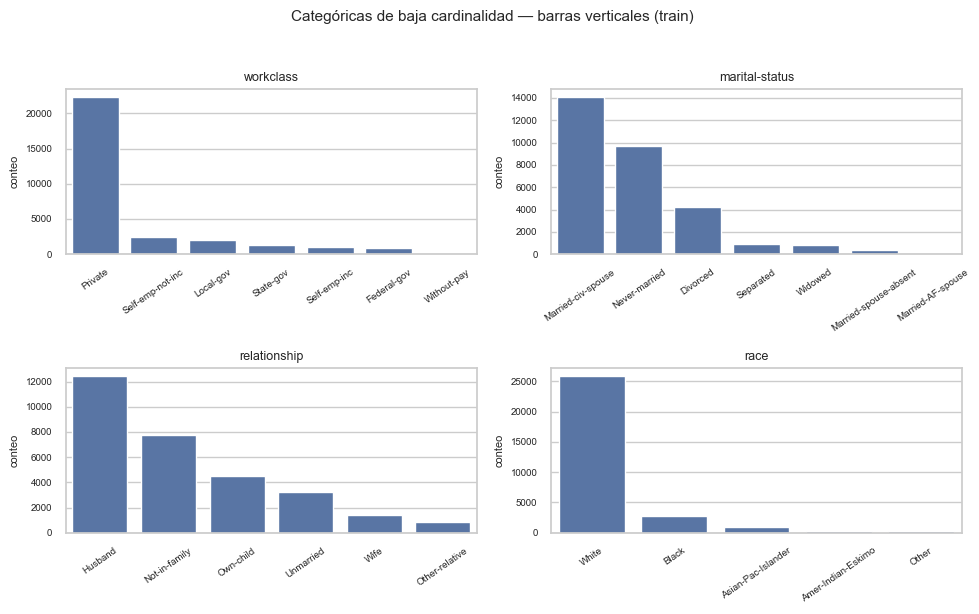

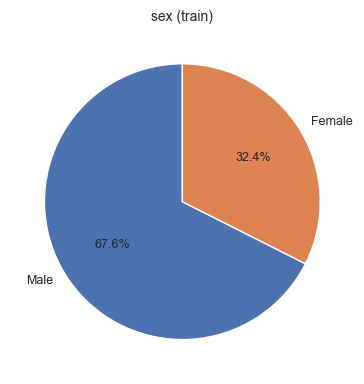

In [182]:
# 4.5. Distribución — baja cardinalidad

columnas_baja_cardinalidad = df_cardinalidad.loc[
    (df_cardinalidad["tipo"] == "categórica") & (~df_cardinalidad["alta_cardinalidad"]),
    "variable",
].tolist()

columnas_grafico_barras_baja = ["workclass", "marital-status", "relationship", "race"]
titulos_baja_cardinalidad = {
    "workclass": "workclass",
    "marital-status": "marital-status",
    "relationship": "relationship",
    "race": "race",
}

print(
    "=== 4.5 — Distribución de variables categóricas de baja cardinalidad "
    f"({len(columnas_baja_cardinalidad)} variables, train) ===\n"
)

if not columnas_baja_cardinalidad:
    print("No hay variables categóricas de baja cardinalidad para graficar.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    axes = axes.ravel()

    for ax, columna in zip(axes, columnas_grafico_barras_baja):
        df_grafico = (
            df_entrenamiento[columna]
            .value_counts()
            .sort_values(ascending=False)
            .reset_index()
        )
        df_grafico.columns = ["categoria", "conteo"]
        sns.barplot(data=df_grafico, x="categoria", y="conteo", color="#4C72B0", ax=ax)
        ax.set_title(titulos_baja_cardinalidad[columna], fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("conteo", fontsize=8)
        ax.tick_params(axis="x", rotation=35, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    fig.suptitle(
        "Categóricas de baja cardinalidad — barras verticales (train)",
        fontsize=11,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    if "sex" in columnas_baja_cardinalidad:
        conteos_sexo = df_entrenamiento["sex"].value_counts()
        fig, ax = plt.subplots(figsize=(4.5, 4))
        ax.pie(
            conteos_sexo,
            labels=conteos_sexo.index,
            autopct="%1.1f%%",
            startangle=90,
            colors=["#4C72B0", "#DD8452"],
            textprops={"fontsize": 9},
        )
        ax.set_title("sex (train)", fontsize=10)
        plt.tight_layout()
        plt.show()


#### 4.6. Distribución de variables numéricas

| Variable | Gráfico | Motivo |
|----------|---------|--------|
| *age* | Histograma + densidad | Distribución unimodal, sin ceros artificiales. |
| *hours-per-week* | Histograma + densidad | Valores continuos con cola moderada. |
| *capital-gain* | Torta (cero vs positivo) + histograma (valores positivos en escala log) | ~92% en cero; la cola positiva es muy asimétrica. |
| *capital-loss* | Igual que *capital-gain* | ~95% en cero; mismo patrón. |



=== 4.6 — Distribución de variables numéricas (train) ===



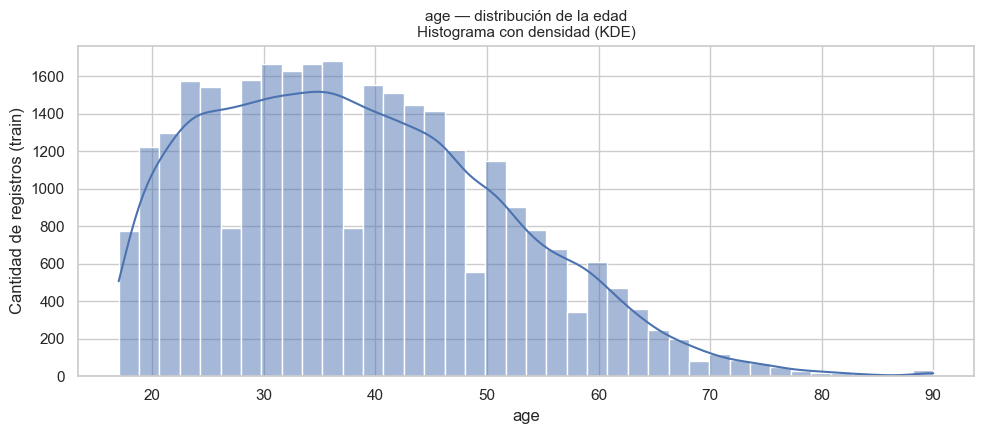

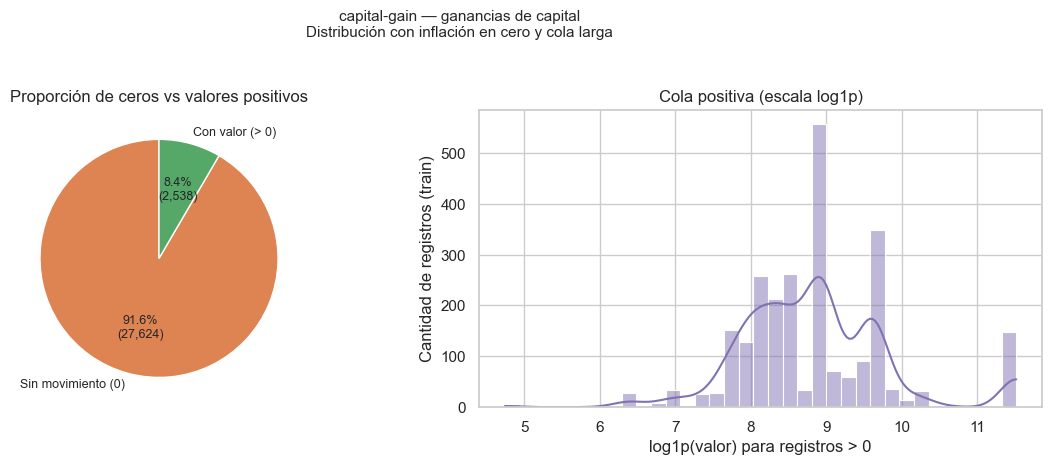

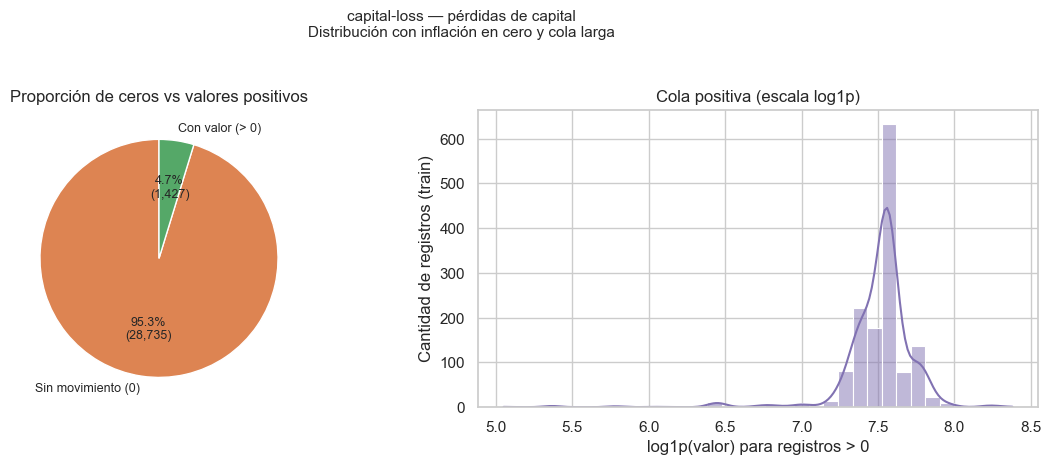

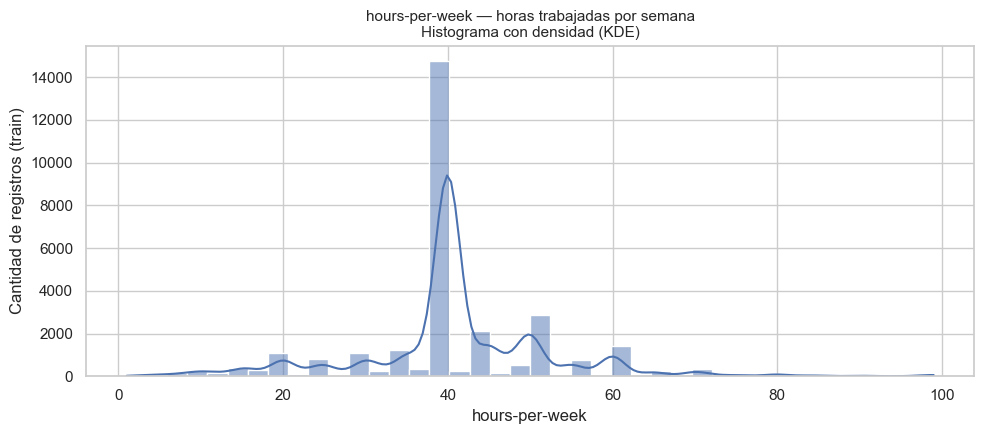

In [183]:
# 4.6. Distribución de numéricas


def graficar_distribucion_numerica(serie: pd.Series, *, titulo: str, estilo: str) -> None:
    if estilo == "histograma_kde":
        fig, ax = plt.subplots(figsize=(10, 4.5))
        sns.histplot(serie, bins=40, kde=True, color="#4C72B0", ax=ax)
        ax.set_xlabel(titulo.split("—")[0].strip())
        ax.set_ylabel("Cantidad de registros (train)")
        ax.set_title(f"{titulo}\nHistograma con densidad (KDE)", fontsize=11)
        plt.tight_layout()
        plt.show()
        return

    if estilo == "inflacion_ceros":
        conteo_ceros = (serie == 0).sum()
        valores_positivos = serie[serie > 0]
        conteo_positivos = len(valores_positivos)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

        etiquetas_torta = ["Sin movimiento (0)", "Con valor (> 0)"]
        tamanos_torta = [conteo_ceros, conteo_positivos]
        colores_torta = ["#DD8452", "#55A868"]

        axes[0].pie(
            tamanos_torta,
            labels=etiquetas_torta,
            autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct * len(serie) / 100)):,})",
            startangle=90,
            colors=colores_torta,
            textprops={"fontsize": 9},
        )
        axes[0].set_title("Proporción de ceros vs valores positivos")

        if conteo_positivos > 0:
            sns.histplot(np.log1p(valores_positivos), bins=35, kde=True, color="#8172B2", ax=axes[1])
            axes[1].set_xlabel("log1p(valor) para registros > 0")
        else:
            axes[1].text(0.5, 0.5, "Sin valores > 0", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Cola positiva (escala log1p)")
        axes[1].set_ylabel("Cantidad de registros (train)")

        fig.suptitle(
            f"{titulo}\nDistribución con inflación en cero y cola larga",
            fontsize=11,
            y=1.03,
        )
        plt.tight_layout()
        plt.show()
        return

    raise ValueError(f"Estilo de gráfico no soportado: {estilo}")


especificaciones_grafico_numerico = {
    "age": {
        "titulo": "age — distribución de la edad",
        "estilo": "histograma_kde",
    },
    "hours-per-week": {
        "titulo": "hours-per-week — horas trabajadas por semana",
        "estilo": "histograma_kde",
    },
    "capital-gain": {
        "titulo": "capital-gain — ganancias de capital",
        "estilo": "inflacion_ceros",
    },
    "capital-loss": {
        "titulo": "capital-loss — pérdidas de capital",
        "estilo": "inflacion_ceros",
    },
}

print("=== 4.6 — Distribución de variables numéricas (train) ===\n")
for columna in COLUMNAS_NUMERICAS:
    especificacion = especificaciones_grafico_numerico[columna]
    graficar_distribucion_numerica(df_entrenamiento[columna], **especificacion)


### 5. Análisis detallado por tipo de variable

Los histogramas, boxplots y gráficos de frecuencia ya están en **4**. Aquí profundizamos: correlación entre numéricas, inventario de categorías, relación con el target, categorías raras y comparación train vs val.


#### 5.1. Correlación entre variables numéricas

Vemos si las variables numéricas se relacionan entre sí (Pearson y Spearman).

**Conclusión (train):**

- Todas las correlaciones son **débiles** (por debajo de ~0,16 en valor absoluto): no hay redundancia fuerte.
- La asociación más visible es *age* ↔ *hours-per-week*: a mayor edad, algo más de horas en promedio, pero la relación es leve.
- *capital-gain* ↔ *capital-loss* casi no se correlacionan (muchos ceros en ambas).
- Las cuatro numéricas aportan información **complementaria**; el tratamiento especial de `capital-*` sigue siendo por los ceros, no por correlación.



=== 5.1 — Correlación entre numéricas (train) ===



,age,capital-gain,capital-loss,hours-per-week
age,1.000,0.080,0.060,0.102
capital-gain,0.080,1.000,-0.032,0.080
capital-loss,0.060,-0.032,1.000,0.052
hours-per-week,0.102,0.080,0.052,1.000


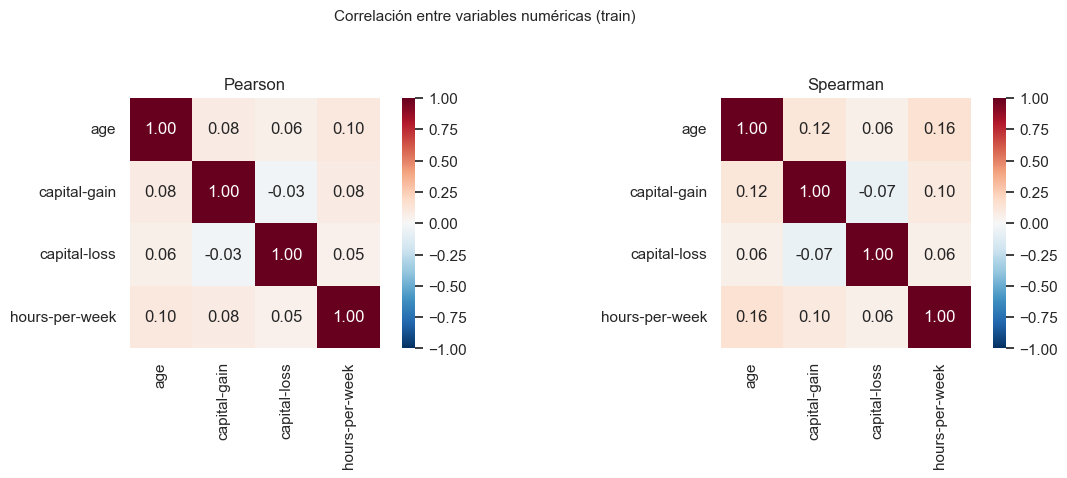

In [184]:
# 5.1. Correlación entre numéricas
df_numericas = df_entrenamiento[COLUMNAS_NUMERICAS]

correlacion_pearson = df_numericas.corr(method="pearson")
correlacion_spearman = df_numericas.corr(method="spearman")

print("=== 5.1 — Correlación entre numéricas (train) ===\n")
display(correlacion_pearson.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(
    correlacion_pearson,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[0],
)
axes[0].set_title("Pearson")

sns.heatmap(
    correlacion_spearman,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1],
)
axes[1].set_title("Spearman")

fig.suptitle("Correlación entre variables numéricas (train)", fontsize=11, y=1.05)
plt.tight_layout()
plt.show()


#### 5.2. Inventario de categorías

Para cada variable categórica listamos todas las categorías de train, ordenadas por frecuencia, con conteo y porcentaje.


In [185]:
# 5.2. Inventario de categorías


def tabla_frecuencia_categoria(serie: pd.Series) -> pd.DataFrame:
    tabla = (
        serie.value_counts()
        .rename_axis("categoria")
        .reset_index(name="conteo")
    )
    tabla["porcentaje"] = (100 * tabla["conteo"] / len(serie)).round(2)
    return tabla


print("=== 5.2 — Inventario de categorías (train) ===\n")

for columna in columnas_categoricas:
    n_unicos = df_entrenamiento[columna].nunique()
    print(f"--- {columna} ({n_unicos} categorías) ---")
    display(tabla_frecuencia_categoria(df_entrenamiento[columna]))


=== 5.2 — Inventario de categorías (train) ===

--- workclass (7 categorías) ---


,categoria,conteo,porcentaje
0,Private,22286,73.89
1,Self-emp-not-inc,2499,8.29
2,Local-gov,2067,6.85
3,State-gov,1279,4.24
4,Self-emp-inc,1074,3.56
5,Federal-gov,943,3.13
6,Without-pay,14,0.05


--- education (16 categorías) ---


,categoria,conteo,porcentaje
0,HS-grad,9840,32.62
1,Some-college,6678,22.14
2,Bachelors,5044,16.72
3,Masters,1627,5.39
4,Assoc-voc,1307,4.33
5,11th,1048,3.47
6,Assoc-acdm,1008,3.34
7,10th,820,2.72
8,7th-8th,557,1.85
9,Prof-school,542,1.80


--- marital-status (7 categorías) ---


...

,categoria,conteo,porcentaje
0,Male,20380,67.57
1,Female,9782,32.43


--- skill-profile (80 categorías) ---


,categoria,conteo,porcentaje
0,customer_service_retail,2720,9.02
1,food_service_kitchen_basic,1668,5.53
2,agriculture_field_work,1638,5.43
3,maintenance_janitorial,1610,5.34
4,manufacturing_assembly,1476,4.89
...,...,...,...
75,legal_office_support,48,0.16
76,education_research_methods,47,0.16
77,research_statistical_analysis,44,0.15
78,executive_decision_support,37,0.12


--- native-country (41 categorías) ---


,categoria,conteo,porcentaje
0,United-States,27504,91.19
1,Mexico,610,2.02
2,Philippines,188,0.62
3,Germany,128,0.42
4,Puerto-Rico,109,0.36
5,Canada,107,0.35
6,India,100,0.33
7,El-Salvador,100,0.33
8,Cuba,92,0.31
9,England,86,0.29


#### 5.3. Cardinalidad y gráficos de frecuencia

La cardinalidad y los gráficos de frecuencia ya se analizaron arriba:

- **Cardinalidad:** **4.3**
- **Gráficos:** **4.4** (alta cardinalidad) y **4.5** (baja cardinalidad)

**Recordatorio del criterio:** alta cardinalidad = **10 o más** categorías.

- **Alta:** *education*, *occupation*, *native-country*, *skill-profile*.
- **Baja:** *workclass*, *marital-status*, *relationship*, *race*, *sex*.



#### 5.4. Relación entre categóricas e *income*

Medimos qué porcentaje de cada categoría corresponde a *>50K*. Ayuda a ver qué variables separan mejor las clases (sin implicar causalidad).

En variables con muchas categorías mostramos las **12 más frecuentes** en el gráfico; el resto sigue en las tablas.

**Conclusión (train):**

- ***education*** / *occupation*:** más *>50K* en estudios altos y oficios como *Exec-managerial*.
- ***sex***:** *Male* ~31% vs *Female* ~11%.
- ***marital-status***:** *Married-civ-spouse* ~46%, muy por encima de *Never-married*.
- ***native-country*** / *skill-profile*:** dominan pocas categorías; en las raras las tasas son poco fiables.




=== 5.4 — Relación categóricas vs income (train) ===

Top categorías por % >50K (conteo ≥ 50 en train):


,variable,categoria,conteo,pct_mayor_50k
0,workclass,Self-emp-inc,1074,55.9
1,workclass,Federal-gov,943,38.7
2,workclass,Local-gov,2067,29.5
3,education,Prof-school,542,74.9
4,education,Doctorate,375,74.7
5,education,Masters,1627,56.4
6,marital-status,Married-civ-spouse,14065,45.5
7,marital-status,Divorced,4214,10.7
8,marital-status,Widowed,827,9.7
9,occupation,Exec-managerial,3992,48.5


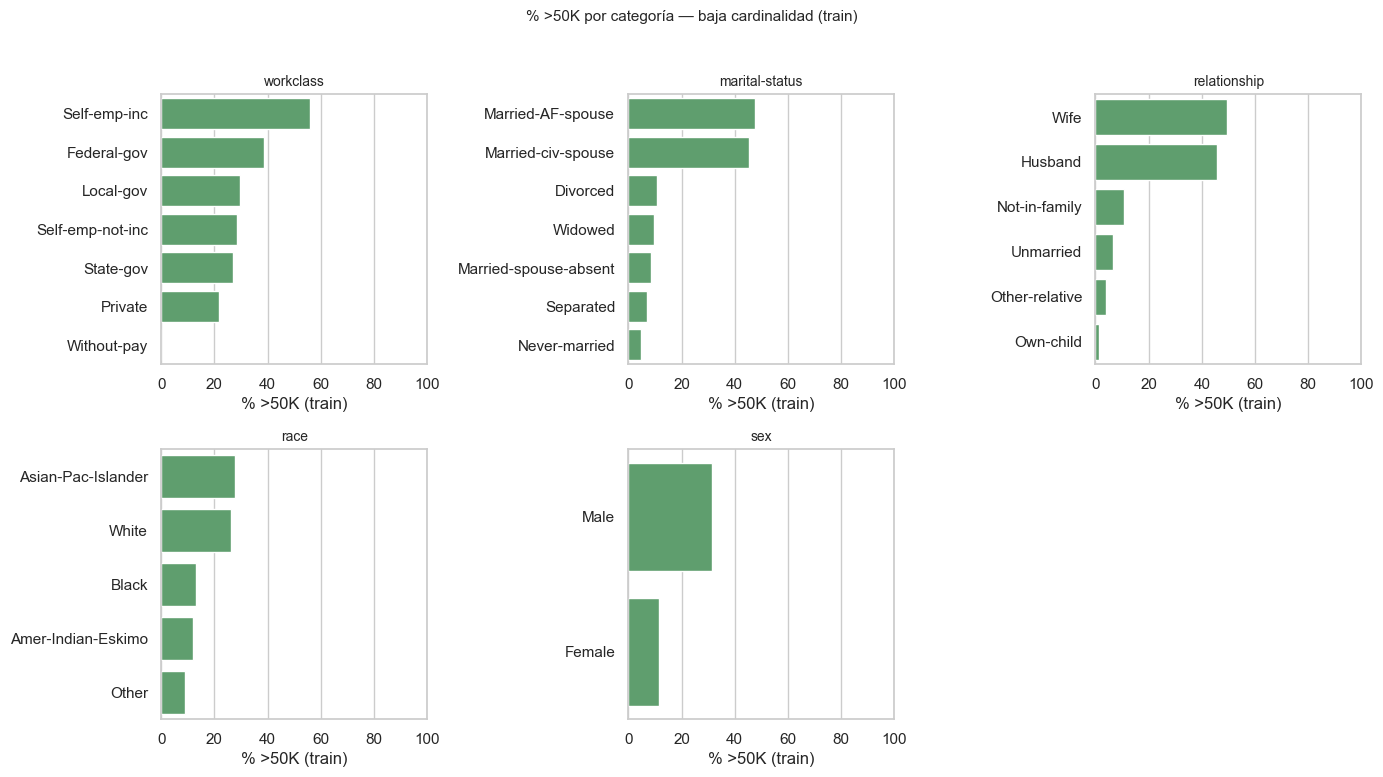

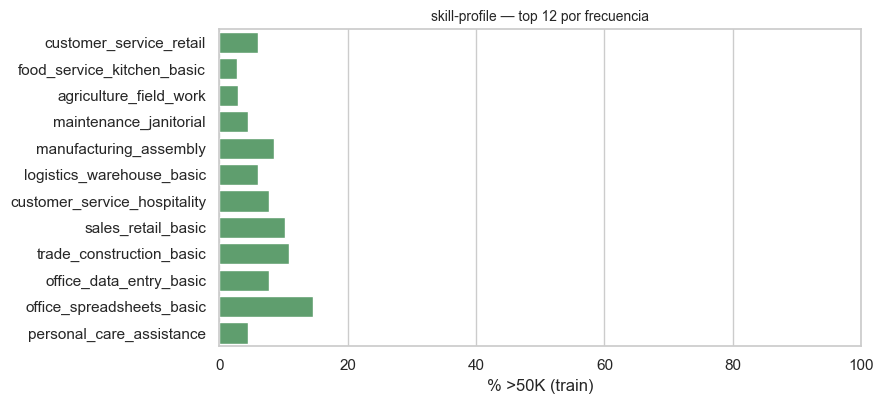

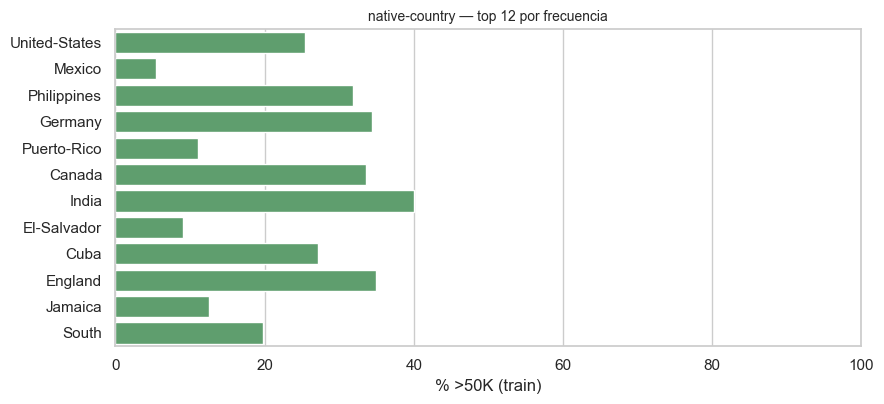

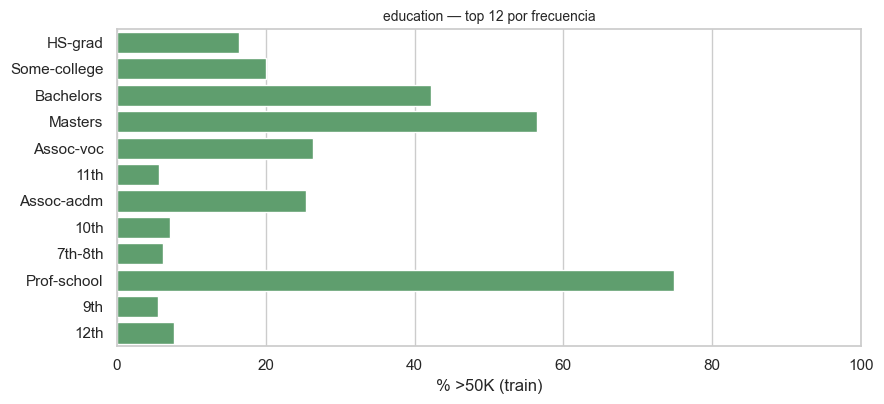

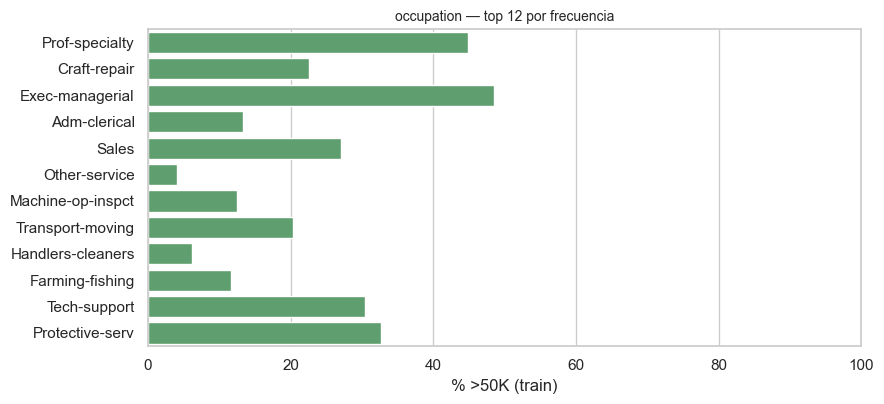

In [186]:
# 5.4. Proporción de >50K por categoría
ETIQUETA_CLASE_MAYOR_50K = ">50K"
CONTEO_MINIMO_RESUMEN = 50
TOP_N_ALTA_CARDINALIDAD = 12

columnas_baja_cardinalidad = df_cardinalidad.loc[
    (df_cardinalidad["tipo"] == "categórica") & (~df_cardinalidad["alta_cardinalidad"]),
    "variable",
].tolist()
columnas_alta_cardinalidad_grafico = df_cardinalidad.loc[
    df_cardinalidad["alta_cardinalidad"], "variable"
].tolist()


def tasa_ingreso_por_categoria(df: pd.DataFrame, columna: str) -> pd.DataFrame:
    estadisticas = (
        df.groupby(columna, observed=True)
        .agg(
            conteo=(COLUMNA_OBJETIVO, "size"),
            pct_mayor_50k=(COLUMNA_OBJETIVO, lambda s: 100 * (s == ETIQUETA_CLASE_MAYOR_50K).mean()),
        )
        .reset_index()
        .rename(columns={columna: "categoria"})
    )
    return estadisticas.sort_values("pct_mayor_50k", ascending=False)


def graficar_tasa_ingreso(
    estadisticas: pd.DataFrame,
    *,
    titulo: str,
    n_superior: int | None = None,
    ax=None,
) -> None:
    df_grafico = estadisticas.head(n_superior) if n_superior else estadisticas
    figura_creada = ax is None
    if figura_creada:
        fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(df_grafico))))

    sns.barplot(
        data=df_grafico,
        y="categoria",
        x="pct_mayor_50k",
        color="#55A868",
        ax=ax,
    )
    ax.set_xlabel(f"% {ETIQUETA_CLASE_MAYOR_50K} (train)")
    ax.set_ylabel("")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlim(0, 100)

    if figura_creada:
        plt.tight_layout()
        plt.show()


print("=== 5.4 — Relación categóricas vs income (train) ===\n")

# Resumen: filas_superiores 3 categorías con mayor % >50K (conteo mínimo)
filas_resumen = []
for columna in columnas_categoricas:
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    primeras_tres = estadisticas[estadisticas["conteo"] >= CONTEO_MINIMO_RESUMEN].head(3)
    for _, fila in primeras_tres.iterrows():
        filas_resumen.append(
            {
                "variable": columna,
                "categoria": fila["categoria"],
                "conteo": int(fila["conteo"]),
                "pct_mayor_50k": round(fila["pct_mayor_50k"], 1),
            }
        )

print(f"Top categorías por % {ETIQUETA_CLASE_MAYOR_50K} (conteo ≥ {CONTEO_MINIMO_RESUMEN} en train):")
display(pd.DataFrame(filas_resumen))

# Baja cardinalidad: grilla 2×3
n_baja = len(columnas_baja_cardinalidad)
n_columnas = 3
n_filas = (n_baja + n_columnas - 1) // n_columnas
fig, axes = plt.subplots(n_filas, n_columnas, figsize=(14, 3.8 * n_filas))
axes = axes.ravel()

for ax, columna in zip(axes, columnas_baja_cardinalidad):
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    graficar_tasa_ingreso(estadisticas, titulo=columna, ax=ax)

for ax in axes[len(columnas_baja_cardinalidad) :]:
    ax.axis("off")

fig.suptitle(
    f"% {ETIQUETA_CLASE_MAYOR_50K} por categoría — baja cardinalidad (train)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Alta cardinalidad: una figura por variable (filas_superiores-N por frecuencia)
for columna in columnas_alta_cardinalidad_grafico:
    orden_frecuencia = df_entrenamiento[columna].value_counts().head(TOP_N_ALTA_CARDINALIDAD).index
    estadisticas = tasa_ingreso_por_categoria(df_entrenamiento, columna)
    estadisticas_top = estadisticas[estadisticas["categoria"].isin(orden_frecuencia)].copy()
    estadisticas_top["categoria"] = pd.Categorical(
        estadisticas_top["categoria"], categories=list(orden_frecuencia), ordered=True
    )
    estadisticas_top = estadisticas_top.sort_values("categoria")
    graficar_tasa_ingreso(
        estadisticas_top,
        titulo=f"{columna} — top {TOP_N_ALTA_CARDINALIDAD} por frecuencia",
    )


#### 5.5. Categorías poco frecuentes y consistencia train / val

Revisamos categorías con **menos de 50 registros en train** y si aparecen en val.

**Criterio:** rara en train = menos de 50 filas.

**Conclusión:**

- **Sin sorpresas graves:** ninguna categoría aparece **solo en val**.
- **Solo en train:** *Holand-Netherlands* en *native-country* (1 registro); impacto mínimo.
- **Más rarezas:** *native-country* (~21 categorías raras) y *skill-profile* (~5).
- **Agrupar o mantener:** en *native-country* y *skill-profile* conviene **juntar las categorías que casi no aparecen** en *Otra* / *Desconocido*. En baja cardinalidad (*sex*, *race*, etc.) **mantener** las categorías tal cual.



In [187]:
# 5.5. Categorías raras y cobertura en val
UMBRAL_CONTEO_RARO = 50


def reporte_categoria_entrenamiento_validacion(
    marco_entrenamiento: pd.DataFrame,
    marco_validacion: pd.DataFrame,
    columna: str,
    *,
    umbral_rareza: int,
) -> pd.DataFrame:
    conteos_entrenamiento = marco_entrenamiento[columna].value_counts()
    conteos_validacion = marco_validacion[columna].value_counts()
    categorias = conteos_entrenamiento.index.union(conteos_validacion.index)

    filas = []
    for categoria in categorias:
        n_entrenamiento_cat = int(conteos_entrenamiento.get(categoria, 0))
        n_validacion_cat = int(conteos_validacion.get(categoria, 0))
        filas.append(
            {
                "categoria": categoria,
                "conteo_entrenamiento": n_entrenamiento_cat,
                "conteo_validacion": n_validacion_cat,
                "rara_en_entrenamiento": 0 < n_entrenamiento_cat < umbral_rareza,
                "solo_en_entrenamiento": n_entrenamiento_cat > 0 and n_validacion_cat == 0,
                "solo_en_validacion": n_validacion_cat > 0 and n_entrenamiento_cat == 0,
            }
        )

    return (
        pd.DataFrame(filas)
        .sort_values(["rara_en_entrenamiento", "solo_en_entrenamiento", "conteo_entrenamiento"], ascending=[False, False, True])
        .reset_index(drop=True)
    )


print(
    f"=== 5.5 — Categorías raras en train (< {UMBRAL_CONTEO_RARO} registros) y presencia en val ===\n"
)

# Si no ejecutaste 4.3, derivamos aquí la lista de categóricas.
if "columnas_categoricas" not in globals():
    columnas_categoricas = (
        df_entrenamiento[columnas_predictoras]
        .select_dtypes(include=["object", "string"])
        .columns.tolist()
    )

filas_resumen = []
tablas_detalle: dict[str, pd.DataFrame] = {}

for columna in columnas_categoricas:
    informe = reporte_categoria_entrenamiento_validacion(
        df_entrenamiento, df_validacion, columna, umbral_rareza=UMBRAL_CONTEO_RARO
    )
    n_raras = int(informe["rara_en_entrenamiento"].sum())
    n_solo_entrenamiento = int(informe["solo_en_entrenamiento"].sum())
    n_solo_validacion = int(informe["solo_en_validacion"].sum())

    filas_resumen.append(
        {
            "variable": columna,
            "categorias_raras_entrenamiento": n_raras,
            "solo_en_entrenamiento": n_solo_entrenamiento,
            "solo_en_validacion": n_solo_validacion,
        }
    )

    if n_raras > 0 or n_solo_entrenamiento > 0 or n_solo_validacion > 0:
        tablas_detalle[columna] = informe

df_resumen_raras = pd.DataFrame(filas_resumen)
display(df_resumen_raras)

for columna, informe in tablas_detalle.items():
    detalle = informe[
        informe["rara_en_entrenamiento"] | informe["solo_en_entrenamiento"] | informe["solo_en_validacion"]
    ][
        [
            "categoria",
            "conteo_entrenamiento",
            "conteo_validacion",
            "rara_en_entrenamiento",
            "solo_en_entrenamiento",
            "solo_en_validacion",
        ]
    ]
    print(f"\n--- {columna} — detalle (raras / solo en un split) ---")
    display(detalle)


=== 5.5 — Categorías raras en train (< 50 registros) y presencia en val ===



,variable,categorias_raras_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,workclass,1,0,0
1,education,1,0,0
2,marital-status,1,0,0
3,occupation,1,0,0
4,relationship,0,0,0
5,race,0,0,0
6,sex,0,0,0
7,skill-profile,5,0,0
8,native-country,21,1,0



--- workclass — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Without-pay,14,7,True,False,False



--- education — detalle (raras / solo en un split) ---


...

,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Armed-Forces,9,5,True,False,False



--- skill-profile — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,research_scientific_writing,26,19,True,False,False
1,executive_decision_support,37,16,True,False,False
2,research_statistical_analysis,44,19,True,False,False
3,education_research_methods,47,20,True,False,False
4,legal_office_support,48,28,True,False,False



--- native-country — detalle (raras / solo en un split) ---


,categoria,conteo_entrenamiento,conteo_validacion,rara_en_entrenamiento,solo_en_entrenamiento,solo_en_validacion
0,Holand-Netherlands,1,0,True,True,False
1,Scotland,11,9,True,False,False
2,Honduras,12,7,True,False,False
3,Hungary,13,5,True,False,False
4,Outlying-US(Guam-USVI-etc),14,8,True,False,False
5,Yugoslavia,16,7,True,False,False
6,Laos,17,4,True,False,False
7,Thailand,17,12,True,False,False
8,Cambodia,18,8,True,False,False
9,Trinadad&Tobago,18,8,True,False,False


#### 5.6. Comparación train vs val

Comprobamos si train y val vienen del mismo “mundo”: mismas proporciones de target y de variables clave.

**Variables revisadas:** *income*, *age*, *hours-per-week*, *education*, *workclass*.

**Conclusión:**

- **Target:** proporciones casi iguales (~75% *<=50K* en ambos).
- **Numéricas:** distribuciones muy parecidas.
- **Categóricas:** diferencias menores a ~1 punto porcentual por categoría.
- **No hay cambio de distribución evidente** entre splits; el preprocesado debe enfocarse en cardinalidad y rarezas, no en “igualar” train y val.



=== 5.6 — Train vs val: target y features clave ===



,clase,pct_entrenamiento,pct_validacion,diff_pp
0,<=50K,75.11,75.43,0.32
1,>50K,24.89,24.57,-0.32


Chi-cuadrado target (train vs val): p = 0.4592



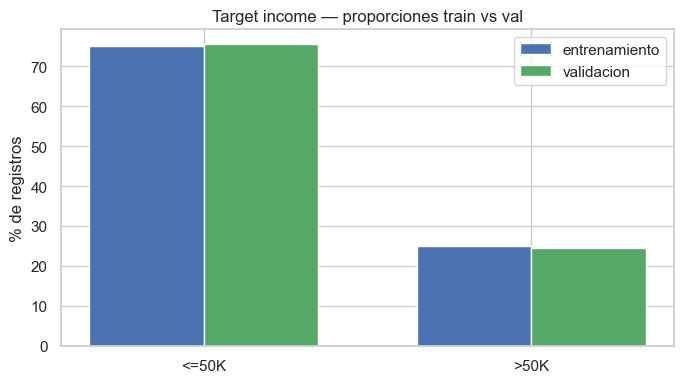

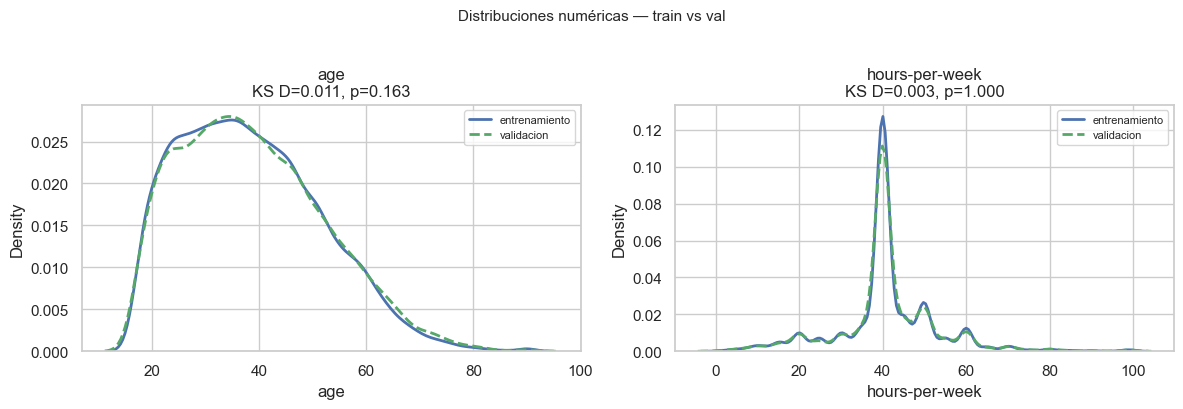

Prueba KS (numéricas):


,variable,estadistico_ks,p_valor
0,age,0.0112,0.1625
1,hours-per-week,0.0027,1.0000



Máxima diferencia de proporción por categoría (puntos porcentuales):


,variable,max_diff_pp
0,education,0.75
1,workclass,0.71
2,native-country,0.37


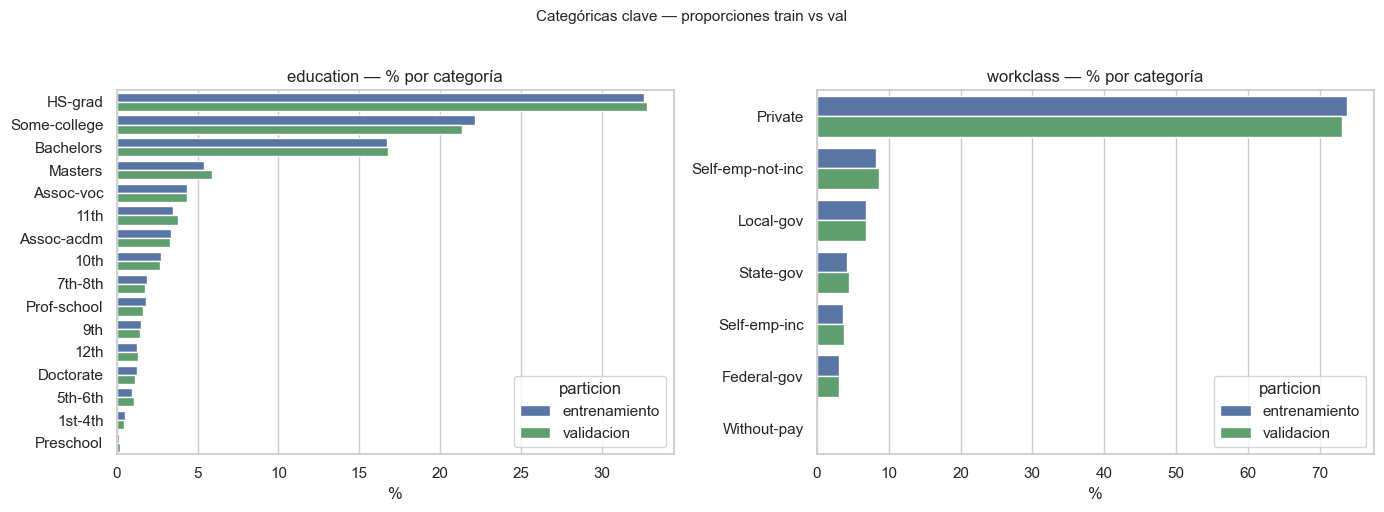

In [188]:
# 5.6. Comparación train vs val
from scipy import stats

ORDEN_CLASES_OBJETIVO = ["<=50K", ">50K"]
COLUMNAS_NUMERICAS_SHIFT = ["age", "hours-per-week"]
COLUMNAS_CATEGORICAS_SHIFT = ["education", "workclass"]

print("=== 5.6 — Train vs val: target y features clave ===\n")


def proporciones_target(df: pd.DataFrame) -> pd.Series:
    return (
        df[COLUMNA_OBJETIVO]
        .value_counts(normalize=True)
        .reindex(ORDEN_CLASES_OBJETIVO)
        .mul(100)
        .round(2)
    )


prop_entrenamiento = proporciones_target(df_entrenamiento)
prop_validacion = proporciones_target(df_validacion)

df_comparacion_target = pd.DataFrame(
    {
        "clase": ORDEN_CLASES_OBJETIVO,
        "pct_entrenamiento": prop_entrenamiento.values,
        "pct_validacion": prop_validacion.values,
    }
)
df_comparacion_target["diff_pp"] = (
    df_comparacion_target["pct_validacion"] - df_comparacion_target["pct_entrenamiento"]
).round(2)

display(df_comparacion_target)

tabla_chi = pd.DataFrame(
    {
        "entrenamiento": df_entrenamiento[COLUMNA_OBJETIVO].value_counts(),
        "validacion": df_validacion[COLUMNA_OBJETIVO].value_counts(),
    }
).fillna(0)
_, p_chi_target, _, _ = stats.chi2_contingency(tabla_chi)
print(f"Chi-cuadrado target (train vs val): p = {p_chi_target:.4f}\n")

# --- Gráfico: target ---
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(ORDEN_CLASES_OBJETIVO))
ancho = 0.35
ax.bar(x - ancho / 2, prop_entrenamiento.values, width=ancho, label="entrenamiento", color="#4C72B0")
ax.bar(x + ancho / 2, prop_validacion.values, width=ancho, label="validacion", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(ORDEN_CLASES_OBJETIVO)
ax.set_ylabel("% de registros")
ax.set_title("Target income — proporciones train vs val")
ax.legend()
plt.tight_layout()
plt.show()

# --- Numéricas: KDE superpuesta ---
filas_ks = []
fig, axes = plt.subplots(1, len(COLUMNAS_NUMERICAS_SHIFT), figsize=(12, 4))
if len(COLUMNAS_NUMERICAS_SHIFT) == 1:
    axes = [axes]

for ax, columna in zip(axes, COLUMNAS_NUMERICAS_SHIFT):
    sns.kdeplot(df_entrenamiento[columna], ax=ax, label="entrenamiento", color="#4C72B0", linewidth=2)
    sns.kdeplot(df_validacion[columna], ax=ax, label="validacion", color="#55A868", linewidth=2, linestyle="--")
    estadistico_ks, p_valor = stats.ks_2samp(df_entrenamiento[columna], df_validacion[columna])
    filas_ks.append(
        {
            "variable": columna,
            "estadistico_ks": round(estadistico_ks, 4),
            "p_valor": round(p_valor, 4),
        }
    )
    ax.set_title(f"{columna}\nKS D={estadistico_ks:.3f}, p={p_valor:.3f}")
    ax.set_xlabel(columna)
    ax.legend(fontsize=8)

fig.suptitle("Distribuciones numéricas — train vs val", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

df_prueba_ks = pd.DataFrame(filas_ks)
print("Prueba KS (numéricas):")
display(df_prueba_ks)

# --- Categóricas: máxima diferencia de proporción ---
COLUMNAS_TABLA_CATEGORICAS = COLUMNAS_CATEGORICAS_SHIFT + ["native-country"]
filas_cat = []
for columna in COLUMNAS_TABLA_CATEGORICAS:
    pct_ent = df_entrenamiento[columna].value_counts(normalize=True)
    pct_val = df_validacion[columna].value_counts(normalize=True)
    categorias = pct_ent.index.union(pct_val.index)
    diffs = [abs(pct_ent.get(cat, 0) - pct_val.get(cat, 0)) for cat in categorias]
    max_diff_pp = 100 * max(diffs)
    filas_cat.append({"variable": columna, "max_diff_pp": round(max_diff_pp, 2)})

print("\nMáxima diferencia de proporción por categoría (puntos porcentuales):")
display(pd.DataFrame(filas_cat))

fig, axes = plt.subplots(1, len(COLUMNAS_CATEGORICAS_SHIFT), figsize=(14, 5))
if len(COLUMNAS_CATEGORICAS_SHIFT) == 1:
    axes = [axes]

for ax, columna in zip(axes, COLUMNAS_CATEGORICAS_SHIFT):
    pct_ent = df_entrenamiento[columna].value_counts(normalize=True).mul(100)
    pct_val = df_validacion[columna].value_counts(normalize=True).mul(100)
    categorias = pct_ent.index.union(pct_val.index)
    orden = pct_ent.reindex(categorias).fillna(0).sort_values(ascending=False).index

    df_grafico = pd.DataFrame(
        {
            "categoria": list(orden),
            "entrenamiento": [pct_ent.get(c, 0) for c in orden],
            "validacion": [pct_val.get(c, 0) for c in orden],
        }
    )
    df_largo = df_grafico.melt(id_vars="categoria", var_name="particion", value_name="porcentaje")

    sns.barplot(
        data=df_largo,
        y="categoria",
        x="porcentaje",
        hue="particion",
        order=list(orden),
        ax=ax,
        palette={"entrenamiento": "#4C72B0", "validacion": "#55A868"},
    )
    ax.set_title(f"{columna} — % por categoría")
    ax.set_xlabel("%")
    ax.set_ylabel("")

fig.suptitle("Categóricas clave — proporciones train vs val", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


#### 5.7. Hallazgos para el preprocesado

Resumen de lo visto en **3** a **5**:

**Calidad:** sin faltantes ni duplicados; typos puntuales en *native-country* (*Holand-Netherlands*, `Trinadad&Tobago`).

**Target:** desbalance moderado → F1 macro y recall de *>50K*.

**Numéricas:** escalado estándar en *age* y *hours-per-week*; indicador de cero + transformación logarítmica + escalado en *capital-gain* y *capital-loss*.

**Categóricas:** cuatro de alta cardinalidad; agrupar rarezas en *Otra*/*Desconocido*; embeddings en modelo **(b)**, one-hot en **(c)** donde corresponda.

**Train / val:** alineados; vocabularios solo desde train.



### 6. Decisiones de transformación

A partir del EDA definimos cómo preprocesar **cada** variable para los modelos **(b)** y **(c)**. No implementamos el pipeline aquí; solo fijamos criterios y decisiones.


#### 6.1. Cardinalidad

**Criterio:** si una categórica tiene **10 o más** valores distintos → **alta cardinalidad** (embedding en el modelo **(b)** o agrupar categorías poco frecuentes). Con menos de 10 → **baja cardinalidad** (one-hot).

Ver **4.3** e inventario en **5.2**.

| Variable | Tipo | Valores únicos | Clasificación | Implicancia |
|----------|------|----------------|---------------|-------------|
| *age* | numérica | 72 | — | Se escala; no es categórica. |
| *capital-gain* | numérica | 118 | — | Escalado y tratamiento de ceros (**4.6**). |
| *capital-loss* | numérica | 90 | — | Igual que *capital-gain*. |
| *hours-per-week* | numérica | 94 | — | Escalado estándar. |
| *workclass* | categórica | 7 | Baja | One-hot (7 columnas). |
| *marital-status* | categórica | 7 | Baja | One-hot. |
| *relationship* | categórica | 6 | Baja | One-hot. |
| *race* | categórica | 5 | Baja | One-hot. |
| *sex* | categórica | 2 | Baja | One-hot o un bit. |
| *education* | categórica | 16 | Alta | Ordinal o one-hot; ver **6.2**. |
| *occupation* | categórica | 14 | Alta | Embedding en (b); one-hot en (c). |
| *native-country* | categórica | 41 | Alta | Agrupar rarezas + embedding en (b). |
| *skill-profile* | categórica | 80 | Alta | Agrupar rarezas + embedding en (b). |

**Resumen:** alta cardinalidad en *education*, *occupation*, *native-country*, *skill-profile*. Baja en las otras cinco categóricas.



#### 6.2. Contexto semántico (nominal vs ordinal)

**Ordinal:** las categorías tienen un orden con sentido → puede usarse codificación ordinal.

**Nominal:** son etiquetas sin orden → one-hot o embedding, sin asignar números 1, 2, 3… al azar.

Orden de *education* definido en **4.4**.

| Variable | Naturaleza | Codificación coherente |
|----------|------------|------------------------|
| *education* | **Ordinal** | Ordinal (orden educativo) o embedding |
| *marital-status*, *relationship*, *workclass*, *occupation*, *race*, *sex*, *native-country*, *skill-profile* | **Nominal** | One-hot o embedding; no ordinal arbitrario |

Las numéricas no aplican: son cantidades, no categorías.



#### 6.3. Relación con el target

Basado en **5.4** (categóricas) y **4.2** (numéricas). Criterio: **fuerte** = diferencia clara entre categorías o medias por clase; **moderada** = separación visible pero con solapamiento.

**Categóricas con señal fuerte:** *education*, *occupation*, *relationship*, *marital-status*, *workclass*, *sex*, *skill-profile* (con cautela por rarezas).

**Moderada:** *race*, *native-country*.

**Numéricas:** *capital-gain* fuerte; *age*, *hours-per-week*, *capital-loss* moderadas.

Todas pueden aportar en conjunto en la red.



#### 6.4. Estabilidad train / val

Basado en **5.5** y **5.6**.

- Target y features clave con proporciones casi iguales.
- Ninguna categoría solo en val; una sola solo en train (typo en país).
- Vocabularios y escaladores se ajustan **solo con train**; reservar *Desconocido* / *Otra* para valores nuevos.



#### 6.5. Tabla de transformaciones por variable

Resume **6.1** a **6.4**. Reglas generales:

1. Ajustar mapeos y escaladores **solo con train**; aplicar lo mismo a val.
2. En *native-country* y *skill-profile*: top-N frecuentes + ***Otra***; ***Desconocido*** para valores no vistos.
3. Target: *<=50K* → 0, *>50K* → 1.

Usamos **escalado**, **ordinal** (*education* en b), **one-hot** (baja cardinalidad) y **embedding** (alta cardinalidad en b).

| Variable | Tipo | Card. | Modelo **(b)** | Modelo **(c)** | Dim. embedding (b) | Fundamento |
|----------|------|-------|----------------|----------------|--------------------|------------|
| *income* | target | 2 | 0/1 | 0/1 | — | Binaria. |
| *age* | numérica | 72* | Escalado estándar | Escalado estándar | — | Continua acotada. |
| *hours-per-week* | numérica | 94* | Escalado estándar | Escalado estándar | — | Igual que *age*. |
| *capital-gain* | numérica | 118* | Cero + log + escalado | Igual | — | Muchos ceros (ver **4.6**). |
| *capital-loss* | numérica | 90* | Igual que capital-gain | Igual | — | Mismo patrón. |
| *education* | categórica | 16 | **Ordinal** | **One-hot** | — | Orden natural (**6.2**). |
| *occupation* | categórica | 14 | **Embedding** | **One-hot** | 8 | Alta señal, nominal. |
| *native-country* | categórica | 41 | Top-12 + *Otra* → **Embedding** | **One-hot** (~13) | 12 | Rarezas (**5.5**). |
| *skill-profile* | categórica | 80 | Top-15 + *Otra* → **Embedding** | **One-hot** (~16) | 12 | Mayor cardinalidad. |
| *workclass* | categórica | 7 | One-hot | One-hot | — | Baja cardinalidad. |
| *marital-status* | categórica | 7 | One-hot | One-hot | — | Idem. |
| *relationship* | categórica | 6 | One-hot | One-hot | — | Idem. |
| *race* | categórica | 5 | One-hot | One-hot | — | Nominal. |
| *sex* | categórica | 2 | One-hot | One-hot | — | Dos categorías. |

*En numéricas, “cardinalidad” = valores distintos; no implica one-hot.*

**Embeddings en (b):** *occupation* (8), *native-country* (12), *skill-profile* (12). *education* va ordinal, no embedding.

**One-hot en (c):** todas las categóricas que en (b) eran embedding pasan a one-hot; *education* también.



#### 6.6. Resumen de decisiones finales

La **tabla 6.5** es la referencia para el preprocesado. Incluye variedad de codificaciones (escalado, ordinal, one-hot, embedding), tratamiento de numéricas y qué cambia entre modelos **(b)** y **(c)**.


### 7. Síntesis del análisis exploratorio

El dataset **Adult Census Income** (~30 k train, ~15 k val) está **limpio** (sin faltantes ni duplicados) y **train/val alineados** (mismas columnas, proporciones de *income* similares, sin cambio de distribución evidente — **5.6**). El target tiene **desbalance moderado** (~75/25): conviene **F1 macro** y recall de *>50K*.

En **numéricas**, *capital-gain* y *capital-loss* tienen **muchos ceros** y colas largas (**4.6**); *capital-gain* separa bien las clases. *age* y *hours-per-week* aportan menos. Las cuatro están **poco correlacionadas** (**5.1**).

En **categóricas**, cuatro tienen **alta cardinalidad** (**4.3**). Varias discriminan fuerte el ingreso alto (**5.4**); *native-country* y *skill-profile* tienen **muchas categorías raras** (**5.5**).

Las **transformaciones** quedan en la **tabla 6.5**: escalado, ordinal en *education*, one-hot en baja cardinalidad, embeddings en alta cardinalidad para **(b)**, y one-hot ampliado en **(c)**. Vocabulario solo desde train; *Otra* / *Desconocido* para rarezas y valores nuevos.




## 8. Implementación de las transformaciones

Ajustamos transformadores **solo con train** y guardamos todo en ARTEFACTOS. Los dataframes del EDA no se modifican: trabajamos sobre copias *df_train_raw* y *df_val_raw* para poder armar features distintas en los modelos **(b)** y **(c)**.



#### 8.0. Preparación del preprocesado

Congelamos una copia de train y val para no alterar los datos del EDA. Cada variable siguiente guardará en ARTEFACTOS los mapeos o escaladores aprendidos en train; validación solo los **aplica**. Etiquetas sintéticas del pipeline: ***Otra*** (categorías agrupadas) y ***Desconocido*** (valor no visto en entrenamiento).



In [189]:
# 8.0. Preparación del preprocesado
from sklearn.preprocessing import StandardScaler

ETIQUETA_OTRA = "Otra"
ETIQUETA_DESCONOCIDO = "Desconocido"

# Copias inmutables para preprocesado (el EDA sigue usando df_entrenamiento / df_validacion)
df_train_raw = df_entrenamiento.copy()
df_val_raw = df_validacion.copy()

ARTEFACTOS: dict = {}

_requeridos = {
    "columnas_predictoras": "columnas_predictoras",
    "COLUMNA_OBJETIVO": "COLUMNA_OBJETIVO",
    "ORDEN_EDUCACION": "ORDEN_EDUCACION",
}
for nombre, simbolo in _requeridos.items():
    if simbolo not in globals():
        raise NameError(
            f"Falta {simbolo}. Ejecutá antes las celdas de carga, verificación y EDA (4.4)."
        )

print("Preprocesado — setup listo.")
print(f"  train raw: {df_train_raw.shape} | val raw: {df_val_raw.shape}")
print(f"  predictores: {len(columnas_predictoras)} | target: {COLUMNA_OBJETIVO}")
print(f"  ORDEN_EDUCACION: {len(ORDEN_EDUCACION)} niveles")
print(f"  ARTEFACTOS vacío: {len(ARTEFACTOS)} entradas")


Preprocesado — setup listo.
  train raw: (30162, 14) | val raw: (15060, 14)
  predictores: 13 | target: income
  ORDEN_EDUCACION: 16 niveles
  ARTEFACTOS vacío: 0 entradas


#### 8.1. Variable objetivo (*income*)

Es la **etiqueta** del problema (no un predictor). Las clases vienen como texto (*<=50K*, *>50K*); las pasamos a **0 y 1** para entrenar con pérdida binaria y reportar métricas con sklearn. El mapeo es el mismo en los modelos **(b)** y **(c)**. En train vimos desbalance moderado (~75% / ~25%) — **4.1**.



In [190]:
# 8.1. Codificación del target (income)
MAPEO_INCOME_A_ENTERO = {"<=50K": 0, ">50K": 1}
MAPEO_ENTERO_A_INCOME = {entero: clase for clase, entero in MAPEO_INCOME_A_ENTERO.items()}


def codificar_target(marco: pd.DataFrame) -> pd.Series:
    serie = marco[COLUMNA_OBJETIVO].map(MAPEO_INCOME_A_ENTERO)
    if serie.isna().any():
        clases_invalidas = marco.loc[serie.isna(), COLUMNA_OBJETIVO].unique().tolist()
        raise ValueError(f"Clases de {COLUMNA_OBJETIVO} no reconocidas: {clases_invalidas}")
    return serie.astype(np.int64)


y_train = codificar_target(df_train_raw)
y_val = codificar_target(df_val_raw)

ARTEFACTOS["income"] = {
    "tipo": "target_binario",
    "columna": COLUMNA_OBJETIVO,
    "mapeo_clase_a_entero": MAPEO_INCOME_A_ENTERO,
    "mapeo_entero_a_clase": MAPEO_ENTERO_A_INCOME,
    "codificar": codificar_target,
    "y_train": y_train,
    "y_val": y_val,
}

print("=== 8.1 — Target income codificado ===")
print(f"Mapeo: {MAPEO_INCOME_A_ENTERO}")
print(f"Train — conteo por clase (0/1):\n{y_train.value_counts().sort_index().to_string()}")
print(f"\nVal — conteo por clase (0/1):\n{y_val.value_counts().sort_index().to_string()}")
print(f"\nProporción >50K (clase 1) — train: {100 * y_train.mean():.1f}% | val: {100 * y_val.mean():.1f}%")



=== 8.1 — Target income codificado ===
Mapeo: {'<=50K': 0, '>50K': 1}
Train — conteo por clase (0/1):
income
0    22654
1     7508

Val — conteo por clase (0/1):
income
0    11360
1     3700

Proporción >50K (clase 1) — train: 24.9% | val: 24.6%


#### 8.2. *age*

Variable **numérica** continua (años). No tiene ceros artificiales ni colas extremas (**4.6**). Aplicamos **escalado estándar** (media 0, desvío 1) aprendido solo en train. Misma transformación en los modelos **(b)** y **(c)**: una columna de entrada.



In [191]:
# 8.2. Escalado de age
COLUMNA_AGE = "age"
NOMBRE_SALIDA_AGE = "age_escalado"

escalador_age = StandardScaler()
matriz_age_train = escalador_age.fit_transform(df_train_raw[[COLUMNA_AGE]])
matriz_age_val = escalador_age.transform(df_val_raw[[COLUMNA_AGE]])


def transformar_age(marco: pd.DataFrame) -> np.ndarray:
    return escalador_age.transform(marco[[COLUMNA_AGE]])


ARTEFACTOS["age"] = {
    "tipo": "numerica_escalada",
    "columna": COLUMNA_AGE,
    "escalador": escalador_age,
    "columnas_salida": [NOMBRE_SALIDA_AGE],
    "transformar": transformar_age,
    "X_train": matriz_age_train,
    "X_val": matriz_age_val,
    "n_features": 1,
}

media_train, escala_train = escalador_age.mean_[0], escalador_age.scale_[0]
print("=== 8.2 — age (StandardScaler, ajustado en train) ===")
print(f"Media y escala aprendidas en train: media={media_train:.4f}, escala={escala_train:.4f}")
print(
    f"Train escalado — min: {matriz_age_train.min():.3f}, max: {matriz_age_train.max():.3f}, "
    f"media: {matriz_age_train.mean():.4f}"
)
print(
    f"Val escalado   — min: {matriz_age_val.min():.3f}, max: {matriz_age_val.max():.3f}, "
    f"media: {matriz_age_val.mean():.4f}"
)



=== 8.2 — age (StandardScaler, ajustado en train) ===
Media y escala aprendidas en train: media=38.4379, escala=13.1344
Train escalado — min: -1.632, max: 3.926, media: 0.0000
Val escalado   — min: -1.632, max: 3.926, media: 0.0252


#### 8.3. *hours-per-week*

Horas trabajadas por semana: **numérica** continua, rango acotado y sin el patrón de ceros de `capital-*` (**4.6**). Usamos **escalado estándar** aprendido en train, igual que *age*. Una columna de entrada en **(b)** y **(c)**.



In [192]:
# 8.3. Escalado de hours-per-week
COLUMNA_HORAS = "hours-per-week"
NOMBRE_SALIDA_HORAS = "hours-per-week_escalado"

escalador_horas = StandardScaler()
matriz_horas_train = escalador_horas.fit_transform(df_train_raw[[COLUMNA_HORAS]])
matriz_horas_val = escalador_horas.transform(df_val_raw[[COLUMNA_HORAS]])


def transformar_horas(marco: pd.DataFrame) -> np.ndarray:
    return escalador_horas.transform(marco[[COLUMNA_HORAS]])


ARTEFACTOS["hours-per-week"] = {
    "tipo": "numerica_escalada",
    "columna": COLUMNA_HORAS,
    "escalador": escalador_horas,
    "columnas_salida": [NOMBRE_SALIDA_HORAS],
    "transformar": transformar_horas,
    "X_train": matriz_horas_train,
    "X_val": matriz_horas_val,
    "n_features": 1,
}

media_train, escala_train = escalador_horas.mean_[0], escalador_horas.scale_[0]
print("=== 8.3 — hours-per-week (StandardScaler, ajustado en train) ===")
print(f"Media y escala aprendidas en train: media={media_train:.4f}, escala={escala_train:.4f}")
print(
    f"Train escalado — min: {matriz_horas_train.min():.3f}, max: {matriz_horas_train.max():.3f}, "
    f"media: {matriz_horas_train.mean():.4f}"
)
print(
    f"Val escalado   — min: {matriz_horas_val.min():.3f}, max: {matriz_horas_val.max():.3f}, "
    f"media: {matriz_horas_val.mean():.4f}"
)



=== 8.3 — hours-per-week (StandardScaler, ajustado en train) ===
Media y escala aprendidas en train: media=40.9312, escala=11.9798
Train escalado — min: -3.333, max: 4.847, media: -0.0000
Val escalado   — min: -3.333, max: 4.847, media: 0.0017


#### 8.4. *capital-gain*

Casi **92%** de los registros están en **cero** y los valores positivos tienen una cola muy larga (**4.6**). No conviene escalar la columna cruda: separamos dos señales — **indicador de cero** (0/1) y **log1p del valor positivo**, escalado solo con los positivos de train. Misma salida (2 columnas) en **(b)** y **(c)**.



In [193]:
# 8.4. capital-gain — indicador de cero + log escalado
COLUMNA_CAPITAL_GAIN = "capital-gain"
COL_ES_CERO = "capital-gain_es_cero"
COL_LOG_ESCALADO = "capital-gain_log_escalado"


def _ajustar_escalador_log_positivos(serie_train: pd.Series) -> StandardScaler:
    valores_positivos = np.log1p(serie_train[serie_train > 0].values).reshape(-1, 1)
    escalador = StandardScaler()
    escalador.fit(valores_positivos)
    return escalador


def transformar_capital_gain(marco: pd.DataFrame, *, escalador_log: StandardScaler) -> np.ndarray:
    serie = marco[COLUMNA_CAPITAL_GAIN]
    indicador_cero = (serie == 0).astype(np.float64).to_numpy().reshape(-1, 1)
    log_escalado = np.zeros((len(serie), 1), dtype=np.float64)

    mascara_positivos = serie > 0
    if mascara_positivos.any():
        log_positivos = np.log1p(serie[mascara_positivos].values).reshape(-1, 1)
        log_escalado[mascara_positivos.to_numpy(), 0] = escalador_log.transform(log_positivos).ravel()

    return np.hstack([indicador_cero, log_escalado])


escalador_log_capital_gain = _ajustar_escalador_log_positivos(df_train_raw[COLUMNA_CAPITAL_GAIN])
matriz_capital_gain_train = transformar_capital_gain(
    df_train_raw, escalador_log=escalador_log_capital_gain
)
matriz_capital_gain_val = transformar_capital_gain(
    df_val_raw, escalador_log=escalador_log_capital_gain
)


def aplicar_capital_gain(marco: pd.DataFrame) -> np.ndarray:
    return transformar_capital_gain(marco, escalador_log=escalador_log_capital_gain)


ARTEFACTOS["capital-gain"] = {
    "tipo": "numerica_cero_log_escalado",
    "columna": COLUMNA_CAPITAL_GAIN,
    "escalador_log_positivos": escalador_log_capital_gain,
    "columnas_salida": [COL_ES_CERO, COL_LOG_ESCALADO],
    "transformar": aplicar_capital_gain,
    "X_train": matriz_capital_gain_train,
    "X_val": matriz_capital_gain_val,
    "n_features": 2,
}

pct_ceros_train = 100 * (df_train_raw[COLUMNA_CAPITAL_GAIN] == 0).mean()
n_positivos_train = (df_train_raw[COLUMNA_CAPITAL_GAIN] > 0).sum()
print("=== 8.4 — capital-gain (indicador + log1p escalado) ===")
print(f"Train — {pct_ceros_train:.1f}% en cero | positivos usados para el escalador: {n_positivos_train:,}")
print(f"Columnas de salida: {ARTEFACTOS['capital-gain']['columnas_salida']}")
print(
    f"Train — indicador (col 0): media={matriz_capital_gain_train[:, 0].mean():.3f} | "
    f"log escalado (col 1): min={matriz_capital_gain_train[:, 1].min():.3f}, "
    f"max={matriz_capital_gain_train[:, 1].max():.3f}"
)



=== 8.4 — capital-gain (indicador + log1p escalado) ===
Train — 91.6% en cero | positivos usados para el escalador: 2,538
Columnas de salida: ['capital-gain_es_cero', 'capital-gain_log_escalado']
Train — indicador (col 0): media=0.916 | log escalado (col 1): min=-4.091, max=2.674


#### 8.5. *capital-loss*

Mismo patrón que *capital-gain*: **~95%** en cero y cola larga en positivos (**4.6**). Generamos **indicador de cero** + **log1p escalado** (2 columnas), con el escalador ajustado solo con los positivos de train. Igual en **(b)** y **(c)**.



In [194]:
# 8.5. capital-loss — indicador de cero + log escalado
COLUMNA_CAPITAL_LOSS = "capital-loss"
COL_ES_CERO_LOSS = "capital-loss_es_cero"
COL_LOG_ESCALADO_LOSS = "capital-loss_log_escalado"


def transformar_capital_loss(marco: pd.DataFrame, *, escalador_log: StandardScaler) -> np.ndarray:
    serie = marco[COLUMNA_CAPITAL_LOSS]
    indicador_cero = (serie == 0).astype(np.float64).to_numpy().reshape(-1, 1)
    log_escalado = np.zeros((len(serie), 1), dtype=np.float64)

    mascara_positivos = serie > 0
    if mascara_positivos.any():
        log_positivos = np.log1p(serie[mascara_positivos].values).reshape(-1, 1)
        log_escalado[mascara_positivos.to_numpy(), 0] = escalador_log.transform(log_positivos).ravel()

    return np.hstack([indicador_cero, log_escalado])


escalador_log_capital_loss = _ajustar_escalador_log_positivos(df_train_raw[COLUMNA_CAPITAL_LOSS])
matriz_capital_loss_train = transformar_capital_loss(
    df_train_raw, escalador_log=escalador_log_capital_loss
)
matriz_capital_loss_val = transformar_capital_loss(
    df_val_raw, escalador_log=escalador_log_capital_loss
)


def aplicar_capital_loss(marco: pd.DataFrame) -> np.ndarray:
    return transformar_capital_loss(marco, escalador_log=escalador_log_capital_loss)


ARTEFACTOS["capital-loss"] = {
    "tipo": "numerica_cero_log_escalado",
    "columna": COLUMNA_CAPITAL_LOSS,
    "escalador_log_positivos": escalador_log_capital_loss,
    "columnas_salida": [COL_ES_CERO_LOSS, COL_LOG_ESCALADO_LOSS],
    "transformar": aplicar_capital_loss,
    "X_train": matriz_capital_loss_train,
    "X_val": matriz_capital_loss_val,
    "n_features": 2,
}

pct_ceros_train = 100 * (df_train_raw[COLUMNA_CAPITAL_LOSS] == 0).mean()
n_positivos_train = (df_train_raw[COLUMNA_CAPITAL_LOSS] > 0).sum()
print("=== 8.5 — capital-loss (indicador + log1p escalado) ===")
print(f"Train — {pct_ceros_train:.1f}% en cero | positivos usados para el escalador: {n_positivos_train:,}")
print(f"Columnas de salida: {ARTEFACTOS['capital-loss']['columnas_salida']}")
print(
    f"Train — indicador (col 0): media={matriz_capital_loss_train[:, 0].mean():.3f} | "
    f"log escalado (col 1): min={matriz_capital_loss_train[:, 1].min():.3f}, "
    f"max={matriz_capital_loss_train[:, 1].max():.3f}"
)



=== 8.5 — capital-loss (indicador + log1p escalado) ===
Train — 95.3% en cero | positivos usados para el escalador: 1,427
Columnas de salida: ['capital-loss_es_cero', 'capital-loss_log_escalado']
Train — indicador (col 0): media=0.953 | log escalado (col 1): min=-9.738, max=3.451


#### 8.6. *education*

Categórica con **orden natural** (de *Preschool* a *Doctorate*) — **6.2**. Preparamos **dos codificaciones** en ARTEFACTOS:

- **Modelo (b):** índice **ordinal** según ORDEN_EDUCACION (una columna entera).
- **Modelo (c):** **one-hot** (una columna por nivel + *Desconocido*).

Categorías no presentes en train o fuera del orden definido → ***Desconocido***.



In [195]:
# 8.6. education — ordinal (b) y one-hot (c)
COLUMNA_EDUCATION = "education"

mapeo_education_ordinal = {categoria: indice for indice, categoria in enumerate(ORDEN_EDUCACION)}
INDICE_EDUCATION_DESCONOCIDO = len(ORDEN_EDUCACION)
CATEGORIAS_ONEHOT_EDUCATION = list(ORDEN_EDUCACION) + [ETIQUETA_DESCONOCIDO]
mapeo_education_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_EDUCATION)}
NOMBRES_COLUMNAS_ONEHOT_EDUCATION = [f"{COLUMNA_EDUCATION}__{cat}" for cat in CATEGORIAS_ONEHOT_EDUCATION]


def codificar_education_ordinal(marco: pd.DataFrame) -> np.ndarray:
    indices = (
        marco[COLUMNA_EDUCATION]
        .map(lambda x: mapeo_education_ordinal.get(x, INDICE_EDUCATION_DESCONOCIDO))
        .astype(np.int64)
        .to_numpy()
        .reshape(-1, 1)
    )
    return indices


def codificar_education_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_EDUCATION)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_education_onehot[ETIQUETA_DESCONOCIDO]

    for i, categoria in enumerate(marco[COLUMNA_EDUCATION]):
        indice = mapeo_education_onehot.get(categoria, indice_desconocido)
        matriz[i, indice] = 1.0

    return matriz


ordinal_train = codificar_education_ordinal(df_train_raw)
ordinal_val = codificar_education_ordinal(df_val_raw)
onehot_train = codificar_education_onehot(df_train_raw)
onehot_val = codificar_education_onehot(df_val_raw)

ARTEFACTOS["education"] = {
    "tipo": "categorica_dual",
    "columna": COLUMNA_EDUCATION,
    "modelo_b": {
        "tipo": "ordinal",
        "orden": ORDEN_EDUCACION,
        "indice_desconocido": INDICE_EDUCATION_DESCONOCIDO,
        "mapeo_categoria_a_indice": mapeo_education_ordinal,
        "cardinalidad": INDICE_EDUCATION_DESCONOCIDO + 1,
        "transformar": codificar_education_ordinal,
        "X_train": ordinal_train,
        "X_val": ordinal_val,
        "n_features": 1,
    },
    "modelo_c": {
        "tipo": "one_hot",
        "categorias": CATEGORIAS_ONEHOT_EDUCATION,
        "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_EDUCATION,
        "transformar": codificar_education_onehot,
        "X_train": onehot_train,
        "X_val": onehot_val,
        "n_features": len(CATEGORIAS_ONEHOT_EDUCATION),
    },
}

n_desconocido_train = int((ordinal_train.ravel() == INDICE_EDUCATION_DESCONOCIDO).sum())
n_desconocido_val = int((ordinal_val.ravel() == INDICE_EDUCATION_DESCONOCIDO).sum())
print("=== 8.6 — education (ordinal + one-hot) ===")
print(f"Niveles ordinales: {len(ORDEN_EDUCACION)} + Desconocido (índice {INDICE_EDUCATION_DESCONOCIDO})")
print(f"One-hot: {len(CATEGORIAS_ONEHOT_EDUCATION)} columnas")
print(f"Desconocido en ordinal — train: {n_desconocido_train} | val: {n_desconocido_val}")
print(f"Modelo (b) X_train shape: {ordinal_train.shape} | modelo (c) X_train shape: {onehot_train.shape}")



=== 8.6 — education (ordinal + one-hot) ===
Niveles ordinales: 16 + Desconocido (índice 16)
One-hot: 17 columnas
Desconocido en ordinal — train: 0 | val: 0
Modelo (b) X_train shape: (30162, 1) | modelo (c) X_train shape: (30162, 17)


#### 8.7. *occupation*

Categórica **nominal** (14 ocupaciones en train), con buena relación con *income* (**5.4**). No agrupamos en *Otra*: todas las categorías tienen frecuencia suficiente.

- **Modelo (b):** índices enteros para *nn.Embedding*. La dimensión no se fija en el preprocesado: guardamos *dim_embedding* (por defecto **8**, constante DIM_EMBEDDING_OCCUPATION en el código) para poder cambiarla antes de entrenar y probar otros valores.
- **Modelo (c):** one-hot (una columna por categoría de train + *Desconocido*).

**¿Por qué dim 8 por defecto?** Hay 14 categorías; una dimensión intermedia (~½ de la cardinalidad) da espacio para aprender relaciones sin tantos parámetros como un one-hot completo (la capa *Embedding* tendría 15×8 ≈ 120 pesos, incluyendo *Desconocido*). Es un punto de partida razonable; conviene comparar con 4 u 12 si hay sobreajuste o subajuste.




In [196]:
# 8.7. occupation — índices para embedding (b) y one-hot (c)
COLUMNA_OCCUPATION = "occupation"

# Ajustable antes de entrenar el modelo (b): probar p. ej. 4, 8, 12
DIM_EMBEDDING_OCCUPATION = 8

categorias_occupation = sorted(df_train_raw[COLUMNA_OCCUPATION].dropna().unique().tolist())
mapeo_occupation_indice = {categoria: indice for indice, categoria in enumerate(categorias_occupation)}
INDICE_OCCUPATION_DESCONOCIDO = len(categorias_occupation)
CATEGORIAS_ONEHOT_OCCUPATION = categorias_occupation + [ETIQUETA_DESCONOCIDO]
mapeo_occupation_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_OCCUPATION)}
NOMBRES_COLUMNAS_ONEHOT_OCCUPATION = [
    f"{COLUMNA_OCCUPATION}__{cat}" for cat in CATEGORIAS_ONEHOT_OCCUPATION
]


def codificar_occupation_embedding(marco: pd.DataFrame) -> np.ndarray:
    indices = (
        marco[COLUMNA_OCCUPATION]
        .map(lambda x: mapeo_occupation_indice.get(x, INDICE_OCCUPATION_DESCONOCIDO))
        .astype(np.int64)
        .to_numpy()
        .reshape(-1, 1)
    )
    return indices


def codificar_occupation_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_OCCUPATION)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_occupation_onehot[ETIQUETA_DESCONOCIDO]

    for i, categoria in enumerate(marco[COLUMNA_OCCUPATION]):
        indice = mapeo_occupation_onehot.get(categoria, indice_desconocido)
        matriz[i, indice] = 1.0

    return matriz


indices_emb_train = codificar_occupation_embedding(df_train_raw)
indices_emb_val = codificar_occupation_embedding(df_val_raw)
onehot_train = codificar_occupation_onehot(df_train_raw)
onehot_val = codificar_occupation_onehot(df_val_raw)

ARTEFACTOS["occupation"] = {
    "tipo": "categorica_dual",
    "columna": COLUMNA_OCCUPATION,
    "modelo_b": {
        "tipo": "embedding",
        "categorias": categorias_occupation,
        "indice_desconocido": INDICE_OCCUPATION_DESCONOCIDO,
        "mapeo_categoria_a_indice": mapeo_occupation_indice,
        "cardinalidad": INDICE_OCCUPATION_DESCONOCIDO + 1,
        "dim_embedding": DIM_EMBEDDING_OCCUPATION,
        "transformar": codificar_occupation_embedding,
        "X_train": indices_emb_train,
        "X_val": indices_emb_val,
        "n_features": 1,
    },
    "modelo_c": {
        "tipo": "one_hot",
        "categorias": CATEGORIAS_ONEHOT_OCCUPATION,
        "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_OCCUPATION,
        "transformar": codificar_occupation_onehot,
        "X_train": onehot_train,
        "X_val": onehot_val,
        "n_features": len(CATEGORIAS_ONEHOT_OCCUPATION),
    },
}

n_desconocido_val = int((indices_emb_val.ravel() == INDICE_OCCUPATION_DESCONOCIDO).sum())
print("=== 8.7 — occupation (embedding + one-hot) ===")
print(f"Categorías en train: {len(categorias_occupation)} | cardinalidad embedding: {INDICE_OCCUPATION_DESCONOCIDO + 1}")
print(f"dim_embedding (ajustable): {DIM_EMBEDDING_OCCUPATION}")
print(f"One-hot: {len(CATEGORIAS_ONEHOT_OCCUPATION)} columnas")
print(f"Desconocido en val (embedding): {n_desconocido_val}")
print(f"Modelo (b) X_train shape: {indices_emb_train.shape} | modelo (c) X_train shape: {onehot_train.shape}")



=== 8.7 — occupation (embedding + one-hot) ===
Categorías en train: 14 | cardinalidad embedding: 15
dim_embedding (ajustable): 8
One-hot: 15 columnas
Desconocido en val (embedding): 0
Modelo (b) X_train shape: (30162, 1) | modelo (c) X_train shape: (30162, 15)


#### 8.8. *native-country*

Domina ***United-States*** (~91%) y hay **decenas de países raros** (**5.4**, **5.5**). Antes de codificar agrupamos: **top-12** por frecuencia en train + ***Otra*** para el resto visto en train; en val, países **nunca vistos en train** → ***Desconocido***.

- **Modelo (b):** índices para embedding. DIM_EMBEDDING_NATIVE_COUNTRY = 12 (ajustable en código).
- **Modelo (c):** one-hot sobre las mismas categorías agrupadas (+ columna *Desconocido*).

**¿Por qué top-12 + *Otra*?** Mantiene los países que aportan volumen y evita ~30 columnas casi vacías; las rarezas quedan en un solo bucket estable entre train y val.

**¿Por qué dim 12?** Tras agrupar hay ~14 categorías (12 + *Otra* + *Desconocido*); una dimensión cercana a esa cardinalidad permite representar países distintos sin explotar parámetros. Podés probar 8 u 16 cambiando la constante antes de entrenar.




In [197]:
# 8.8. native-country — top-12 + Otra / Desconocido
COLUMNA_PAIS = "native-country"
TOP_N_PAISES = 12

# Ajustable antes de entrenar el modelo (b)
DIM_EMBEDDING_NATIVE_COUNTRY = 12

top_paises = (
    df_train_raw[COLUMNA_PAIS]
    .value_counts()
    .head(TOP_N_PAISES)
    .index.tolist()
)
paises_vistos_en_train = set(df_train_raw[COLUMNA_PAIS].unique())

CATEGORIAS_AGRUPADAS_PAISES = top_paises + [ETIQUETA_OTRA, ETIQUETA_DESCONOCIDO]
mapeo_pais_indice = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_AGRUPADAS_PAISES)}
NOMBRES_COLUMNAS_ONEHOT_PAISES = [f"{COLUMNA_PAIS}__{cat}" for cat in CATEGORIAS_AGRUPADAS_PAISES]


def agrupar_native_country(serie: pd.Series, *, permitir_desconocido: bool) -> pd.Series:
    def _agrupar(valor):
        if valor in top_paises:
            return valor
        if permitir_desconocido and valor not in paises_vistos_en_train:
            return ETIQUETA_DESCONOCIDO
        return ETIQUETA_OTRA

    return serie.map(_agrupar)


def codificar_native_country_embedding(marco: pd.DataFrame, *, es_validacion: bool) -> np.ndarray:
    agrupada = agrupar_native_country(marco[COLUMNA_PAIS], permitir_desconocido=es_validacion)
    indices = agrupada.map(mapeo_pais_indice).astype(np.int64).to_numpy().reshape(-1, 1)
    return indices


def codificar_native_country_onehot(marco: pd.DataFrame, *, es_validacion: bool) -> np.ndarray:
    agrupada = agrupar_native_country(marco[COLUMNA_PAIS], permitir_desconocido=es_validacion)
    n_filas = len(agrupada)
    n_columnas = len(CATEGORIAS_AGRUPADAS_PAISES)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)

    for i, categoria in enumerate(agrupada):
        matriz[i, mapeo_pais_indice[categoria]] = 1.0

    return matriz


indices_emb_train = codificar_native_country_embedding(df_train_raw, es_validacion=False)
indices_emb_val = codificar_native_country_embedding(df_val_raw, es_validacion=True)
onehot_train = codificar_native_country_onehot(df_train_raw, es_validacion=False)
onehot_val = codificar_native_country_onehot(df_val_raw, es_validacion=True)

ARTEFACTOS["native-country"] = {
    "tipo": "categorica_dual_agrupada",
    "columna": COLUMNA_PAIS,
    "top_n": TOP_N_PAISES,
    "top_categorias": top_paises,
    "modelo_b": {
        "tipo": "embedding",
        "categorias_agrupadas": CATEGORIAS_AGRUPADAS_PAISES,
        "mapeo_categoria_a_indice": mapeo_pais_indice,
        "cardinalidad": len(CATEGORIAS_AGRUPADAS_PAISES),
        "dim_embedding": DIM_EMBEDDING_NATIVE_COUNTRY,
        "transformar": codificar_native_country_embedding,
        "X_train": indices_emb_train,
        "X_val": indices_emb_val,
        "n_features": 1,
    },
    "modelo_c": {
        "tipo": "one_hot",
        "categorias": CATEGORIAS_AGRUPADAS_PAISES,
        "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_PAISES,
        "transformar": codificar_native_country_onehot,
        "X_train": onehot_train,
        "X_val": onehot_val,
        "n_features": len(CATEGORIAS_AGRUPADAS_PAISES),
    },
}

n_otra_train = int((agrupar_native_country(df_train_raw[COLUMNA_PAIS], permitir_desconocido=False) == ETIQUETA_OTRA).sum())
n_desconocido_val = int((agrupar_native_country(df_val_raw[COLUMNA_PAIS], permitir_desconocido=True) == ETIQUETA_DESCONOCIDO).sum())
print("=== 8.8 — native-country (top-12 + Otra / Desconocido) ===")
print(f"Top-{TOP_N_PAISES}: {top_paises[:3]} … ({len(top_paises)} países)")
print(f"Categorías agrupadas: {len(CATEGORIAS_AGRUPADAS_PAISES)} | dim_embedding (ajustable): {DIM_EMBEDDING_NATIVE_COUNTRY}")
print(f"Train — filas en Otra: {n_otra_train:,} | Val — filas en Desconocido: {n_desconocido_val:,}")
print(f"Modelo (b) X_train shape: {indices_emb_train.shape} | modelo (c) X_train shape: {onehot_train.shape}")




=== 8.8 — native-country (top-12 + Otra / Desconocido) ===
Top-12: ['United-States', 'Mexico', 'Philippines'] … (12 países)
Categorías agrupadas: 14 | dim_embedding (ajustable): 12
Train — filas en Otra: 987 | Val — filas en Desconocido: 0
Modelo (b) X_train shape: (30162, 1) | modelo (c) X_train shape: (30162, 14)


#### 8.9. *skill-profile*

Es la variable de **mayor cardinalidad** (~80 perfiles en train) con muchas categorías raras (**5.5**). Agrupamos como en *native-country*: **top-15** por frecuencia en train + ***Otra***; en val, perfiles **no vistos en train** → ***Desconocido***.

- **Modelo (b):** índices para embedding. DIM_EMBEDDING_SKILL_PROFILE = 12 (ajustable).
- **Modelo (c):** one-hot sobre las categorías agrupadas.

**¿Por qué top-15 + *Otra*?** Mostrar 80 barras no aporta en el EDA ni en el modelo; concentrar las perfiles frecuentes y agrupar el resto reduce ruido y estabiliza train/val.

**¿Por qué dim 12?** Tras agrupar quedan ~17 categorías (15 + *Otra* + *Desconocido*); una dimensión algo menor que esa cardinalidad es un compromiso habitual entre expresividad y parámetros. Podés probar 8 o 16 cambiando la constante antes de entrenar.




In [198]:
# 8.9. skill-profile — top-15 + Otra / Desconocido
COLUMNA_SKILL = "skill-profile"
TOP_N_SKILLS = 15

# Ajustable antes de entrenar el modelo (b)
DIM_EMBEDDING_SKILL_PROFILE = 12

top_skills = (
    df_train_raw[COLUMNA_SKILL]
    .value_counts()
    .head(TOP_N_SKILLS)
    .index.tolist()
)
skills_vistos_en_train = set(df_train_raw[COLUMNA_SKILL].unique())

CATEGORIAS_AGRUPADAS_SKILLS = top_skills + [ETIQUETA_OTRA, ETIQUETA_DESCONOCIDO]
mapeo_skill_indice = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_AGRUPADAS_SKILLS)}
NOMBRES_COLUMNAS_ONEHOT_SKILLS = [f"{COLUMNA_SKILL}__{cat}" for cat in CATEGORIAS_AGRUPADAS_SKILLS]


def agrupar_skill_profile(serie: pd.Series, *, permitir_desconocido: bool) -> pd.Series:
    def _agrupar(valor):
        if valor in top_skills:
            return valor
        if permitir_desconocido and valor not in skills_vistos_en_train:
            return ETIQUETA_DESCONOCIDO
        return ETIQUETA_OTRA

    return serie.map(_agrupar)


def codificar_skill_embedding(marco: pd.DataFrame, *, es_validacion: bool) -> np.ndarray:
    agrupada = agrupar_skill_profile(marco[COLUMNA_SKILL], permitir_desconocido=es_validacion)
    return agrupada.map(mapeo_skill_indice).astype(np.int64).to_numpy().reshape(-1, 1)


def codificar_skill_onehot(marco: pd.DataFrame, *, es_validacion: bool) -> np.ndarray:
    agrupada = agrupar_skill_profile(marco[COLUMNA_SKILL], permitir_desconocido=es_validacion)
    n_filas = len(agrupada)
    n_columnas = len(CATEGORIAS_AGRUPADAS_SKILLS)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)

    for i, categoria in enumerate(agrupada):
        matriz[i, mapeo_skill_indice[categoria]] = 1.0

    return matriz


indices_emb_train = codificar_skill_embedding(df_train_raw, es_validacion=False)
indices_emb_val = codificar_skill_embedding(df_val_raw, es_validacion=True)
onehot_train = codificar_skill_onehot(df_train_raw, es_validacion=False)
onehot_val = codificar_skill_onehot(df_val_raw, es_validacion=True)

ARTEFACTOS["skill-profile"] = {
    "tipo": "categorica_dual_agrupada",
    "columna": COLUMNA_SKILL,
    "top_n": TOP_N_SKILLS,
    "top_categorias": top_skills,
    "modelo_b": {
        "tipo": "embedding",
        "categorias_agrupadas": CATEGORIAS_AGRUPADAS_SKILLS,
        "mapeo_categoria_a_indice": mapeo_skill_indice,
        "cardinalidad": len(CATEGORIAS_AGRUPADAS_SKILLS),
        "dim_embedding": DIM_EMBEDDING_SKILL_PROFILE,
        "transformar": codificar_skill_embedding,
        "X_train": indices_emb_train,
        "X_val": indices_emb_val,
        "n_features": 1,
    },
    "modelo_c": {
        "tipo": "one_hot",
        "categorias": CATEGORIAS_AGRUPADAS_SKILLS,
        "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_SKILLS,
        "transformar": codificar_skill_onehot,
        "X_train": onehot_train,
        "X_val": onehot_val,
        "n_features": len(CATEGORIAS_AGRUPADAS_SKILLS),
    },
}

n_otra_train = int((agrupar_skill_profile(df_train_raw[COLUMNA_SKILL], permitir_desconocido=False) == ETIQUETA_OTRA).sum())
n_desconocido_val = int((agrupar_skill_profile(df_val_raw[COLUMNA_SKILL], permitir_desconocido=True) == ETIQUETA_DESCONOCIDO).sum())
print("=== 8.9 — skill-profile (top-15 + Otra / Desconocido) ===")
print(f"Top-{TOP_N_SKILLS} perfiles (ej.): {top_skills[:2]} …")
print(f"Categorías agrupadas: {len(CATEGORIAS_AGRUPADAS_SKILLS)} | dim_embedding (ajustable): {DIM_EMBEDDING_SKILL_PROFILE}")
print(f"Train — filas en Otra: {n_otra_train:,} | Val — filas en Desconocido: {n_desconocido_val:,}")
print(f"Modelo (b) X_train shape: {indices_emb_train.shape} | modelo (c) X_train shape: {onehot_train.shape}")




=== 8.9 — skill-profile (top-15 + Otra / Desconocido) ===
Top-15 perfiles (ej.): ['customer_service_retail', 'food_service_kitchen_basic'] …
Categorías agrupadas: 17 | dim_embedding (ajustable): 12
Train — filas en Otra: 10,955 | Val — filas en Desconocido: 0
Modelo (b) X_train shape: (30162, 1) | modelo (c) X_train shape: (30162, 17)


#### 8.10. *workclass*

Categórica **nominal** de **baja cardinalidad** (7 tipos de empleador en train — **4.3**). Usamos **one-hot** en **(b)** y **(c)**: pocas columnas, sin orden natural y no hace falta embedding. Categorías aprendidas en train; en val, valores no vistos → ***Desconocido***.



In [199]:
# 8.10. workclass — one-hot (b y c)
COLUMNA_WORKCLASS = "workclass"

categorias_workclass = sorted(df_train_raw[COLUMNA_WORKCLASS].dropna().unique().tolist())
categorias_vistas_workclass = set(categorias_workclass)
CATEGORIAS_ONEHOT_WORKCLASS = categorias_workclass + [ETIQUETA_DESCONOCIDO]
mapeo_workclass_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_WORKCLASS)}
NOMBRES_COLUMNAS_ONEHOT_WORKCLASS = [
    f"{COLUMNA_WORKCLASS}__{cat}" for cat in CATEGORIAS_ONEHOT_WORKCLASS
]


def codificar_workclass_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_WORKCLASS)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_workclass_onehot[ETIQUETA_DESCONOCIDO]

    for i, valor in enumerate(marco[COLUMNA_WORKCLASS]):
        if valor in categorias_vistas_workclass:
            matriz[i, mapeo_workclass_onehot[valor]] = 1.0
        else:
            matriz[i, indice_desconocido] = 1.0

    return matriz


onehot_train = codificar_workclass_onehot(df_train_raw)
onehot_val = codificar_workclass_onehot(df_val_raw)

ARTEFACTOS["workclass"] = {
    "tipo": "one_hot",
    "columna": COLUMNA_WORKCLASS,
    "categorias": CATEGORIAS_ONEHOT_WORKCLASS,
    "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_WORKCLASS,
    "transformar": codificar_workclass_onehot,
    "X_train": onehot_train,
    "X_val": onehot_val,
    "n_features": len(CATEGORIAS_ONEHOT_WORKCLASS),
    "modelos": ("b", "c"),
}

n_desconocido_val = int(onehot_val[:, mapeo_workclass_onehot[ETIQUETA_DESCONOCIDO]].sum())
print("=== 8.10 — workclass (one-hot, igual en b y c) ===")
print(f"Categorías en train: {len(categorias_workclass)} | columnas one-hot: {len(CATEGORIAS_ONEHOT_WORKCLASS)}")
print(f"Val — filas en Desconocido: {int(n_desconocido_val):,}")
print(f"X_train shape: {onehot_train.shape}")




=== 8.10 — workclass (one-hot, igual en b y c) ===
Categorías en train: 7 | columnas one-hot: 8
Val — filas en Desconocido: 0
X_train shape: (30162, 8)


#### 8.11. *marital-status*

Estado civil: **7 categorías** en train (**4.3**), nominal y con fuerte relación con *income* (p. ej. casado vs nunca casado — **5.4**). **One-hot** en **(b)** y **(c)**; valores no vistos en train → ***Desconocido***.



In [200]:
# 8.11. marital-status — one-hot (b y c)
COLUMNA_ESTADO_CIVIL = "marital-status"

categorias_estado_civil = sorted(df_train_raw[COLUMNA_ESTADO_CIVIL].dropna().unique().tolist())
categorias_vistas_estado_civil = set(categorias_estado_civil)
CATEGORIAS_ONEHOT_ESTADO_CIVIL = categorias_estado_civil + [ETIQUETA_DESCONOCIDO]
mapeo_estado_civil_onehot = {
    categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_ESTADO_CIVIL)
}
NOMBRES_COLUMNAS_ONEHOT_ESTADO_CIVIL = [
    f"{COLUMNA_ESTADO_CIVIL}__{cat}" for cat in CATEGORIAS_ONEHOT_ESTADO_CIVIL
]


def codificar_estado_civil_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_ESTADO_CIVIL)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_estado_civil_onehot[ETIQUETA_DESCONOCIDO]

    for i, valor in enumerate(marco[COLUMNA_ESTADO_CIVIL]):
        if valor in categorias_vistas_estado_civil:
            matriz[i, mapeo_estado_civil_onehot[valor]] = 1.0
        else:
            matriz[i, indice_desconocido] = 1.0

    return matriz


onehot_train = codificar_estado_civil_onehot(df_train_raw)
onehot_val = codificar_estado_civil_onehot(df_val_raw)

ARTEFACTOS["marital-status"] = {
    "tipo": "one_hot",
    "columna": COLUMNA_ESTADO_CIVIL,
    "categorias": CATEGORIAS_ONEHOT_ESTADO_CIVIL,
    "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_ESTADO_CIVIL,
    "transformar": codificar_estado_civil_onehot,
    "X_train": onehot_train,
    "X_val": onehot_val,
    "n_features": len(CATEGORIAS_ONEHOT_ESTADO_CIVIL),
    "modelos": ("b", "c"),
}

n_desconocido_val = int(onehot_val[:, mapeo_estado_civil_onehot[ETIQUETA_DESCONOCIDO]].sum())
print("=== 8.11 — marital-status (one-hot, igual en b y c) ===")
print(f"Categorías en train: {len(categorias_estado_civil)} | columnas one-hot: {len(CATEGORIAS_ONEHOT_ESTADO_CIVIL)}")
print(f"Val — filas en Desconocido: {int(n_desconocido_val):,}")
print(f"X_train shape: {onehot_train.shape}")




=== 8.11 — marital-status (one-hot, igual en b y c) ===
Categorías en train: 7 | columnas one-hot: 8
Val — filas en Desconocido: 0
X_train shape: (30162, 8)


#### 8.12. *relationship*

Relación con el jefe de hogar (**6 categorías** en train). Es **nominal** y separa bien las clases de ingreso (**5.4**). **One-hot** en **(b)** y **(c)**; categorías no vistas en train → ***Desconocido***.



In [201]:
# 8.12. relationship — one-hot (b y c)
COLUMNA_RELACION = "relationship"

categorias_relacion = sorted(df_train_raw[COLUMNA_RELACION].dropna().unique().tolist())
categorias_vistas_relacion = set(categorias_relacion)
CATEGORIAS_ONEHOT_RELACION = categorias_relacion + [ETIQUETA_DESCONOCIDO]
mapeo_relacion_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_RELACION)}
NOMBRES_COLUMNAS_ONEHOT_RELACION = [
    f"{COLUMNA_RELACION}__{cat}" for cat in CATEGORIAS_ONEHOT_RELACION
]


def codificar_relacion_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_RELACION)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_relacion_onehot[ETIQUETA_DESCONOCIDO]

    for i, valor in enumerate(marco[COLUMNA_RELACION]):
        if valor in categorias_vistas_relacion:
            matriz[i, mapeo_relacion_onehot[valor]] = 1.0
        else:
            matriz[i, indice_desconocido] = 1.0

    return matriz


onehot_train = codificar_relacion_onehot(df_train_raw)
onehot_val = codificar_relacion_onehot(df_val_raw)

ARTEFACTOS["relationship"] = {
    "tipo": "one_hot",
    "columna": COLUMNA_RELACION,
    "categorias": CATEGORIAS_ONEHOT_RELACION,
    "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_RELACION,
    "transformar": codificar_relacion_onehot,
    "X_train": onehot_train,
    "X_val": onehot_val,
    "n_features": len(CATEGORIAS_ONEHOT_RELACION),
    "modelos": ("b", "c"),
}

n_desconocido_val = int(onehot_val[:, mapeo_relacion_onehot[ETIQUETA_DESCONOCIDO]].sum())
print("=== 8.12 — relationship (one-hot, igual en b y c) ===")
print(f"Categorías en train: {len(categorias_relacion)} | columnas one-hot: {len(CATEGORIAS_ONEHOT_RELACION)}")
print(f"Val — filas en Desconocido: {int(n_desconocido_val):,}")
print(f"X_train shape: {onehot_train.shape}")




=== 8.12 — relationship (one-hot, igual en b y c) ===
Categorías en train: 6 | columnas one-hot: 7
Val — filas en Desconocido: 0
X_train shape: (30162, 7)


#### 8.13. *race*

Autoidentificación racial: **5 categorías** en train (**4.3**), **nominal**. La relación con *income* es **moderada** (**5.4**). **One-hot** en **(b)** y **(c)**; valores no vistos en train → ***Desconocido***.



In [202]:
# 8.13. race — one-hot (b y c)
COLUMNA_RAZA = "race"

categorias_raza = sorted(df_train_raw[COLUMNA_RAZA].dropna().unique().tolist())
categorias_vistas_raza = set(categorias_raza)
CATEGORIAS_ONEHOT_RAZA = categorias_raza + [ETIQUETA_DESCONOCIDO]
mapeo_raza_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_RAZA)}
NOMBRES_COLUMNAS_ONEHOT_RAZA = [f"{COLUMNA_RAZA}__{cat}" for cat in CATEGORIAS_ONEHOT_RAZA]


def codificar_raza_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_RAZA)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_raza_onehot[ETIQUETA_DESCONOCIDO]

    for i, valor in enumerate(marco[COLUMNA_RAZA]):
        if valor in categorias_vistas_raza:
            matriz[i, mapeo_raza_onehot[valor]] = 1.0
        else:
            matriz[i, indice_desconocido] = 1.0

    return matriz


onehot_train = codificar_raza_onehot(df_train_raw)
onehot_val = codificar_raza_onehot(df_val_raw)

ARTEFACTOS["race"] = {
    "tipo": "one_hot",
    "columna": COLUMNA_RAZA,
    "categorias": CATEGORIAS_ONEHOT_RAZA,
    "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_RAZA,
    "transformar": codificar_raza_onehot,
    "X_train": onehot_train,
    "X_val": onehot_val,
    "n_features": len(CATEGORIAS_ONEHOT_RAZA),
    "modelos": ("b", "c"),
}

n_desconocido_val = int(onehot_val[:, mapeo_raza_onehot[ETIQUETA_DESCONOCIDO]].sum())
print("=== 8.13 — race (one-hot, igual en b y c) ===")
print(f"Categorías en train: {len(categorias_raza)} | columnas one-hot: {len(CATEGORIAS_ONEHOT_RAZA)}")
print(f"Val — filas en Desconocido: {int(n_desconocido_val):,}")
print(f"X_train shape: {onehot_train.shape}")




=== 8.13 — race (one-hot, igual en b y c) ===
Categorías en train: 5 | columnas one-hot: 6
Val — filas en Desconocido: 0
X_train shape: (30162, 6)


#### 8.14. *sex*

Solo **dos categorías** (*Male*, *Female*). Aunque podría usarse un único bit, aplicamos **one-hot** como en el resto de variables de baja cardinalidad (consistencia en **(b)** y **(c)**). En **5.4** la tasa de *>50K* difiere mucho entre sexos. Valores no vistos en train → ***Desconocido***.



In [203]:
# 8.14. sex — one-hot (b y c)
COLUMNA_SEXO = "sex"

categorias_sexo = sorted(df_train_raw[COLUMNA_SEXO].dropna().unique().tolist())
categorias_vistas_sexo = set(categorias_sexo)
CATEGORIAS_ONEHOT_SEXO = categorias_sexo + [ETIQUETA_DESCONOCIDO]
mapeo_sexo_onehot = {categoria: indice for indice, categoria in enumerate(CATEGORIAS_ONEHOT_SEXO)}
NOMBRES_COLUMNAS_ONEHOT_SEXO = [f"{COLUMNA_SEXO}__{cat}" for cat in CATEGORIAS_ONEHOT_SEXO]


def codificar_sexo_onehot(marco: pd.DataFrame) -> np.ndarray:
    n_filas = len(marco)
    n_columnas = len(CATEGORIAS_ONEHOT_SEXO)
    matriz = np.zeros((n_filas, n_columnas), dtype=np.float64)
    indice_desconocido = mapeo_sexo_onehot[ETIQUETA_DESCONOCIDO]

    for i, valor in enumerate(marco[COLUMNA_SEXO]):
        if valor in categorias_vistas_sexo:
            matriz[i, mapeo_sexo_onehot[valor]] = 1.0
        else:
            matriz[i, indice_desconocido] = 1.0

    return matriz


onehot_train = codificar_sexo_onehot(df_train_raw)
onehot_val = codificar_sexo_onehot(df_val_raw)

ARTEFACTOS["sex"] = {
    "tipo": "one_hot",
    "columna": COLUMNA_SEXO,
    "categorias": CATEGORIAS_ONEHOT_SEXO,
    "columnas_salida": NOMBRES_COLUMNAS_ONEHOT_SEXO,
    "transformar": codificar_sexo_onehot,
    "X_train": onehot_train,
    "X_val": onehot_val,
    "n_features": len(CATEGORIAS_ONEHOT_SEXO),
    "modelos": ("b", "c"),
}

n_desconocido_val = int(onehot_val[:, mapeo_sexo_onehot[ETIQUETA_DESCONOCIDO]].sum())
print("=== 8.14 — sex (one-hot, igual en b y c) ===")
print(f"Categorías en train: {categorias_sexo} | columnas one-hot: {len(CATEGORIAS_ONEHOT_SEXO)}")
print(f"Val — filas en Desconocido: {int(n_desconocido_val):,}")
print(f"X_train shape: {onehot_train.shape}")




=== 8.14 — sex (one-hot, igual en b y c) ===
Categorías en train: ['Female', 'Male'] | columnas one-hot: 3
Val — filas en Desconocido: 0
X_train shape: (30162, 3)


#### 8.15. Matrices de entrada para los modelos **(b)** y **(c)**

Juntamos en un solo lugar lo guardado en ARTEFACTOS, **sin volver a ajustar** transformadores.

- **Modelo (b):** matriz **densa** (numéricas + *education* ordinal + one-hot de baja cardinalidad) e **índices aparte** para las variables que irán a capas *Embedding* (*occupation*, *native-country*, *skill-profile*).
- **Modelo (c):** una matriz **densa completa** (todo en one-hot o numérico escalado, incluidas las que en **(b)** eran embedding).

El target *y_train* / *y_val* es común a ambos. Los resultados quedan en DATOS_MODELO_B y DATOS_MODELO_C para usar directamente en las secciones **b)** y **c)**.



In [204]:
# 8.15. Armar matrices para modelos (b) y (c)
COLUMNAS_NUMERICAS_PREPROCESO = ["age", "hours-per-week", "capital-gain", "capital-loss"]
COLUMNAS_ONEHOT_AMBOS_MODELOS = ["workclass", "marital-status", "relationship", "race", "sex"]
COLUMNAS_EMBEDDING_MODELO_B = ["occupation", "native-country", "skill-profile"]


def _verificar_artefactos(requeridos: list[str]) -> None:
    faltantes = [clave for clave in requeridos if clave not in ARTEFACTOS]
    if faltantes:
        raise KeyError(f"Faltan entradas en ARTEFACTOS: {faltantes}. Ejecutá las celdas 8.0–8.14.")


def _concatenar_bloques(bloques: list[np.ndarray]) -> np.ndarray:
    return np.hstack(bloques).astype(np.float32)


def _nombres_columnas_numericas() -> list[str]:
    nombres: list[str] = []
    for columna in COLUMNAS_NUMERICAS_PREPROCESO:
        nombres.extend(ARTEFACTOS[columna]["columnas_salida"])
    return nombres


def _bloque_numericas(*, train: bool) -> np.ndarray:
    clave = "X_train" if train else "X_val"
    return _concatenar_bloques([ARTEFACTOS[c][clave] for c in COLUMNAS_NUMERICAS_PREPROCESO])


def _bloque_onehot(columna: str, *, train: bool) -> np.ndarray:
    clave = "X_train" if train else "X_val"
    return ARTEFACTOS[columna][clave].astype(np.float32)


def construir_matriz_densa_modelo_b(*, train: bool) -> tuple[np.ndarray, list[str]]:
    bloques = [
        _bloque_numericas(train=train),
        ARTEFACTOS["education"]["modelo_b"]["X_train" if train else "X_val"].astype(np.float32),
    ]
    nombres = _nombres_columnas_numericas() + ["education_ordinal"]
    for columna in COLUMNAS_ONEHOT_AMBOS_MODELOS:
        bloques.append(_bloque_onehot(columna, train=train))
        nombres.extend(ARTEFACTOS[columna]["columnas_salida"])
    return _concatenar_bloques(bloques), nombres


def construir_indices_embedding_modelo_b(*, train: bool) -> dict[str, np.ndarray]:
    clave = "X_train" if train else "X_val"
    return {
        columna: ARTEFACTOS[columna]["modelo_b"][clave].ravel().astype(np.int64)
        for columna in COLUMNAS_EMBEDDING_MODELO_B
    }


def construir_matriz_modelo_c(*, train: bool) -> tuple[np.ndarray, list[str]]:
    bloques = [_bloque_numericas(train=train)]
    nombres = _nombres_columnas_numericas()

    bloques.append(ARTEFACTOS["education"]["modelo_c"]["X_train" if train else "X_val"].astype(np.float32))
    nombres.extend(ARTEFACTOS["education"]["modelo_c"]["columnas_salida"])

    clave_split = "X_train" if train else "X_val"
    for columna in COLUMNAS_EMBEDDING_MODELO_B:
        bloques.append(ARTEFACTOS[columna]["modelo_c"][clave_split].astype(np.float32))
        nombres.extend(ARTEFACTOS[columna]["modelo_c"]["columnas_salida"])
    for columna in COLUMNAS_ONEHOT_AMBOS_MODELOS:
        bloques.append(_bloque_onehot(columna, train=train))
        nombres.extend(ARTEFACTOS[columna]["columnas_salida"])

    return _concatenar_bloques(bloques), nombres


_verificar_artefactos(
    ["income"]
    + COLUMNAS_NUMERICAS_PREPROCESO
    + ["education"]
    + COLUMNAS_EMBEDDING_MODELO_B
    + COLUMNAS_ONEHOT_AMBOS_MODELOS
)

y_train = ARTEFACTOS["income"]["y_train"]
y_val = ARTEFACTOS["income"]["y_val"]

X_train_b_denso, columnas_b_denso = construir_matriz_densa_modelo_b(train=True)
X_val_b_denso, _ = construir_matriz_densa_modelo_b(train=False)

indices_embedding_train_b = construir_indices_embedding_modelo_b(train=True)
indices_embedding_val_b = construir_indices_embedding_modelo_b(train=False)

X_train_c, columnas_c = construir_matriz_modelo_c(train=True)
X_val_c, _ = construir_matriz_modelo_c(train=False)

config_embeddings_b = {
    columna: {
        "cardinalidad": ARTEFACTOS[columna]["modelo_b"]["cardinalidad"],
        "dim_embedding": ARTEFACTOS[columna]["modelo_b"]["dim_embedding"],
    }
    for columna in COLUMNAS_EMBEDDING_MODELO_B
}

DATOS_MODELO_B = {
    "X_denso_train": X_train_b_denso,
    "X_denso_val": X_val_b_denso,
    "indices_embedding_train": indices_embedding_train_b,
    "indices_embedding_val": indices_embedding_val_b,
    "columnas_denso": columnas_b_denso,
    "n_features_denso": X_train_b_denso.shape[1],
    "embeddings": config_embeddings_b,
    "columnas_embedding": COLUMNAS_EMBEDDING_MODELO_B,
    "y_train": y_train,
    "y_val": y_val,
}

DATOS_MODELO_C = {
    "X_train": X_train_c,
    "X_val": X_val_c,
    "columnas": columnas_c,
    "n_features": X_train_c.shape[1],
    "y_train": y_train,
    "y_val": y_val,
}

# Alias cómodos para las secciones b) y c)
X_train_b = X_train_b_denso
X_val_b = X_val_b_denso

ARTEFACTOS["_matrices"] = {
    "modelo_b": DATOS_MODELO_B,
    "modelo_c": DATOS_MODELO_C,
}

print("=== 8.15 — Matrices listas para entrenamiento ===\n")
print("Modelo (b) — features densas:")
print(f"  X_denso_train: {X_train_b_denso.shape} | X_denso_val: {X_val_b_denso.shape}")
print(f"  n_features_denso: {DATOS_MODELO_B['n_features_denso']}")
print("  Embeddings (índices por columna):")
for columna in COLUMNAS_EMBEDDING_MODELO_B:
    cfg = config_embeddings_b[columna]
    print(
        f"    {columna}: train {indices_embedding_train_b[columna].shape} | "
        f"card={cfg['cardinalidad']} dim={cfg['dim_embedding']}"
    )
print(f"\nModelo (c) — matriz densa completa:")
print(f"  X_train: {X_train_c.shape} | X_val: {X_val_c.shape} | n_features: {DATOS_MODELO_C['n_features']}")
print(f"\nTarget: y_train {y_train.shape} | y_val {y_val.shape}")
print(f"  proporción clase 1 (train): {100 * y_train.mean():.1f}%")





=== 8.15 — Matrices listas para entrenamiento ===

Modelo (b) — features densas:
  X_denso_train: (30162, 39) | X_denso_val: (15060, 39)
  n_features_denso: 39
  Embeddings (índices por columna):
    occupation: train (30162,) | card=15 dim=8
    native-country: train (30162,) | card=14 dim=12
    skill-profile: train (30162,) | card=17 dim=12

Modelo (c) — matriz densa completa:
  X_train: (30162, 101) | X_val: (15060, 101) | n_features: 101

Target: y_train (30162,) | y_val (15060,)
  proporción clase 1 (train): 24.9%


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.


#### Utilidades compartidas — PyTorch, entrenamiento y evaluación (b y c)

Imports, **hiperparámetros** (`CONFIG_ENTRENAMIENTO`), dispositivo, helpers de activación/loss/optimizador, loop de entrenamiento, predicciones, **classification report** (texto + heatmap) y **matrices de confusión**.

Ejecutá esta celda **una vez** después de **8.15**; luego podés correr **solo (b)** o **solo (c)**.


In [205]:
# Utilidades compartidas — PyTorch, entrenamiento y evaluación (modelos b y c)
import random
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score

# --- Hiperparámetros compartidos (b y c) ---
SEMILLA = 42
TAMANO_LOTE = 256
TASA_APRENDIZAJE = 1e-3
PESO_DECAIMIENTO = 0.0

ACTIVACION = "relu"  # "relu" | "leaky_relu"
PENDIENTE_LEAKY_RELU = 0.01

OPTIMIZADOR = "adam"  # "adam" | "adamw"

# "binaria_logit" -> BCEWithLogitsLoss | "categorica_2clases" -> CrossEntropyLoss
FORMULACION_TARGET = "binaria_logit"

CAPAS_OCULTAS = [128, 64]
EPOCAS = 40

CONFIG_ENTRENAMIENTO = {
    "capas_ocultas": CAPAS_OCULTAS,
    "activacion": ACTIVACION,
    "leaky_relu_negative_slope": PENDIENTE_LEAKY_RELU,
    "formulacion_target": FORMULACION_TARGET,
    "optimizador": OPTIMIZADOR,
    "lr": TASA_APRENDIZAJE,
    "weight_decay": PESO_DECAIMIENTO,
    "batch_size": TAMANO_LOTE,
    "semilla": SEMILLA,
    "epocas": EPOCAS,
}


def fijar_semilla(semilla: int) -> None:
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)


fijar_semilla(SEMILLA)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento: {dispositivo}")


def crear_funcion_activacion(nombre: str) -> nn.Module:
    nombre = nombre.lower()
    if nombre == "relu":
        return nn.ReLU()
    if nombre == "leaky_relu":
        return nn.LeakyReLU(negative_slope=PENDIENTE_LEAKY_RELU)
    raise ValueError(f"Activación no soportada: {nombre}. Usá relu o leaky_relu.")


def crear_criterio(formulacion: str) -> nn.Module:
    if formulacion == "binaria_logit":
        return nn.BCEWithLogitsLoss()
    if formulacion == "categorica_2clases":
        return nn.CrossEntropyLoss()
    raise ValueError("formulacion_target debe ser binaria_logit o categorica_2clases.")


def crear_optimizador(
    modelo: nn.Module, *, nombre: str, lr: float, weight_decay: float
) -> torch.optim.Optimizer:
    nombre = nombre.lower()
    if nombre == "adam":
        return torch.optim.Adam(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    if nombre == "adamw":
        return torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    raise ValueError(f"Optimizador no soportado: {nombre}. Usá adam o adamw.")


def contar_parametros(modelo: nn.Module) -> dict[str, int]:
    total = 0
    embeddings = 0
    densas = 0
    for nombre, parametro in modelo.named_parameters():
        n = parametro.numel()
        total += n
        if nombre.startswith("embeddings."):
            embeddings += n
        else:
            densas += n
    return {
        "total": total,
        "embeddings": embeddings,
        "densas": densas,
    }


def _mover_lote_a_dispositivo(lote: dict, dispositivo: torch.device) -> dict:
    return {
        clave: valor.to(dispositivo, non_blocking=False)
        if torch.is_tensor(valor)
        else valor
        for clave, valor in lote.items()
    }


def _logits_a_etiquetas(logits: torch.Tensor, formulacion_target: str) -> np.ndarray:
    if formulacion_target == "binaria_logit":
        return (torch.sigmoid(logits) >= 0.5).long().detach().cpu().numpy()
    return logits.argmax(dim=1).detach().cpu().numpy()


def ejecutar_epoca(
    *,
    modelo: nn.Module,
    loader: DataLoader,
    criterio: nn.Module,
    dispositivo: torch.device,
    formulacion_target: str,
    optimizador: torch.optim.Optimizer | None = None,
) -> dict[str, float]:
    entrenamiento = optimizador is not None
    modelo.train(mode=entrenamiento)

    perdidas: list[float] = []
    etiquetas_reales: list[int] = []
    etiquetas_predichas: list[int] = []

    contexto = torch.enable_grad() if entrenamiento else torch.no_grad()
    with contexto:
        for lote in loader:
            lote = _mover_lote_a_dispositivo(lote, dispositivo)
            etiquetas = lote["y"]
            logits = modelo.forward_lote(lote)
            perdida = criterio(logits, etiquetas)

            if entrenamiento:
                optimizador.zero_grad(set_to_none=True)
                perdida.backward()
                optimizador.step()

            perdidas.append(float(perdida.item()))
            y_verdadero = etiquetas.detach().cpu().numpy().astype(int)
            y_pred = _logits_a_etiquetas(logits, formulacion_target)
            etiquetas_reales.extend(y_verdadero.tolist())
            etiquetas_predichas.extend(y_pred.tolist())

    return {
        "loss": float(np.mean(perdidas)),
        "accuracy": float(accuracy_score(etiquetas_reales, etiquetas_predichas)),
        "f1_macro": float(
            f1_score(etiquetas_reales, etiquetas_predichas, average="macro", zero_division=0)
        ),
    }


def entrenar_modelo(
    *,
    modelo: nn.Module,
    criterio: nn.Module,
    optimizador: torch.optim.Optimizer,
    loader_train: DataLoader,
    loader_val: DataLoader,
    dispositivo: torch.device,
    config: dict,
) -> dict:
    historial = defaultdict(list)
    n_epocas = int(config["epocas"])
    formulacion = config["formulacion_target"]

    for epoca in range(1, n_epocas + 1):
        metricas_train = ejecutar_epoca(
            modelo=modelo,
            loader=loader_train,
            criterio=criterio,
            dispositivo=dispositivo,
            formulacion_target=formulacion,
            optimizador=optimizador,
        )
        metricas_val = ejecutar_epoca(
            modelo=modelo,
            loader=loader_val,
            criterio=criterio,
            dispositivo=dispositivo,
            formulacion_target=formulacion,
            optimizador=None,
        )

        historial["epoca"].append(epoca)
        for prefijo, metricas in (("train", metricas_train), ("val", metricas_val)):
            historial[f"loss_{prefijo}"].append(metricas["loss"])
            historial[f"accuracy_{prefijo}"].append(metricas["accuracy"])
            historial[f"f1_macro_{prefijo}"].append(metricas["f1_macro"])

        if epoca == 1 or epoca % 5 == 0 or epoca == n_epocas:
            print(
                f"Época {epoca:02d}/{n_epocas} | "
                f"loss train={metricas_train['loss']:.4f} val={metricas_val['loss']:.4f} | "
                f"acc train={metricas_train['accuracy']:.4f} val={metricas_val['accuracy']:.4f} | "
                f"F1 train={metricas_train['f1_macro']:.4f} val={metricas_val['f1_macro']:.4f}"
            )

    return dict(historial)


def graficar_curva_entrenamiento(
    historial: dict,
    *,
    metrica: str,
    titulo: str,
    etiqueta_y: str,
) -> None:
    epocas = historial["epoca"]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epocas, historial[f"{metrica}_train"], marker="o", linewidth=2, label="Train")
    ax.plot(epocas, historial[f"{metrica}_val"], marker="o", linewidth=2, label="Validación")
    ax.set_title(titulo)
    ax.set_xlabel("Época")
    ax.set_ylabel(etiqueta_y)
    ax.set_xticks(epocas if len(epocas) <= 20 else epocas[:: max(1, len(epocas) // 10)])
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def obtener_etiquetas_predichas(
    *,
    modelo: nn.Module,
    loader: DataLoader,
    dispositivo: torch.device,
    formulacion_target: str,
) -> tuple[np.ndarray, np.ndarray]:
    modelo.eval()
    etiquetas_reales: list[int] = []
    etiquetas_predichas: list[int] = []

    with torch.no_grad():
        for lote in loader:
            lote = _mover_lote_a_dispositivo(lote, dispositivo)
            logits = modelo.forward_lote(lote)
            etiquetas_reales.extend(lote["y"].detach().cpu().numpy().astype(int).tolist())
            etiquetas_predichas.extend(
                _logits_a_etiquetas(logits, formulacion_target).astype(int).tolist()
            )

    return np.asarray(etiquetas_reales), np.asarray(etiquetas_predichas)


from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import classification_report

METRICAS_REPORTE = ["precision", "recall", "f1-score"]

# Rojo (0.0) → amarillo (0.5) → verde (1.0)
GRADIENTE_METRICAS_REPORTE = LinearSegmentedColormap.from_list(
    "rojo_amarillo_verde",
    ["#d73027", "#fee08b", "#1a9850"],
    N=256,
)


def reporte_a_dataframe(reporte: dict, nombres_clases: list[str]) -> pd.DataFrame:
    filas = []
    for clase in nombres_clases:
        filas.append(
            {
                "clase": clase,
                **{metrica: reporte[clase][metrica] for metrica in METRICAS_REPORTE},
            }
        )
    return pd.DataFrame(filas).set_index("clase")[METRICAS_REPORTE]


def mostrar_reporte_con_heatmap(
    reporte_texto: str,
    df_metricas: pd.DataFrame,
    *,
    titulo: str,
    cmap=GRADIENTE_METRICAS_REPORTE,
) -> None:
    fig, (ax_texto, ax_heatmap) = plt.subplots(
        1,
        2,
        figsize=(14, 4.8),
        gridspec_kw={"width_ratios": [1.15, 1.0]},
    )

    ax_texto.axis("off")
    ax_texto.text(
        0.0,
        1.0,
        reporte_texto.strip(),
        transform=ax_texto.transAxes,
        fontsize=10,
        family="monospace",
        va="top",
        ha="left",
        linespacing=1.35,
    )
    ax_texto.set_title("Reporte (texto)", loc="left", fontsize=11, pad=8)

    sns.heatmap(
        df_metricas,
        annot=True,
        fmt=".3f",
        cmap=cmap,
        vmin=0.0,
        vmax=1.0,
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Valor"},
        ax=ax_heatmap,
    )
    ax_heatmap.set_title("Métricas por clase", fontsize=11, pad=8)
    ax_heatmap.set_xlabel("Métrica")
    ax_heatmap.set_ylabel("Clase verdadera")

    fig.suptitle(titulo, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

from sklearn.metrics import confusion_matrix


def mostrar_matrices_confusion(
    y_verdadero: np.ndarray,
    y_predicho: np.ndarray,
    *,
    nombres_clases: list[str],
    titulo: str,
    cmap_abs: str = "Blues",
    cmap_norm=GRADIENTE_METRICAS_REPORTE,
) -> tuple[np.ndarray, np.ndarray]:
    etiquetas = list(range(len(nombres_clases)))
    matriz_abs = confusion_matrix(y_verdadero, y_predicho, labels=etiquetas)
    matriz_norm = confusion_matrix(
        y_verdadero,
        y_predicho,
        labels=etiquetas,
        normalize="true",
    )

    fig, (ax_abs, ax_norm) = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.heatmap(
        matriz_abs,
        annot=True,
        fmt="d",
        cmap=cmap_abs,
        cbar_kws={"label": "Conteo"},
        linewidths=0.5,
        linecolor="white",
        xticklabels=nombres_clases,
        yticklabels=nombres_clases,
        ax=ax_abs,
    )
    ax_abs.set_title("Matriz absoluta")
    ax_abs.set_xlabel("Clase predicha")
    ax_abs.set_ylabel("Clase verdadera")

    sns.heatmap(
        matriz_norm,
        annot=True,
        fmt=".2f",
        cmap=cmap_norm,
        vmin=0.0,
        vmax=1.0,
        cbar_kws={"label": "Proporción"},
        linewidths=0.5,
        linecolor="white",
        xticklabels=nombres_clases,
        yticklabels=nombres_clases,
        ax=ax_norm,
    )
    ax_norm.set_title("Matriz normalizada por fila")
    ax_norm.set_xlabel("Clase predicha")
    ax_norm.set_ylabel("Clase verdadera")

    fig.suptitle(titulo, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    return matriz_abs, matriz_norm

print("Utilidades compartidas listas: CONFIG_ENTRENAMIENTO, entrenar_modelo, obtener_etiquetas_predichas, mostrar_reporte_con_heatmap, mostrar_matrices_confusion.")





Dispositivo de entrenamiento: cpu
Utilidades compartidas listas: CONFIG_ENTRENAMIENTO, entrenar_modelo, obtener_etiquetas_predichas, mostrar_reporte_con_heatmap.


#### b.1. Configuración, arquitectura y modelo con embeddings

Definimos el **modelo (b)**: capas *Embedding* para variables de alta cardinalidad, concatenación con el bloque denso (**8.15**), MLP oculto con **dropout**. Los hiperparámetros de entrenamiento vienen de `CONFIG_ENTRENAMIENTO` (utilidades compartidas); acá solo agregamos `dropout=0.3` en `CONFIG_MODELO_B`.

**Arquitectura inicial (valores por defecto):**

| Bloque | Detalle |
|--------|--------|
| **Entrada densa** | 39 features (numéricas + *education* ordinal + one-hot baja cardinalidad) |
| **Embeddings** | *occupation* (card=15, dim=8), *native-country* (card=14, dim=12), *skill-profile* (card=17, dim=12) |
| **Concatenación** | 39 + 8 + 12 + 12 = **71** dimensiones al primer layer lineal |
| **MLP oculto** | 2 capas: **128 → 64** neuronas, **Dropout 0.3** en cada oculta |
| **Salida** | **1 logit** (formulación binaria) |

**Justificación:** dos capas ocultas decrecientes equilibran capacidad y datos (~30k train). Dropout reduce sobreajuste. Dimensiones de embedding definidas en **8.7–8.9**.


In [206]:
# b.1. Arquitectura del modelo (b) con embeddings
DROPOUT_MODELO_B = 0.3

if "CONFIG_ENTRENAMIENTO" not in globals():
    raise NameError("Ejecutá la celda de utilidades compartidas antes de b.1.")

CONFIG_MODELO_B = {
    **CONFIG_ENTRENAMIENTO,
    "dropout": DROPOUT_MODELO_B,
}


class DatasetAdultConEmbeddings(Dataset):
    """Devuelve bloque denso, índices por columna embebida y etiqueta binaria."""

    def __init__(
        self,
        datos: dict,
        *,
        entrenamiento: bool,
        columnas_embedding: list[str],
        formulacion_target: str,
    ) -> None:
        clave_denso = "X_denso_train" if entrenamiento else "X_denso_val"
        clave_indices = "indices_embedding_train" if entrenamiento else "indices_embedding_val"
        clave_y = "y_train" if entrenamiento else "y_val"

        self.X_denso = datos[clave_denso]
        self.indices_embedding = datos[clave_indices]
        self.y = datos[clave_y]
        self.columnas_embedding = columnas_embedding
        self.formulacion_target = formulacion_target

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, indice: int) -> dict:
        muestra = {"denso": torch.from_numpy(self.X_denso[indice])}
        for columna in self.columnas_embedding:
            muestra[columna] = torch.tensor(
                int(self.indices_embedding[columna][indice]), dtype=torch.long
            )
        if self.formulacion_target == "binaria_logit":
            muestra["y"] = torch.tensor(float(self.y[indice]), dtype=torch.float32)
        else:
            muestra["y"] = torch.tensor(int(self.y[indice]), dtype=torch.long)
        return muestra


class ModeloConEmbeddings(nn.Module):
    """MLP con capas Embedding para occupation, native-country y skill-profile."""

    def __init__(
        self,
        *,
        config_embeddings: dict,
        n_features_denso: int,
        capas_ocultas: list[int],
        dropout: float,
        activacion: str,
        formulacion_target: str,
        columnas_embedding: list[str],
    ) -> None:
        super().__init__()
        self.columnas_embedding = columnas_embedding
        self.formulacion_target = formulacion_target

        self.embeddings = nn.ModuleDict(
            {
                columna: nn.Embedding(
                    cfg["cardinalidad"],
                    cfg["dim_embedding"],
                )
                for columna, cfg in config_embeddings.items()
            }
        )

        dim_embeddings = sum(
            config_embeddings[columna]["dim_embedding"] for columna in columnas_embedding
        )
        self.dim_entrada_mlp = n_features_denso + dim_embeddings

        capas: list[nn.Module] = []
        entrada = self.dim_entrada_mlp
        for unidades in capas_ocultas:
            capas.extend(
                [
                    nn.Linear(entrada, unidades),
                    crear_funcion_activacion(activacion),
                    nn.Dropout(dropout),
                ]
            )
            entrada = unidades
        self.mlp_oculto = nn.Sequential(*capas)

        n_salida = 1 if formulacion_target == "binaria_logit" else 2
        self.capa_salida = nn.Linear(entrada, n_salida)

    def forward(self, denso: torch.Tensor, **indices_por_columna: torch.Tensor) -> torch.Tensor:
        vectores_embedding = [
            self.embeddings[columna](indices_por_columna[columna])
            for columna in self.columnas_embedding
        ]
        x = torch.cat([denso, *vectores_embedding], dim=1)
        x = self.mlp_oculto(x)
        logits = self.capa_salida(x)
        if self.formulacion_target == "binaria_logit":
            return logits.squeeze(-1)
        return logits

    def forward_lote(self, lote: dict) -> torch.Tensor:
        indices = {columna: lote[columna] for columna in self.columnas_embedding}
        return self.forward(lote["denso"], **indices)


def crear_dataloaders_modelo_b(*, datos: dict, config: dict) -> tuple[DataLoader, DataLoader]:
    dataset_train = DatasetAdultConEmbeddings(
        datos,
        entrenamiento=True,
        columnas_embedding=datos["columnas_embedding"],
        formulacion_target=config["formulacion_target"],
    )
    dataset_val = DatasetAdultConEmbeddings(
        datos,
        entrenamiento=False,
        columnas_embedding=datos["columnas_embedding"],
        formulacion_target=config["formulacion_target"],
    )
    loader_train = DataLoader(dataset_train, batch_size=config["batch_size"], shuffle=True)
    loader_val = DataLoader(dataset_val, batch_size=config["batch_size"], shuffle=False)
    return loader_train, loader_val


if "DATOS_MODELO_B" not in globals():
    raise NameError("Ejecutá la celda 8.15 antes de definir el modelo (b).")

modelo_b = ModeloConEmbeddings(
    config_embeddings=DATOS_MODELO_B["embeddings"],
    n_features_denso=DATOS_MODELO_B["n_features_denso"],
    capas_ocultas=CONFIG_MODELO_B["capas_ocultas"],
    dropout=CONFIG_MODELO_B["dropout"],
    activacion=CONFIG_MODELO_B["activacion"],
    formulacion_target=CONFIG_MODELO_B["formulacion_target"],
    columnas_embedding=DATOS_MODELO_B["columnas_embedding"],
).to(dispositivo)

criterio_b = crear_criterio(CONFIG_MODELO_B["formulacion_target"])
optimizador_b = crear_optimizador(
    modelo_b,
    nombre=CONFIG_MODELO_B["optimizador"],
    lr=CONFIG_MODELO_B["lr"],
    weight_decay=CONFIG_MODELO_B["weight_decay"],
)

loader_train_b, loader_val_b = crear_dataloaders_modelo_b(
    datos=DATOS_MODELO_B,
    config=CONFIG_MODELO_B,
)

conteo_parametros_b = contar_parametros(modelo_b)

MODELO_B = {
    "config": CONFIG_MODELO_B,
    "modelo": modelo_b,
    "criterio": criterio_b,
    "optimizador": optimizador_b,
    "loaders": {"train": loader_train_b, "val": loader_val_b},
    "dispositivo": dispositivo,
    "conteo_parametros": conteo_parametros_b,
    "dim_entrada_mlp": modelo_b.dim_entrada_mlp,
}

dims_emb = [
    DATOS_MODELO_B["embeddings"][columna]["dim_embedding"]
    for columna in DATOS_MODELO_B["columnas_embedding"]
]
detalle_dims = " + ".join([str(DATOS_MODELO_B["n_features_denso"])] + [str(d) for d in dims_emb])

print("=== b.1 — Modelo (b) con embeddings ===\\n")
print("Configuración (desde CONFIG_ENTRENAMIENTO + dropout):")
print(f"  Activación: {CONFIG_MODELO_B['activacion']} | Optimizador: {CONFIG_MODELO_B['optimizador']} | lr: {CONFIG_MODELO_B['lr']}")
print(f"  Batch size: {CONFIG_MODELO_B['batch_size']} | Dropout: {CONFIG_MODELO_B['dropout']} | Capas ocultas: {CONFIG_MODELO_B['capas_ocultas']}")
print(f"  Formulación target / loss: {CONFIG_MODELO_B['formulacion_target']} -> {criterio_b.__class__.__name__}")
print(f"\\nDimensión efectiva al primer layer denso: {modelo_b.dim_entrada_mlp}")
print(f"  ({detalle_dims} = densas + embeddings)")
print("\\nParámetros entrenables:")
print(f"  Total: {conteo_parametros_b['total']:,}")
print(f"  Embeddings: {conteo_parametros_b['embeddings']:,}")
print(f"  Capas densas (MLP + salida): {conteo_parametros_b['densas']:,}")
print(f"\\nDataLoaders: train {len(loader_train_b)} lotes | val {len(loader_val_b)} lotes")



=== b.1 — Modelo (b) con embeddings ===\n
Configuración (desde CONFIG_ENTRENAMIENTO + dropout):
  Activación: relu | Optimizador: adam | lr: 0.001
  Batch size: 256 | Dropout: 0.3 | Capas ocultas: [128, 64]
  Formulación target / loss: binaria_logit -> BCEWithLogitsLoss
\nDimensión efectiva al primer layer denso: 71
  (39 + 8 + 12 + 12 = densas + embeddings)
\nParámetros entrenables:
  Total: 18,029
  Embeddings: 492
  Capas densas (MLP + salida): 17,537
\nDataLoaders: train 118 lotes | val 59 lotes


#### b.2. Entrenamiento y curvas de *accuracy* / F1 macro

Entrenamos el modelo **(b)** durante las épocas definidas en **b.1**, usando `entrenar_modelo` de las **utilidades compartidas**. En cada época registramos **accuracy** y **F1 macro** en train y validación.

Usamos F1 macro por el desbalance del target (~75% *<=50K*). Las curvas train vs val ayudan a detectar sobreajuste. **No depende** de haber entrenado el modelo **(c)**.

**Criterio de parada:** número fijo de épocas, sin early stopping.


=== b.2 — Entrenamiento modelo (b) | 40 épocas ===
Época 01/40 | loss train=0.3847 val=0.2956 | acc train=0.8318 val=0.8758 | F1 train=0.7453 val=0.8250
Época 05/40 | loss train=0.2764 val=0.2706 | acc train=0.8815 val=0.8821 | F1 train=0.8379 val=0.8339
Época 10/40 | loss train=0.2648 val=0.2674 | acc train=0.8852 val=0.8827 | F1 train=0.8430 val=0.8384
Época 15/40 | loss train=0.2596 val=0.2661 | acc train=0.8872 val=0.8835 | F1 train=0.8461 val=0.8385
Época 20/40 | loss train=0.2566 val=0.2682 | acc train=0.8897 val=0.8827 | F1 train=0.8496 val=0.8360
Época 25/40 | loss train=0.2500 val=0.2715 | acc train=0.8910 val=0.8832 | F1 train=0.8514 val=0.8425
Época 30/40 | loss train=0.2470 val=0.2742 | acc train=0.8911 val=0.8838 | F1 train=0.8519 val=0.8404
Época 35/40 | loss train=0.2443 val=0.2728 | acc train=0.8950 val=0.8827 | F1 train=0.8575 val=0.8379
Época 40/40 | loss train=0.2413 val=0.2766 | acc train=0.8940 val=0.8809 | F1 train=0.8561 val=0.8363

Métricas finales (última época

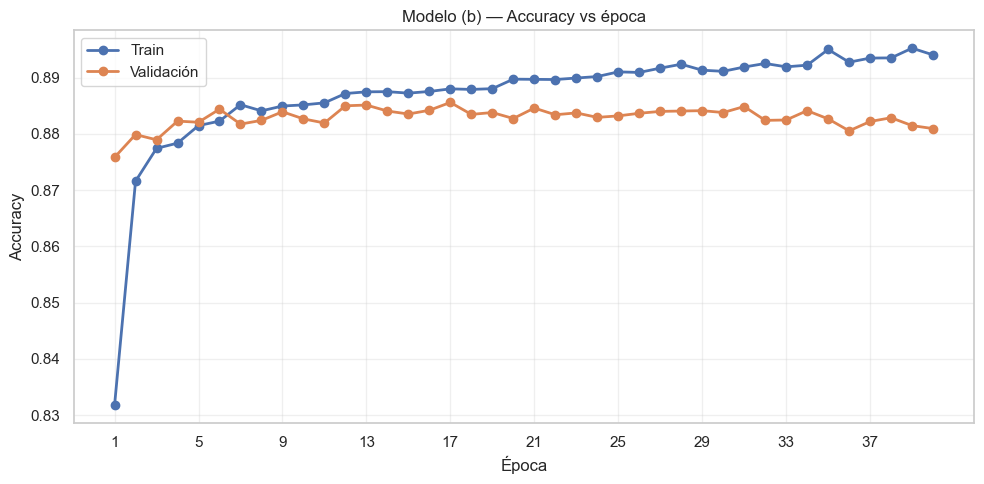

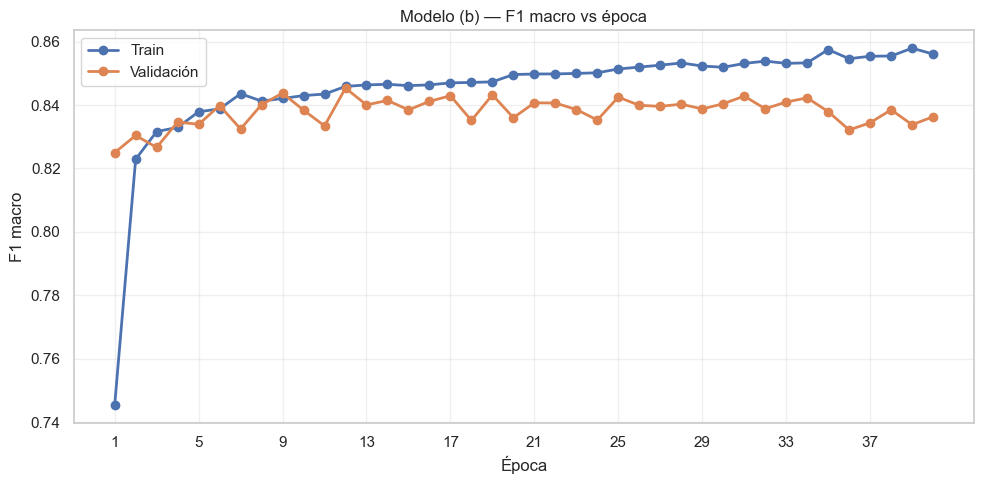

In [207]:
# b.2. Entrenamiento del modelo (b) y curvas de métricas
if "CONFIG_ENTRENAMIENTO" not in globals() or "entrenar_modelo" not in globals():
    raise NameError("Ejecutá utilidades compartidas (después de 8.15) antes de b.2.")

if "MODELO_B" not in globals():
    raise NameError("Ejecutá la celda b.1 antes de entrenar el modelo (b).")

modelo_b = MODELO_B["modelo"]
criterio_b = MODELO_B["criterio"]
optimizador_b = MODELO_B["optimizador"]
loader_train_b = MODELO_B["loaders"]["train"]
loader_val_b = MODELO_B["loaders"]["val"]
dispositivo = MODELO_B["dispositivo"]
config_b = MODELO_B["config"]

print(f"=== b.2 — Entrenamiento modelo (b) | {config_b['epocas']} épocas ===")
fijar_semilla(config_b["semilla"])

HISTORIAL_ENTRENAMIENTO_B = entrenar_modelo(
    modelo=modelo_b,
    criterio=criterio_b,
    optimizador=optimizador_b,
    loader_train=loader_train_b,
    loader_val=loader_val_b,
    dispositivo=dispositivo,
    config=config_b,
)

ultima = -1
RESULTADOS_ENTRENAMIENTO_B = {
    "accuracy_train_final": HISTORIAL_ENTRENAMIENTO_B["accuracy_train"][ultima],
    "accuracy_val_final": HISTORIAL_ENTRENAMIENTO_B["accuracy_val"][ultima],
    "f1_macro_train_final": HISTORIAL_ENTRENAMIENTO_B["f1_macro_train"][ultima],
    "f1_macro_val_final": HISTORIAL_ENTRENAMIENTO_B["f1_macro_val"][ultima],
    "loss_train_final": HISTORIAL_ENTRENAMIENTO_B["loss_train"][ultima],
    "loss_val_final": HISTORIAL_ENTRENAMIENTO_B["loss_val"][ultima],
}

MODELO_B["historial"] = HISTORIAL_ENTRENAMIENTO_B
MODELO_B["resultados_entrenamiento"] = RESULTADOS_ENTRENAMIENTO_B

print("\nMétricas finales (última época):")
print(
    f"  Accuracy — train: {RESULTADOS_ENTRENAMIENTO_B['accuracy_train_final']:.4f} | "
    f"val: {RESULTADOS_ENTRENAMIENTO_B['accuracy_val_final']:.4f}"
)
print(
    f"  F1 macro — train: {RESULTADOS_ENTRENAMIENTO_B['f1_macro_train_final']:.4f} | "
    f"val: {RESULTADOS_ENTRENAMIENTO_B['f1_macro_val_final']:.4f}"
)

gap_f1 = (
    RESULTADOS_ENTRENAMIENTO_B["f1_macro_train_final"]
    - RESULTADOS_ENTRENAMIENTO_B["f1_macro_val_final"]
)
print(f"\nBrecha F1 macro (train − val): {gap_f1:.4f}", end="")
if gap_f1 > 0.05:
    print(" → posible sobreajuste.")
else:
    print(" → brecha moderada.")

graficar_curva_entrenamiento(
    HISTORIAL_ENTRENAMIENTO_B,
    metrica="accuracy",
    titulo="Modelo (b) — Accuracy vs época",
    etiqueta_y="Accuracy",
)
graficar_curva_entrenamiento(
    HISTORIAL_ENTRENAMIENTO_B,
    metrica="f1_macro",
    titulo="Modelo (b) — F1 macro vs época",
    etiqueta_y="F1 macro",
)




#### b.3. *Classification report* en validación

Con el modelo **(b)** ya entrenado, obtenemos predicciones sobre el **set de validación** (modo `eval`, sin actualizar pesos) y generamos el **classification report** de sklearn.

El reporte muestra **precision**, **recall** y **F1** por clase (*<=50K*, *>50K*) y promedios (*macro*, *weighted*). Lo mostramos **junto a un heatmap** de las mismas métricas por clase: tabla textual a la izquierda y gráfico a la derecha, para leer números y ver patrones en un solo vistazo.

Guardamos el resultado en `REPORTE_CLASIFICACION_B` para la comparación final en **(d)**.


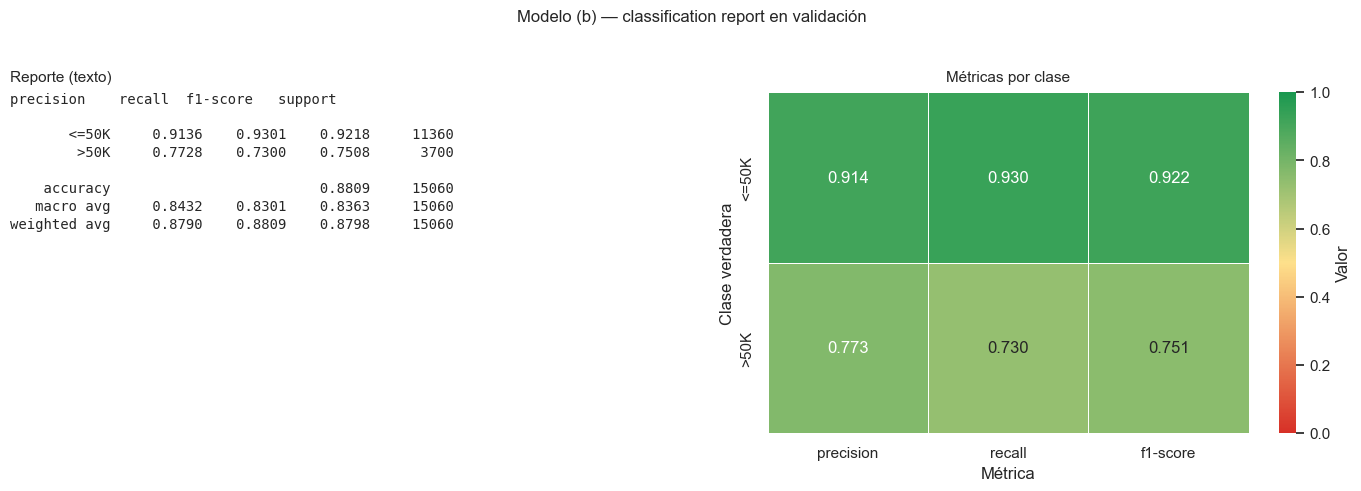

Accuracy en val: 0.8809 | F1 macro: 0.8363


In [208]:
# b.3. Classification report (sklearn) en validación — modelo (b)
if "CONFIG_ENTRENAMIENTO" not in globals() or "obtener_etiquetas_predichas" not in globals():
    raise NameError("Ejecutá utilidades compartidas antes de b.3.")

if "mostrar_reporte_con_heatmap" not in globals():
    raise NameError("Ejecutá utilidades compartidas (versión con reporte/heatmap) antes de b.3.")

if "MODELO_B" not in globals():
    raise NameError("Ejecutá la celda b.1 antes del classification report.")

if "historial" not in MODELO_B:
    raise NameError("El modelo (b) aún no fue entrenado. Ejecutá la celda b.2.")

modelo_b = MODELO_B["modelo"]
loader_val_b = MODELO_B["loaders"]["val"]
dispositivo = MODELO_B["dispositivo"]
formulacion_target = MODELO_B["config"]["formulacion_target"]

if "MAPEO_ENTERO_A_INCOME" not in globals():
    raise NameError("Ejecutá la celda 8.1 para cargar el mapeo del target.")

nombres_clases = [MAPEO_ENTERO_A_INCOME[entero] for entero in sorted(MAPEO_ENTERO_A_INCOME)]

y_val_verdadero, y_val_predicho = obtener_etiquetas_predichas(
    modelo=modelo_b,
    loader=loader_val_b,
    dispositivo=dispositivo,
    formulacion_target=formulacion_target,
)

reporte_texto_b = classification_report(
    y_val_verdadero,
    y_val_predicho,
    target_names=nombres_clases,
    digits=4,
    zero_division=0,
)

REPORTE_CLASIFICACION_B = classification_report(
    y_val_verdadero,
    y_val_predicho,
    target_names=nombres_clases,
    digits=4,
    zero_division=0,
    output_dict=True,
)

df_reporte_clasificacion_b = reporte_a_dataframe(REPORTE_CLASIFICACION_B, nombres_clases)

MODELO_B["y_val_verdadero"] = y_val_verdadero
MODELO_B["y_val_predicho"] = y_val_predicho
MODELO_B["reporte_clasificacion_val"] = REPORTE_CLASIFICACION_B
MODELO_B["df_reporte_clasificacion_val"] = df_reporte_clasificacion_b

mostrar_reporte_con_heatmap(
    reporte_texto_b,
    df_reporte_clasificacion_b,
    titulo="Modelo (b) — classification report en validación",
)

print(
    f"Accuracy en val: {REPORTE_CLASIFICACION_B['accuracy']:.4f} | "
    f"F1 macro: {REPORTE_CLASIFICACION_B['macro avg']['f1-score']:.4f}"
)



#### b.4. Matrices de confusión en validación

Usamos las predicciones de **b.3** sobre el set de **validación** para ver **dónde se equivoca** el modelo: filas = clase verdadera, columnas = clase predicha.

- **Matriz absoluta:** conteos de casos en cada celda (cuántos individuos hay en cada combinación verdadero/predicho).
- **Matriz normalizada por fila:** cada fila suma 1; lee la **proporción** dentro de cada clase real (p. ej. qué fracción de *>50K* fue bien clasificada).

Mostramos ambas **lado a lado**. La absoluta usa tonos azules (más intenso = más casos); la normalizada reutiliza el gradiente **rojo → amarillo → verde** (0 a 1), igual que el heatmap del reporte.


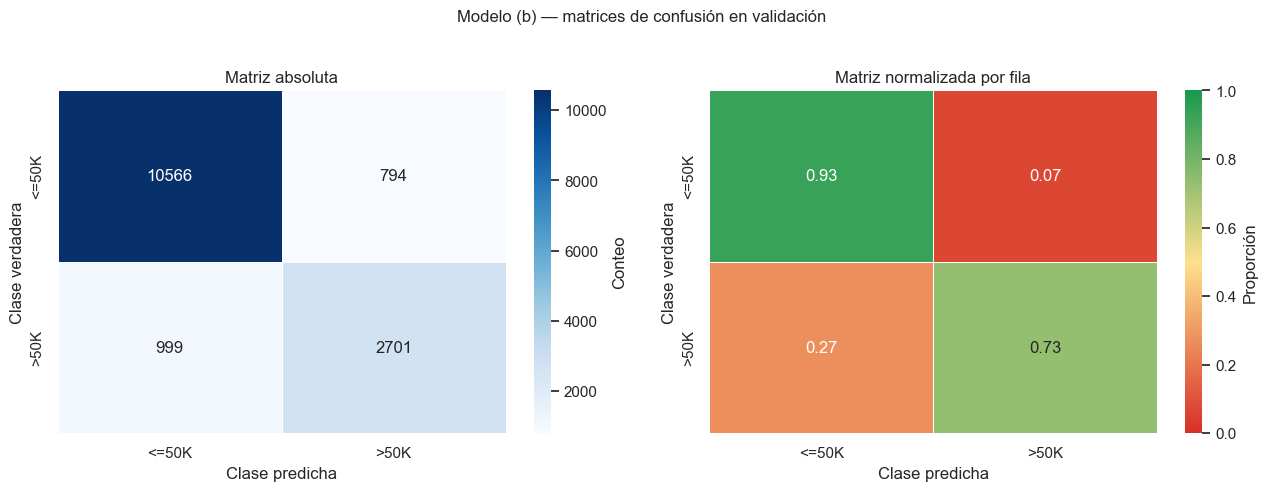

=== b.4 — Matriz de confusión absoluta ===
       <=50K  >50K
<=50K  10566   794
>50K     999  2701

=== b.4 — Matriz normalizada por fila ===
        <=50K    >50K
<=50K  0.9301  0.0699
>50K   0.2700  0.7300


In [209]:
# b.4. Matrices de confusión (validación) — modelo (b)
if "mostrar_matrices_confusion" not in globals():
    raise NameError("Ejecutá utilidades compartidas (versión con matrices de confusión) antes de b.4.")

if "MODELO_B" not in globals():
    raise NameError("Ejecutá las celdas b.1–b.3 antes de las matrices de confusión.")

if "y_val_verdadero" not in MODELO_B or "y_val_predicho" not in MODELO_B:
    raise NameError("Ejecutá la celda b.3 para obtener predicciones en validación.")

if "MAPEO_ENTERO_A_INCOME" not in globals():
    raise NameError("Ejecutá la celda 8.1 para cargar los nombres de clase.")

y_val_verdadero = MODELO_B["y_val_verdadero"]
y_val_predicho = MODELO_B["y_val_predicho"]
nombres_clases = [MAPEO_ENTERO_A_INCOME[entero] for entero in sorted(MAPEO_ENTERO_A_INCOME)]

MATRIZ_CONFUSION_B_ABS, MATRIZ_CONFUSION_B_NORM = mostrar_matrices_confusion(
    y_val_verdadero,
    y_val_predicho,
    nombres_clases=nombres_clases,
    titulo="Modelo (b) — matrices de confusión en validación",
)

MODELO_B["matriz_confusion_abs"] = MATRIZ_CONFUSION_B_ABS
MODELO_B["matriz_confusion_norm_fila"] = MATRIZ_CONFUSION_B_NORM

print("=== b.4 — Matriz de confusión absoluta ===")
print(pd.DataFrame(MATRIZ_CONFUSION_B_ABS, index=nombres_clases, columns=nombres_clases))
print("\n=== b.4 — Matriz normalizada por fila ===")
print(pd.DataFrame(MATRIZ_CONFUSION_B_NORM, index=nombres_clases, columns=nombres_clases).round(4))



## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


#### c.1. Configuración, arquitectura y modelo sin embeddings

El **modelo (c)** usa la matriz densa `DATOS_MODELO_C` (**8.15**): variables que en **(b)** tenían *Embedding* pasan a **one-hot**; el resto igual que **(b)**.

**Arquitectura (espejo de b, sin regularización interna):**

| Aspecto | Modelo (b) | Modelo (c) |
|---------|------------|------------|
| Entrada al MLP | 71 | **101** (todo one-hot / numérico) |
| Capas ocultas | 128 → 64 | **128 → 64** |
| Activación / optimizador / loss / batch | `CONFIG_ENTRENAMIENTO` | **igual** |
| Dropout | 0.3 | **ninguno** |
| Embeddings | sí | **no** |

No requiere ejecutar **b.1** ni **b.2**; solo **8.15**, **utilidades compartidas** y esta celda.


In [210]:
# c.1. Modelo (c): MLP denso sin embeddings ni dropout
COLUMNAS_EMBEDDING_EN_B = ["occupation", "native-country", "skill-profile"]

def construir_config_modelo_c(*, datos: dict) -> dict:
    if "CONFIG_ENTRENAMIENTO" not in globals():
        raise NameError("Ejecutá utilidades compartidas antes de c.1.")
    return {
        **CONFIG_ENTRENAMIENTO,
        "dropout": 0.0,
        "n_features": int(datos["n_features"]),
    }


class DatasetAdultDenso(Dataset):
    """Matriz densa completa (modelo c): una fila de features + etiqueta."""

    def __init__(
        self,
        datos: dict,
        *,
        entrenamiento: bool,
        formulacion_target: str,
    ) -> None:
        clave_x = "X_train" if entrenamiento else "X_val"
        clave_y = "y_train" if entrenamiento else "y_val"
        self.X = datos[clave_x]
        self.y = datos[clave_y]
        self.formulacion_target = formulacion_target

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, indice: int) -> dict:
        muestra = {"denso": torch.from_numpy(self.X[indice])}
        if self.formulacion_target == "binaria_logit":
            muestra["y"] = torch.tensor(float(self.y[indice]), dtype=torch.float32)
        else:
            muestra["y"] = torch.tensor(int(self.y[indice]), dtype=torch.long)
        return muestra


class ModeloSinEmbeddings(nn.Module):
    """MLP denso: misma profundidad y neuronas que (b), sin Embedding ni Dropout."""

    def __init__(
        self,
        *,
        n_features: int,
        capas_ocultas: list[int],
        activacion: str,
        formulacion_target: str,
    ) -> None:
        super().__init__()
        self.formulacion_target = formulacion_target
        self.dim_entrada_mlp = n_features

        capas: list[nn.Module] = []
        entrada = n_features
        for unidades in capas_ocultas:
            capas.extend(
                [
                    nn.Linear(entrada, unidades),
                    crear_funcion_activacion(activacion),
                ]
            )
            entrada = unidades
        self.mlp_oculto = nn.Sequential(*capas)

        n_salida = 1 if formulacion_target == "binaria_logit" else 2
        self.capa_salida = nn.Linear(entrada, n_salida)

    def forward(self, denso: torch.Tensor) -> torch.Tensor:
        logits = self.capa_salida(self.mlp_oculto(denso))
        if self.formulacion_target == "binaria_logit":
            return logits.squeeze(-1)
        return logits

    def forward_lote(self, lote: dict) -> torch.Tensor:
        return self.forward(lote["denso"])


def crear_dataloaders_modelo_c(*, datos: dict, config: dict) -> tuple[DataLoader, DataLoader]:
    dataset_train = DatasetAdultDenso(
        datos,
        entrenamiento=True,
        formulacion_target=config["formulacion_target"],
    )
    dataset_val = DatasetAdultDenso(
        datos,
        entrenamiento=False,
        formulacion_target=config["formulacion_target"],
    )
    loader_train = DataLoader(
        dataset_train,
        batch_size=config["batch_size"],
        shuffle=True,
    )
    loader_val = DataLoader(
        dataset_val,
        batch_size=config["batch_size"],
        shuffle=False,
    )
    return loader_train, loader_val


if "CONFIG_ENTRENAMIENTO" not in globals():
    raise NameError("Ejecutá utilidades compartidas antes de c.1.")

if "DATOS_MODELO_C" not in globals():
    raise NameError("Ejecutá la celda 8.15 antes de definir el modelo (c).")

CONFIG_MODELO_C = construir_config_modelo_c(datos=DATOS_MODELO_C)

fijar_semilla(CONFIG_MODELO_C["semilla"])

modelo_c = ModeloSinEmbeddings(
    n_features=CONFIG_MODELO_C["n_features"],
    capas_ocultas=CONFIG_MODELO_C["capas_ocultas"],
    activacion=CONFIG_MODELO_C["activacion"],
    formulacion_target=CONFIG_MODELO_C["formulacion_target"],
).to(dispositivo)

criterio_c = crear_criterio(CONFIG_MODELO_C["formulacion_target"])
optimizador_c = crear_optimizador(
    modelo_c,
    nombre=CONFIG_MODELO_C["optimizador"],
    lr=CONFIG_MODELO_C["lr"],
    weight_decay=CONFIG_MODELO_C["weight_decay"],
)

loader_train_c, loader_val_c = crear_dataloaders_modelo_c(
    datos=DATOS_MODELO_C,
    config=CONFIG_MODELO_C,
)

conteo_parametros_c = contar_parametros(modelo_c)

MODELO_C = {
    "config": CONFIG_MODELO_C,
    "modelo": modelo_c,
    "criterio": criterio_c,
    "optimizador": optimizador_c,
    "loaders": {"train": loader_train_c, "val": loader_val_c},
    "dispositivo": dispositivo,
    "conteo_parametros": conteo_parametros_c,
    "dim_entrada_mlp": modelo_c.dim_entrada_mlp,
    "variables_embedding_en_b": COLUMNAS_EMBEDDING_EN_B,
}

print("=== c.1 — Modelo (c) sin embeddings ===\\n")
print("Variables que eran embedding en (b) → one-hot en (c):")
for columna in COLUMNAS_EMBEDDING_EN_B:
    print(f"  - {columna}")
print(f"\\nConfiguración compartida con (b): capas={CONFIG_MODELO_C['capas_ocultas']} | "
      f"activación={CONFIG_MODELO_C['activacion']} | optimizador={CONFIG_MODELO_C['optimizador']} | "
      f"lr={CONFIG_MODELO_C['lr']} | batch={CONFIG_MODELO_C['batch_size']}")
print(f"Sin dropout ni capas Embedding | n_features={CONFIG_MODELO_C['n_features']}")
print(f"\\nDimensión de entrada al MLP: {modelo_c.dim_entrada_mlp}")
print(f"Parámetros entrenables: {conteo_parametros_c['total']:,}")
if "conteo_parametros_b" in globals():
    print(
        f"  Referencia modelo (b): {conteo_parametros_b['total']:,} "
        f"(Δ {conteo_parametros_c['total'] - conteo_parametros_b['total']:+,})"
    )
print(f"\\nDataLoaders: train {len(loader_train_c)} lotes | val {len(loader_val_c)} lotes")
print(f"Loss: {criterio_c.__class__.__name__}")




=== c.1 — Modelo (c) sin embeddings ===\n
Variables que eran embedding en (b) → one-hot en (c):
  - occupation
  - native-country
  - skill-profile
\nConfiguración compartida con (b): capas=[128, 64] | activación=relu | optimizador=adam | lr=0.001 | batch=256
Sin dropout ni capas Embedding | n_features=101
\nDimensión de entrada al MLP: 101
Parámetros entrenables: 21,377
  Referencia modelo (b): 18,029 (Δ +3,348)
\nDataLoaders: train 118 lotes | val 59 lotes
Loss: BCEWithLogitsLoss


#### c.2. Entrenamiento y curvas de *accuracy* / F1 macro

Entrenamos el modelo **(c)** con `entrenar_modelo` (utilidades compartidas): mismas épocas, optimizador, loss y métricas que **(b)**. **No requiere** haber ejecutado **b.2**.

**Criterio de parada:** número fijo de épocas, sin early stopping.


=== c.2 — Entrenamiento modelo (c) | 40 épocas ===
Época 01/40 | loss train=0.3789 val=0.2774 | acc train=0.8274 val=0.8819 | F1 train=0.7254 val=0.8350
Época 05/40 | loss train=0.2578 val=0.2652 | acc train=0.8887 val=0.8848 | F1 train=0.8485 val=0.8434
Época 10/40 | loss train=0.2465 val=0.2692 | acc train=0.8934 val=0.8791 | F1 train=0.8550 val=0.8314
Época 15/40 | loss train=0.2368 val=0.2737 | acc train=0.8971 val=0.8818 | F1 train=0.8602 val=0.8384
Época 20/40 | loss train=0.2290 val=0.2789 | acc train=0.9004 val=0.8788 | F1 train=0.8651 val=0.8370
Época 25/40 | loss train=0.2222 val=0.2841 | acc train=0.9023 val=0.8790 | F1 train=0.8679 val=0.8368
Época 30/40 | loss train=0.2158 val=0.2906 | acc train=0.9040 val=0.8785 | F1 train=0.8703 val=0.8319
Época 35/40 | loss train=0.2087 val=0.2996 | acc train=0.9081 val=0.8768 | F1 train=0.8760 val=0.8302
Época 40/40 | loss train=0.2008 val=0.3092 | acc train=0.9128 val=0.8756 | F1 train=0.8827 val=0.8279

Métricas finales (última época

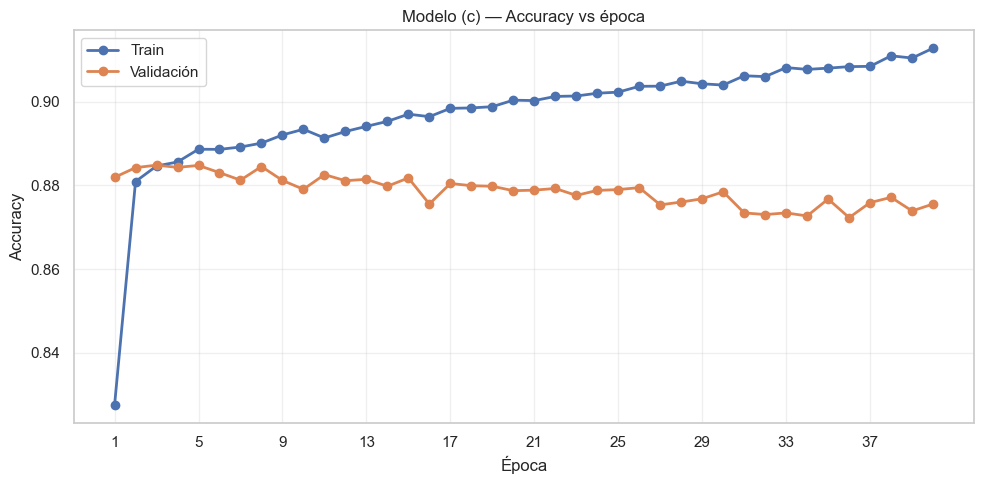

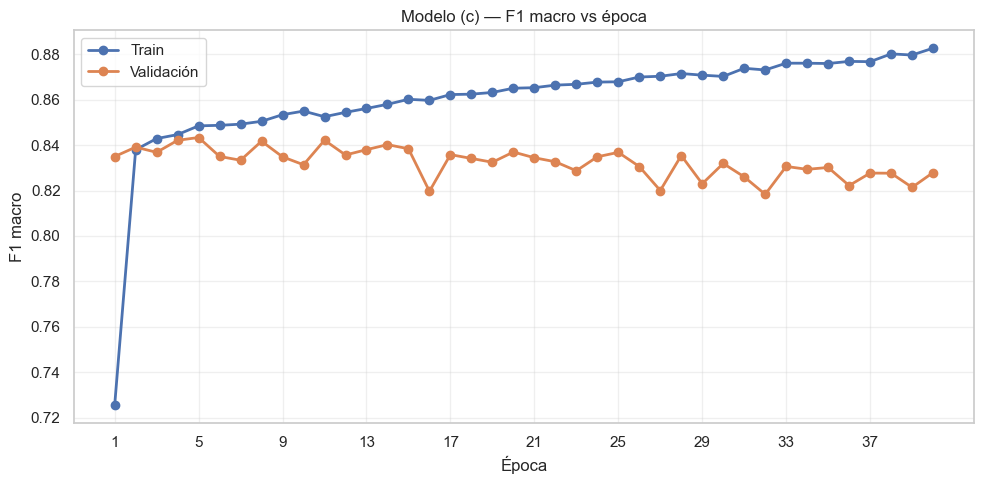

In [211]:
# c.2. Entrenamiento del modelo (c) y curvas de métricas
if "CONFIG_ENTRENAMIENTO" not in globals() or "entrenar_modelo" not in globals():
    raise NameError("Ejecutá utilidades compartidas (después de 8.15) antes de c.2.")

if "MODELO_C" not in globals():
    raise NameError("Ejecutá la celda c.1 antes de entrenar el modelo (c).")

modelo_c = MODELO_C["modelo"]
criterio_c = MODELO_C["criterio"]
optimizador_c = MODELO_C["optimizador"]
loader_train_c = MODELO_C["loaders"]["train"]
loader_val_c = MODELO_C["loaders"]["val"]
dispositivo = MODELO_C["dispositivo"]
config_c = MODELO_C["config"]

print(f"=== c.2 — Entrenamiento modelo (c) | {config_c['epocas']} épocas ===")
fijar_semilla(config_c["semilla"])

HISTORIAL_ENTRENAMIENTO_C = entrenar_modelo(
    modelo=modelo_c,
    criterio=criterio_c,
    optimizador=optimizador_c,
    loader_train=loader_train_c,
    loader_val=loader_val_c,
    dispositivo=dispositivo,
    config=config_c,
)

ultima = -1
RESULTADOS_ENTRENAMIENTO_C = {
    "accuracy_train_final": HISTORIAL_ENTRENAMIENTO_C["accuracy_train"][ultima],
    "accuracy_val_final": HISTORIAL_ENTRENAMIENTO_C["accuracy_val"][ultima],
    "f1_macro_train_final": HISTORIAL_ENTRENAMIENTO_C["f1_macro_train"][ultima],
    "f1_macro_val_final": HISTORIAL_ENTRENAMIENTO_C["f1_macro_val"][ultima],
    "loss_train_final": HISTORIAL_ENTRENAMIENTO_C["loss_train"][ultima],
    "loss_val_final": HISTORIAL_ENTRENAMIENTO_C["loss_val"][ultima],
}

MODELO_C["historial"] = HISTORIAL_ENTRENAMIENTO_C
MODELO_C["resultados_entrenamiento"] = RESULTADOS_ENTRENAMIENTO_C

print("\nMétricas finales (última época) — modelo (c):")
print(
    f"  Accuracy — train: {RESULTADOS_ENTRENAMIENTO_C['accuracy_train_final']:.4f} | "
    f"val: {RESULTADOS_ENTRENAMIENTO_C['accuracy_val_final']:.4f}"
)
print(
    f"  F1 macro — train: {RESULTADOS_ENTRENAMIENTO_C['f1_macro_train_final']:.4f} | "
    f"val: {RESULTADOS_ENTRENAMIENTO_C['f1_macro_val_final']:.4f}"
)

if "RESULTADOS_ENTRENAMIENTO_B" in globals():
    print("\nReferencia última época — modelo (b):")
    print(
        f"  F1 macro val: {RESULTADOS_ENTRENAMIENTO_B['f1_macro_val_final']:.4f} "
        f"(c: {RESULTADOS_ENTRENAMIENTO_C['f1_macro_val_final']:.4f})"
    )

gap_f1 = (
    RESULTADOS_ENTRENAMIENTO_C["f1_macro_train_final"]
    - RESULTADOS_ENTRENAMIENTO_C["f1_macro_val_final"]
)
print(f"\nBrecha F1 macro train − val (c): {gap_f1:.4f}", end="")
if gap_f1 > 0.05:
    print(" → posible sobreajuste.")
else:
    print(" → brecha moderada.")

graficar_curva_entrenamiento(
    HISTORIAL_ENTRENAMIENTO_C,
    metrica="accuracy",
    titulo="Modelo (c) — Accuracy vs época",
    etiqueta_y="Accuracy",
)
graficar_curva_entrenamiento(
    HISTORIAL_ENTRENAMIENTO_C,
    metrica="f1_macro",
    titulo="Modelo (c) — F1 macro vs época",
    etiqueta_y="F1 macro",
)




#### c.3. *Classification report* en validación

Igual que en **b.3**: predicciones en **validación** con el modelo **(c)** entrenado, **classification report** de sklearn y visualización **texto + heatmap** (gradiente rojo → amarillo → verde). No requiere haber corrido **b.3**.

Guardamos el resultado en `REPORTE_CLASIFICACION_C` para la comparación en **(d)**.


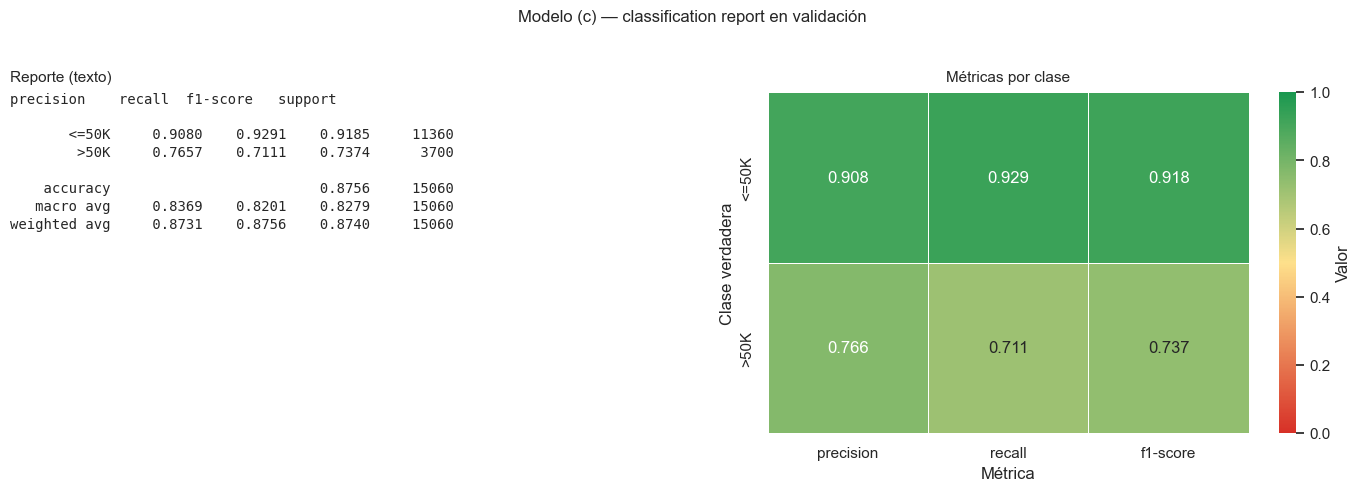

Accuracy en val: 0.8756 | F1 macro: 0.8279
Referencia modelo (b) — F1 macro val: 0.8363


In [212]:
# c.3. Classification report (sklearn) en validación — modelo (c)
if "CONFIG_ENTRENAMIENTO" not in globals() or "obtener_etiquetas_predichas" not in globals():
    raise NameError("Ejecutá utilidades compartidas antes de c.3.")

if "mostrar_reporte_con_heatmap" not in globals():
    raise NameError("Ejecutá utilidades compartidas (versión con reporte/heatmap) antes de c.3.")

if "MODELO_C" not in globals():
    raise NameError("Ejecutá la celda c.1 antes del classification report.")

if "historial" not in MODELO_C:
    raise NameError("El modelo (c) aún no fue entrenado. Ejecutá la celda c.2.")

modelo_c = MODELO_C["modelo"]
loader_val_c = MODELO_C["loaders"]["val"]
dispositivo = MODELO_C["dispositivo"]
formulacion_target = MODELO_C["config"]["formulacion_target"]

if "MAPEO_ENTERO_A_INCOME" not in globals():
    raise NameError("Ejecutá la celda 8.1 para cargar el mapeo del target.")

nombres_clases = [MAPEO_ENTERO_A_INCOME[entero] for entero in sorted(MAPEO_ENTERO_A_INCOME)]

y_val_verdadero_c, y_val_predicho_c = obtener_etiquetas_predichas(
    modelo=modelo_c,
    loader=loader_val_c,
    dispositivo=dispositivo,
    formulacion_target=formulacion_target,
)

reporte_texto_c = classification_report(
    y_val_verdadero_c,
    y_val_predicho_c,
    target_names=nombres_clases,
    digits=4,
    zero_division=0,
)

REPORTE_CLASIFICACION_C = classification_report(
    y_val_verdadero_c,
    y_val_predicho_c,
    target_names=nombres_clases,
    digits=4,
    zero_division=0,
    output_dict=True,
)

df_reporte_clasificacion_c = reporte_a_dataframe(REPORTE_CLASIFICACION_C, nombres_clases)

MODELO_C["y_val_verdadero"] = y_val_verdadero_c
MODELO_C["y_val_predicho"] = y_val_predicho_c
MODELO_C["reporte_clasificacion_val"] = REPORTE_CLASIFICACION_C
MODELO_C["df_reporte_clasificacion_val"] = df_reporte_clasificacion_c

mostrar_reporte_con_heatmap(
    reporte_texto_c,
    df_reporte_clasificacion_c,
    titulo="Modelo (c) — classification report en validación",
)

print(
    f"Accuracy en val: {REPORTE_CLASIFICACION_C['accuracy']:.4f} | "
    f"F1 macro: {REPORTE_CLASIFICACION_C['macro avg']['f1-score']:.4f}"
)

if "REPORTE_CLASIFICACION_B" in globals():
    print(
        f"Referencia modelo (b) — F1 macro val: "
        f"{REPORTE_CLASIFICACION_B['macro avg']['f1-score']:.4f}"
    )



#### c.4. Matrices de confusión en validación

Igual que en **b.4**: usamos las predicciones de **c.3** sobre **validación** (filas = clase verdadera, columnas = clase predicha).

- **Matriz absoluta:** conteos (tonos azules).
- **Matriz normalizada por fila:** proporciones que suman 1 por fila (gradiente rojo → amarillo → verde).

Ambas **lado a lado**. Guardamos las matrices en `MODELO_C` para la comparación en **(d)**.


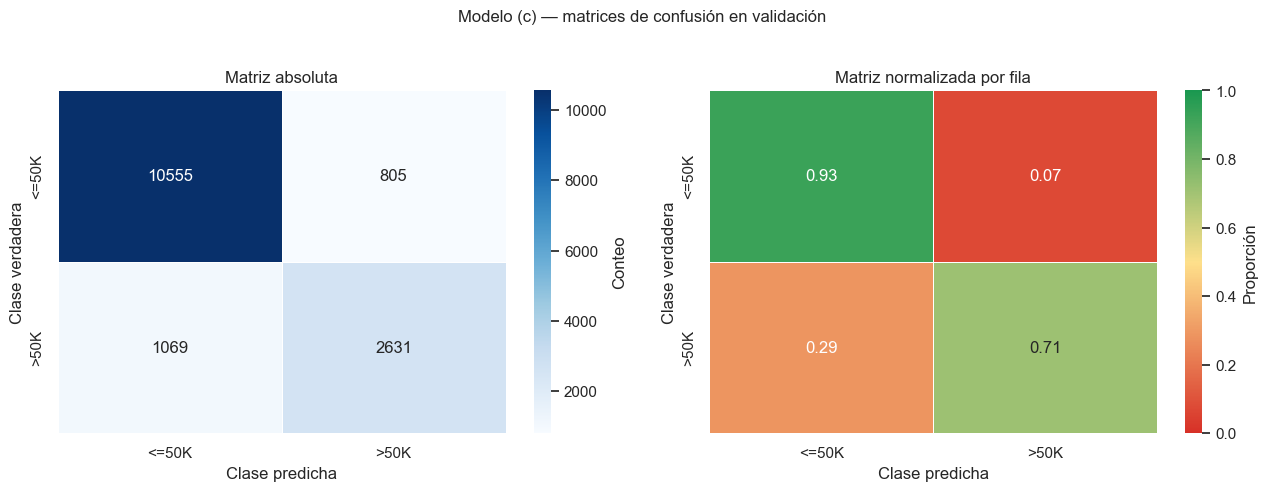

=== c.4 — Matriz de confusión absoluta ===
       <=50K  >50K
<=50K  10555   805
>50K    1069  2631

=== c.4 — Matriz normalizada por fila ===
        <=50K    >50K
<=50K  0.9291  0.0709
>50K   0.2889  0.7111


In [213]:
# c.4. Matrices de confusión (validación) — modelo (c)
if "mostrar_matrices_confusion" not in globals():
    raise NameError("Ejecutá utilidades compartidas (versión con matrices de confusión) antes de c.4.")

if "MODELO_C" not in globals():
    raise NameError("Ejecutá las celdas c.1–c.3 antes de las matrices de confusión.")

if "y_val_verdadero" not in MODELO_C or "y_val_predicho" not in MODELO_C:
    raise NameError("Ejecutá la celda c.3 para obtener predicciones en validación.")

if "MAPEO_ENTERO_A_INCOME" not in globals():
    raise NameError("Ejecutá la celda 8.1 para cargar los nombres de clase.")

y_val_verdadero_c = MODELO_C["y_val_verdadero"]
y_val_predicho_c = MODELO_C["y_val_predicho"]
nombres_clases = [MAPEO_ENTERO_A_INCOME[entero] for entero in sorted(MAPEO_ENTERO_A_INCOME)]

MATRIZ_CONFUSION_C_ABS, MATRIZ_CONFUSION_C_NORM = mostrar_matrices_confusion(
    y_val_verdadero_c,
    y_val_predicho_c,
    nombres_clases=nombres_clases,
    titulo="Modelo (c) — matrices de confusión en validación",
)

MODELO_C["matriz_confusion_abs"] = MATRIZ_CONFUSION_C_ABS
MODELO_C["matriz_confusion_norm_fila"] = MATRIZ_CONFUSION_C_NORM

print("=== c.4 — Matriz de confusión absoluta ===")
print(pd.DataFrame(MATRIZ_CONFUSION_C_ABS, index=nombres_clases, columns=nombres_clases))
print("\n=== c.4 — Matriz normalizada por fila ===")
print(pd.DataFrame(MATRIZ_CONFUSION_C_NORM, index=nombres_clases, columns=nombres_clases).round(4))




## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.
